# 🌟 COSMIC v0.0.1 - Compatibilidad Automática

**Este notebook ha sido actualizado para COSMIC v0.0.1**

## ✨ Mejoras Disponibles
- **Estructura modular**: `cosmic.core`, `cosmic.io`, `cosmic.preprocess`, `cosmic.analysis`
- **Imports modernos**: Específicos y organizados
- **API mejorada**: Mejor manejo de errores y configuración
- **Compatibilidad total**: El código existente sigue funcionando

## 🔄 Migración Opcional
Para usar las nuevas funcionalidades:
```python
# Nuevo (recomendado)
from cosmic.analysis.analyzer import ClusterAnalyzer
from cosmic.core.clustering import Clustering
from cosmic.io.loader import DataLoader

# Legacy (sigue funcionando)
from COSMIC import ClusterAnalyzer
from clustering import HDBSCANClustering
from data_loader import DataLoader
```

📚 **Documentación**: `/docs/reference/NOTEBOOK_MIGRATION_GUIDE.md`

# Figures of NGC 6383's paper by Pulgar-Escobar et al. 2024.

## Module import

In [191]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pymc as pm
import astropy.units as u
from astropy.constants import G
import arviz as az
import pymc.sampling_jax as pm_jax
import warnings
import seaborn as sns
from astropy.coordinates import SkyCoord,angular_separation,Galactic
from astropy.table import QTable, join
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import quantity_support
from astropy.visualization.wcsaxes import add_scalebar
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from scipy.stats import multivariate_normal, norm, ks_2samp
from astropy.stats import sigma_clip
from scipy.spatial import KDTree
from matplotlib.colors import ListedColormap, LogNorm
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
%config InlineBackend.figure_format ='retina'
quantity_support();

In [192]:
def ensure_units(value, default_unit):
    """Ensure the given value has specific units, or assign default units."""
    if not hasattr(value, 'unit'):
        return value * default_unit
    return value
def angular_size(linear_size,distance):
    distance = ensure_units(distance,u.kpc)
    angular = (linear_size / distance).to(u.deg, equivalencies=u.dimensionless_angles())
    return angular.to(u.arcmin)
def linear_size(angular_size,distance):
    distance = ensure_units(distance,u.kpc)
    linear = (angular_size * distance).to(u.pc, equivalencies=u.dimensionless_angles())
    return linear.to(u.pc)
def histogram_mode(data,axis=None):
    """
    Compute the mode of a dataset based on its histogram.

    Parameters:
    - data: array-like, the dataset from which to compute the mode.

    Returns:
    - mode_value: The value with the highest count in the dataset.
    """
    # Compute the histogram of the data
    hist, bin_edges = np.histogram(data, bins='auto')
    
    # Find the index of the maximum count in the histogram
    max_index = np.argmax(hist)
    
    # Compute the mode as the average of the bin edges corresponding to the maximum count
    mode_value = 0.5 * (bin_edges[max_index] + bin_edges[max_index + 1])
    
    return mode_value

In [193]:
## Read of the data and labelling

data_gaia = QTable.read('25_arcmin_clustered.ecsv', guess=False, format='ascii.ecsv')

In [194]:
# Read the FITS file
with fits.open('NGC6383.fits') as hdulist:
    # Extract the data and header information
    data = hdulist[0].data
    header = hdulist[0].header
wcs = WCS(header);

 [astropy.io.fits.verify]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
Changed DATE-OBS from '1991/04/12' to '1991-04-12''. [astropy.wcs.wcs]


In [195]:
cluster = (data_gaia['cluster'] == 0) & (data_gaia['probability'] >= 0.5)
noise = (data_gaia['cluster'] == -1) | ((data_gaia['cluster'] == 0) & (data_gaia['probability'] <= 0.5))

## Parallax clipping

In [196]:
print(rf'{len(data_gaia[cluster])} before $\sigma$ clipping')
parmax, min_plx, max_plx = sigma_clip(data_gaia['parallax'][cluster], sigma=2, cenfunc='median', stdfunc='std',return_bounds=True)
data_gaia['cluster'][(data_gaia['cluster'] == 0) & ((data_gaia['parallax'] < min_plx) | (data_gaia['parallax'] > max_plx))] = -1
cluster = (data_gaia['cluster'] == 0) & (data_gaia['probability'] >= 0.5)
noise = (data_gaia['cluster'] == -1) | ((data_gaia['cluster'] == 0) & (data_gaia['probability'] <= 0.5))
print(rf'{len(data_gaia[cluster])} after $\sigma$ clipping')

544 before $\sigma$ clipping
399 after $\sigma$ clipping


In [197]:
parmax, min_plx, max_plx = sigma_clip(data_gaia['parallax'][cluster], sigma=2, cenfunc=histogram_mode, stdfunc='std',return_bounds=True)
data_gaia['cluster'][(data_gaia['cluster'] == 0) & ((data_gaia['parallax'] < min_plx) | (data_gaia['parallax'] > max_plx))] = -1
cluster = (data_gaia['cluster'] == 0) & (data_gaia['probability'] >= 0.5)
noise = (data_gaia['cluster'] == -1) | ((data_gaia['cluster'] == 0) & (data_gaia['probability'] <= 0.5))

In [198]:
min_plx, max_plx

(<Quantity 0.72757001 mas>, <Quantity 1.0507439 mas>)

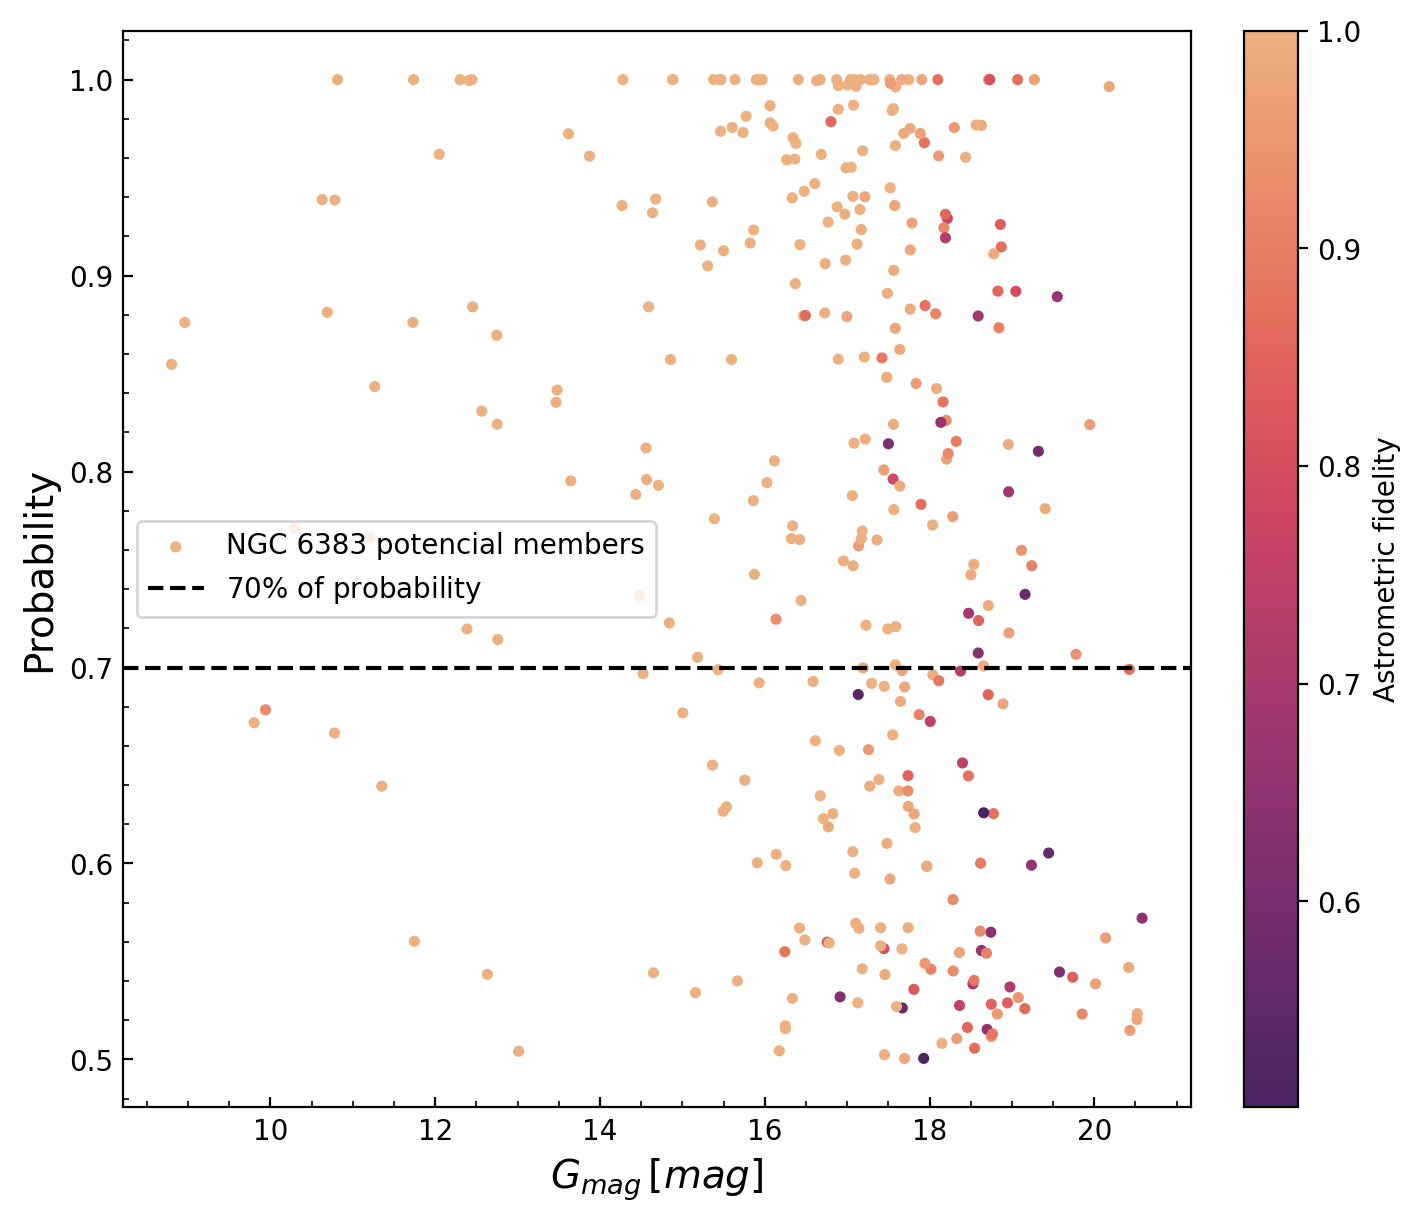

In [199]:
fig_prob, ax_prob = plt.subplots(1,1,figsize=(7,6),layout='constrained')
sc_cmap = ax_prob.scatter(data_gaia['Gmag'][cluster],data_gaia['probability'][cluster],s=9,label='NGC 6383 potencial members',c=data_gaia[cluster]['fidelity_v2'],cmap=sns.color_palette("flare_r", as_cmap=True))
fig_prob.colorbar(sc_cmap).set_label('Astrometric fidelity')
#ax_prob.scatter(data_gaia['Gmag'][noise],data_gaia['probability'][noise],s=4,label='Field stars',c='blue')
ax_prob.axhline(0.7,color='k',ls='--',label=r'$70\%$ of probability')
ax_prob.set_xlabel(r'$G_{{mag}}\,[{}]$'.format(data_gaia['Gmag'].unit),fontsize=14)
ax_prob.set_ylabel(r'Probability',fontsize=14)
ax_prob.legend(loc='center left')
ax_prob.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_prob.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_prob.tick_params(axis='both', which='both', direction='in')
fig_prob.savefig('Tex_File/Figures/probabilies_post_sigmaclip.pdf',dpi='figure',bbox_inches='tight');

In [265]:
len(data_gaia[cluster & (data_gaia['probability'] >= 0.6)])

266

## CMD

In [160]:
def read_isochrones_with_metadata(file_path,columns_type='DR3'):
    metadata = []
    isochrones = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
    data_start_index = next(i for i, line in enumerate(lines) if line.startswith("# Zini"))
    metadata = lines[:data_start_index]
    separator_indices = [index for index, line in enumerate(lines[data_start_index:]) if line.startswith("#")]
    separator_indices.append(len(lines))
    if columns_type == 'DR3':
        columns = ["Zini", "MH", "logAge", "Mini", "int_IMF", "Mass", "logL", "logTe",
    "logg", "label", "McoreTP", "C_O", "period0", "period1", "period2",
    "period3", "period4", "pmode", "Mloss", "tau1m", "X", "Y", "Xc", "Xn",
    "Xo", "Cexcess", "Z", "mbolmag", "Gmag", "G_BPmag", "G_RPmag"]
    if columns_type == '2MASS':
        columns = ["Zini", "MH", "logAge", "Mini", "int_IMF", "Mass", "logL", "logTe",
    "logg", "label", "McoreTP", "C_O", "period0", "period1", "period2",
    "period3", "period4", "pmode", "Mloss", "tau1m", "X", "Y", "Xc", "Xn",
    "Xo", "Cexcess", "Z", "mbolmag", "Jmag", "Hmag", "Ksmag"]
    for i in range(len(separator_indices) - 1):
        start_index = data_start_index + separator_indices[i] + 1
        end_index = data_start_index + separator_indices[i + 1]
        isochrone_data = lines[start_index:end_index]
        df = pd.DataFrame([x.strip().split() for x in isochrone_data if x.strip()], columns = columns)
        isochrones.append(df)
    return metadata, isochrones

def set_column_types(isochrones, columns):
    dtype_conversion = {column: float for column in columns}
    
    for df in isochrones:
        for column in dtype_conversion:
            if column in df.columns:
                df[column] = pd.to_numeric(df[column], errors='coerce')
    return isochrones

# Previous functions definitions (read_isochrones_with_metadata and set_column_types) are assumed to be defined here

# Stage labels mapping based on your provided categories
stage_labels = {
    0: 'PMS',
    1: 'MS',
    2: 'SGB',
    3: 'RGB',
    4: 'CHEB Stage 1',
    5: 'CHEB Stage 2',
    6: 'CHEB Stage 3',
    7: 'EAGB',
    8: 'TPAGB',
    9: 'post-AGB'
}
def plot_isochrone(isochrones, logAge, Zini, color_row, mag_row, ax, dm=0, A_V=0, R_V=3.1, color='blue', alpha=0.4, linestyle='--', label=True, type='plot', yl=None):
    filtered_isochrone = isochrones.query(f"logAge == {logAge} and Zini == {Zini}").copy()
    
    # Calculate E(B-V) from A_V using the provided R_V value
    ext = A_V / R_V
    
    mass_data = []
    
    if not filtered_isochrone.empty:
        # Apply extinction and distance modulus corrections
        filtered_isochrone['corrected_mag'] = filtered_isochrone[mag_row] + dm + A_V
        filtered_isochrone['corrected_color'] = filtered_isochrone[color_row] + ext

        # Filter by luminosity if yl is specified
        if yl:
            filtered_isochrone = filtered_isochrone[filtered_isochrone['corrected_mag'] >= 0.95*yl[0]]
        # Plotting
        if type == 'plot':
            ax.plot(filtered_isochrone['corrected_color'], filtered_isochrone['corrected_mag'], lw=3, color=color, alpha=alpha, linestyle=linestyle, label=rf'$\log(age/yr)={logAge}$' if label else None)
        elif type == 'scatter':
            ax.scatter(filtered_isochrone['corrected_color'], filtered_isochrone['corrected_mag'], color=color, alpha=alpha, marker=linestyle, label=rf'$\log(age/yr)={logAge}$' if label else None)
    else:
        print(f"No isochrone found for logAge={logAge} and Z={Zini}.")

def plot_color_color(isochrone_1,isochrone_2, logAge, Zini, color_1_row, color_2_row, ax, A_V=0, R_V=3.1, color='blue', alpha=0.4, linestyle='--'):
    filtered_isochrone_1 = isochrone_1.query(f"logAge == {logAge} and Zini == {Zini}").copy()
    filtered_isochrone_2 = isochrone_2.query(f"logAge == {logAge} and Zini == {Zini}").copy()
    # Calculate E(B-V) from A_V using the provided R_V value
    ext = A_V / R_V
    
    if not (filtered_isochrone_1.empty and filtered_isochrone_2.empty):
        # Plot the entire isochrone without grouping by 'label'
        ax.plot(filtered_isochrone_1[color_1_row] + ext, filtered_isochrone_2[color_2_row] + ext, lw=3, c=color, alpha=alpha, linestyle=linestyle,label=rf'logAge={logAge}')
    else:
        print(f"No isochrone found for logAge={logAge} and Z={Zini}.")

def plot_isochrone_label(isochrones, logAge, Zini,color_row,mag_row, ax, dm=0, A_V=0, R_V=3.1,color='blue',alpha=0.4,linestyle='--'):
    filtered_isochrone = isochrones.query(f"logAge == {logAge} and Zini == {Zini}").copy()
    
    # Calculate A_V from E(B-V) using the provided R_V value
    #A_V = R_V * ext  # A_V = R_V * E(B-V)
    ext = A_V/R_V
    # Map the 'label' to a string representation, if stage_labels is defined
    filtered_isochrone.loc[:, 'stage'] = filtered_isochrone['label'].map(stage_labels)
    
    if not filtered_isochrone.empty:
        # Create a scatter plot for each stage
        for label, group in filtered_isochrone.groupby('label'):
            stage = stage_labels.get(label, 'Unknown')  # Get the stage name; default to 'Unknown' if not found
            # Apply distance modulus (dm), total V-band absorption (A_V), and reddening (ext) to colors and magnitudes
            ax.plot(group[color_row] + ext, group[mag_row] + dm + A_V, lw=3,c=color,alpha=alpha,linestyle=linestyle)
    
    else:
        print(f"No isochrone found for logAge={logAge} and Z={Zini}.")

def plot_errors_bar(magnitudes,color,magnitude_errors, color_errors, ax,loc=None):
    """
    Plot the median magnitude error and mean color error within bins of 2 mag on a CMD.
    
    Parameters:
    - magnitudes: QTable column or Quantity array, magnitudes of the stars/objects with units
    - magnitude_errors: QTable column or Quantity array, corresponding errors of the magnitudes with units
    - color_errors: QTable column or Quantity array, corresponding color errors with units
    - ax: matplotlib.axes.Axes, the axes on which to plot the graph
    - fixed_color_value: Quantity, the fixed color value where to plot the error bars
    """
    magnitudes = magnitudes.value
    magnitude_errors = magnitude_errors.value
    color_errors = color_errors.value
    # Determine the range of magnitudes and create bins every 2 magnitudes
    min_mag = np.floor(np.nanmin(magnitudes))
    max_mag = np.ceil(np.nanmax(magnitudes))
    bins = np.arange(min_mag, max_mag + 2, 2)
    
    median_mag_errors = []
    mean_color_errors = []
    # Calculate the median magnitude error and mean color error for each bin
    for i in range(len(bins) - 1):
        in_bin = (magnitudes >= bins[i]) & (magnitudes < bins[i+1])
        median_result = np.nanmedian(magnitude_errors[in_bin])
        mean_result = np.nanmean(color_errors[in_bin])

        # Check if the result is a masked array and append appropriately
        if hasattr(median_result, 'mask'):
            # Append unmasked value if masked; handle differently if needed
            median_mag_errors.append(median_result.tolist())
        else:
            median_mag_errors.append(median_result)
        if hasattr(mean_result, 'mask'):
            mean_color_errors.append(mean_result.tolist())
        else:
            mean_color_errors.append(mean_result)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    if loc is None:
        loc = 0.5*np.min(colors)
    ax.errorbar([loc] * len(bin_centers), bin_centers,
                xerr=mean_color_errors, yerr=median_mag_errors, 
                fmt='none',color='k', ecolor='k')
def plot_iso_mass_curves_across_isochrones(isochrones, logAge_range, Zini, ax, dm=0, A_V=0, R_V=3.1, color='black', alpha=1, linestyle='-', mass_values=None, zorder=1):
    # Initialize a dictionary to store color and magnitude for each mass across isochrones
    iso_mass_data = {mass: {'colors': [], 'magnitudes': []} for mass in mass_values}
    
    ext = A_V / R_V  # Calculate E(B-V) from A_V using the provided R_V value
    
    # Get sorted unique logAge values within the specified range and for the given Zini
    unique_logAges = isochrones[(isochrones['Zini'] == Zini) & (isochrones['logAge'].between(*logAge_range))]['logAge'].unique()
    sorted_logAges = np.sort(unique_logAges)
    
    for logAge in sorted_logAges:
        specific_isochrone = isochrones[(isochrones['logAge'] == logAge) & (isochrones['Zini'] == Zini)]
        
        # For each mass, find the first appearance in this specific isochrone by rounding
        for mass in mass_values:
            # Round the 'Mass' column for comparison and find the first match
            rounded_masses = specific_isochrone['Mass'].round(1)
            mass_points = specific_isochrone[(rounded_masses == mass)]
            
            if not mass_points.empty:
                first_point = mass_points.head(1)  # Taking the first appearance if multiple
                corrected_color = first_point['BP_RP'].iloc[0] + ext
                corrected_magnitude = first_point['Gmag'].iloc[0] + dm + A_V
                
                iso_mass_data[mass]['colors'].append(corrected_color)
                iso_mass_data[mass]['magnitudes'].append(corrected_magnitude)
    
    # Plotting lines connecting the first appearances of each mass across isochrones
    for mass, data in iso_mass_data.items():
        if data['colors'] and data['magnitudes']:
            # Plot without sorting as we're assuming chronological order by logAge
            ax.plot(data['colors'], data['magnitudes'], label=f'Mass = {mass} $M_\\odot$', color=color, alpha=alpha, linestyle=linestyle, zorder=zorder)

def assign_mass_nearest_isochrone_point_kdtree(isochrones, stars, logAge_range, Zini, color_column, magnitude_column, dm, A_V):
    """
    Modifies the function to return an Astropy Table that can be joined with the original stars table.
    The returned table includes `source_id` and the assigned masses, enabling a direct join.
    """
    # Ensure isochrones is a compatible format (e.g., pandas DataFrame)
    # Filter isochrones by metallicity and age range
    filtered_isochrones = isochrones[(isochrones['Zini'] == Zini) &
                                     (isochrones['logAge'].between(*logAge_range))]
    corrected_magnitude_isochrones = filtered_isochrones[magnitude_column] + dm + A_V

    # Prepare the data for KDTree: isochrone points (color, corrected magnitude)
    isochrone_points = np.vstack([filtered_isochrones[color_column], corrected_magnitude_isochrones]).T
    isochrone_masses = filtered_isochrones['Mass'].values
    
    # Build a KDTree for efficient nearest neighbor search
    tree = KDTree(isochrone_points)
    # Prepare stars data for KDTree query
    stars_features = np.vstack([stars[color_column], stars[magnitude_column]]).T
    
    # Query the KDTree for the nearest isochrone point for each star
    _, indices = tree.query(stars_features)
    
    # Assign the mass of the nearest isochrone point to each star
    assigned_masses = isochrone_masses[indices]*u.Msun
    
    # Create an Astropy Table to return, including source_id and assigned masses
    result_table = QTable([stars['designation'], assigned_masses], names=('designation', 'mass'))
    
    return result_table

In [161]:
#!sagitta Sagitta/NGC_6383_sagitta.fits --av_out av_sagitta --pms_out pms_sagitta
pms = QTable.read('Sagitta/NGC_6383_sagitta-sagitta.fits')
for i in ['av_sagitta','pms_sagitta','age']:
    pms[i] = np.squeeze(pms[i])
if not any(column in data_gaia.colnames for column in ['av_sagitta', 'pms_sagitta', 'age']):
    # If none of the columns exist in data_gaia, perform the join operation
    data_gaia = join(data_gaia, pms['source_id', 'av_sagitta', 'pms_sagitta', 'age'], keys='source_id', join_type='left')
    data_gaia['pms_sagitta'] = data_gaia['pms_sagitta'].filled(0)

In [18]:
low = cluster & (data_gaia['probability'] < 0.7)
high = cluster & (data_gaia['probability'] >= 0.7)
pms_high = high & (data_gaia['pms_sagitta'] >= 0.6)
pms_low = low & (data_gaia['pms_sagitta'] >= 0.6)
nopms_high = high & (data_gaia['pms_sagitta'] < 0.6)
nopms_low = low & (data_gaia['pms_sagitta'] < 0.6)
HD159176 = data_gaia[data_gaia['Gmag']<6*u.mag]
# Example usage
file_path_DR3 = 'isochrones_DR3.dat'
metadata_DR3, isochrones_DR3 = read_isochrones_with_metadata(file_path_DR3)
isochrones_DR3 = set_column_types(isochrones_DR3,["Zini", "MH", "logAge", "Mini", "int_IMF", "Mass", "logL", "logTe",
    "logg", "label", "McoreTP", "C_O", "period0", "period1", "period2",
    "period3", "period4", "pmode", "Mloss", "tau1m", "X", "Y", "Xc", "Xn",
    "Xo", "Cexcess", "Z", "mbolmag", "Gmag", "G_BPmag", "G_RPmag"])

# Concatenate isochrones into a single DataFrame
for i, df in enumerate(isochrones_DR3):
    df['isochrone_id'] = i
all_isochrones_DR3 = pd.concat(isochrones_DR3, ignore_index=True)

# Define a column for BP_RP color
all_isochrones_DR3['logAge'] = round(all_isochrones_DR3['logAge'],2)
all_isochrones_DR3['BP_RP'] = all_isochrones_DR3['G_BPmag'] - all_isochrones_DR3['G_RPmag']
# Example usage
file_path_2MASS = 'isochrones_2MASS.dat'
metadata_2MASS, isochrones_2MASS = read_isochrones_with_metadata(file_path_2MASS,columns_type='2MASS')
isochrones_2MASS = set_column_types(isochrones_2MASS,["Zini", "MH", "logAge", "Mini", "int_IMF", "Mass", "logL", "logTe",
    "logg", "label", "McoreTP", "C_O", "period0", "period1", "period2",
    "period3", "period4", "pmode", "Mloss", "tau1m", "X", "Y", "Xc", "Xn",
    "Xo", "Cexcess", "Z", "mbolmag", "Jmag", "Hmag", "Ksmag"])

# Concatenate isochrones into a single DataFrame
for i, df in enumerate(isochrones_2MASS):
    df['isochrone_id'] = i
all_isochrones_2MASS = pd.concat(isochrones_2MASS, ignore_index=True)

# Define a column for BP_RP color

all_isochrones_2MASS['logAge'] = round(all_isochrones_2MASS['logAge'],2)
all_isochrones_2MASS['RP_J'] = all_isochrones_DR3['G_RPmag'] - all_isochrones_2MASS['Jmag']
all_isochrones_2MASS['J_H'] = all_isochrones_2MASS['Jmag'] - all_isochrones_2MASS['Hmag']
all_isochrones_2MASS['J_K'] = all_isochrones_2MASS['Jmag'] - all_isochrones_2MASS['Ksmag']
all_isochrones_2MASS['H_K'] = all_isochrones_2MASS['Hmag'] - all_isochrones_2MASS['Ksmag']
all_isochrones_2MASS['Gmag'] = all_isochrones_DR3['Gmag']
np.unique(all_isochrones_2MASS['logAge']),np.unique(all_isochrones_2MASS['Zini']),np.unique(all_isochrones_DR3['logAge']),np.unique(all_isochrones_DR3['Zini'])

(array([4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 , 4.95, 5.  ,
        5.05, 5.1 , 5.15, 5.2 , 5.25, 5.3 , 5.35, 5.4 , 5.45, 5.5 , 5.55,
        5.6 , 5.65, 5.7 , 5.75, 5.8 , 5.85, 5.9 , 5.95, 6.  , 6.05, 6.1 ,
        6.15, 6.2 , 6.25, 6.3 , 6.35, 6.4 , 6.45, 6.5 , 6.55, 6.6 , 6.65,
        6.7 , 6.75, 6.8 , 6.85, 6.9 , 6.95, 7.  , 7.05, 7.1 , 7.15, 7.2 ,
        7.25, 7.3 , 7.35, 7.4 , 7.45, 7.5 , 7.55, 7.6 , 7.65, 7.7 , 7.75,
        7.8 , 7.85, 7.9 , 7.95]),
 array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06]),
 array([4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 , 4.95, 5.  ,
        5.05, 5.1 , 5.15, 5.2 , 5.25, 5.3 , 5.35, 5.4 , 5.45, 5.5 , 5.55,
        5.6 , 5.65, 5.7 , 5.75, 5.8 , 5.85, 5.9 , 5.95, 6.  , 6.05, 6.1 ,
        6.15, 6.2 , 6.25, 6.3 , 6.35, 6.4 , 6.45, 6.5 , 6.55, 6.6 , 6.65,
        6.7 , 6.75, 6.8 , 6.85, 6.9 , 6.95, 7.  , 7.05, 7.1 , 7.15, 7.2 ,
        7.25, 7.3 , 7.35, 7.4 , 7.45, 7.5 , 7.55, 7.6 , 7.65, 7.7 , 7.75,
        7.8 , 7.85, 7.9 , 7.95])

KeyError: 'BP_RP'

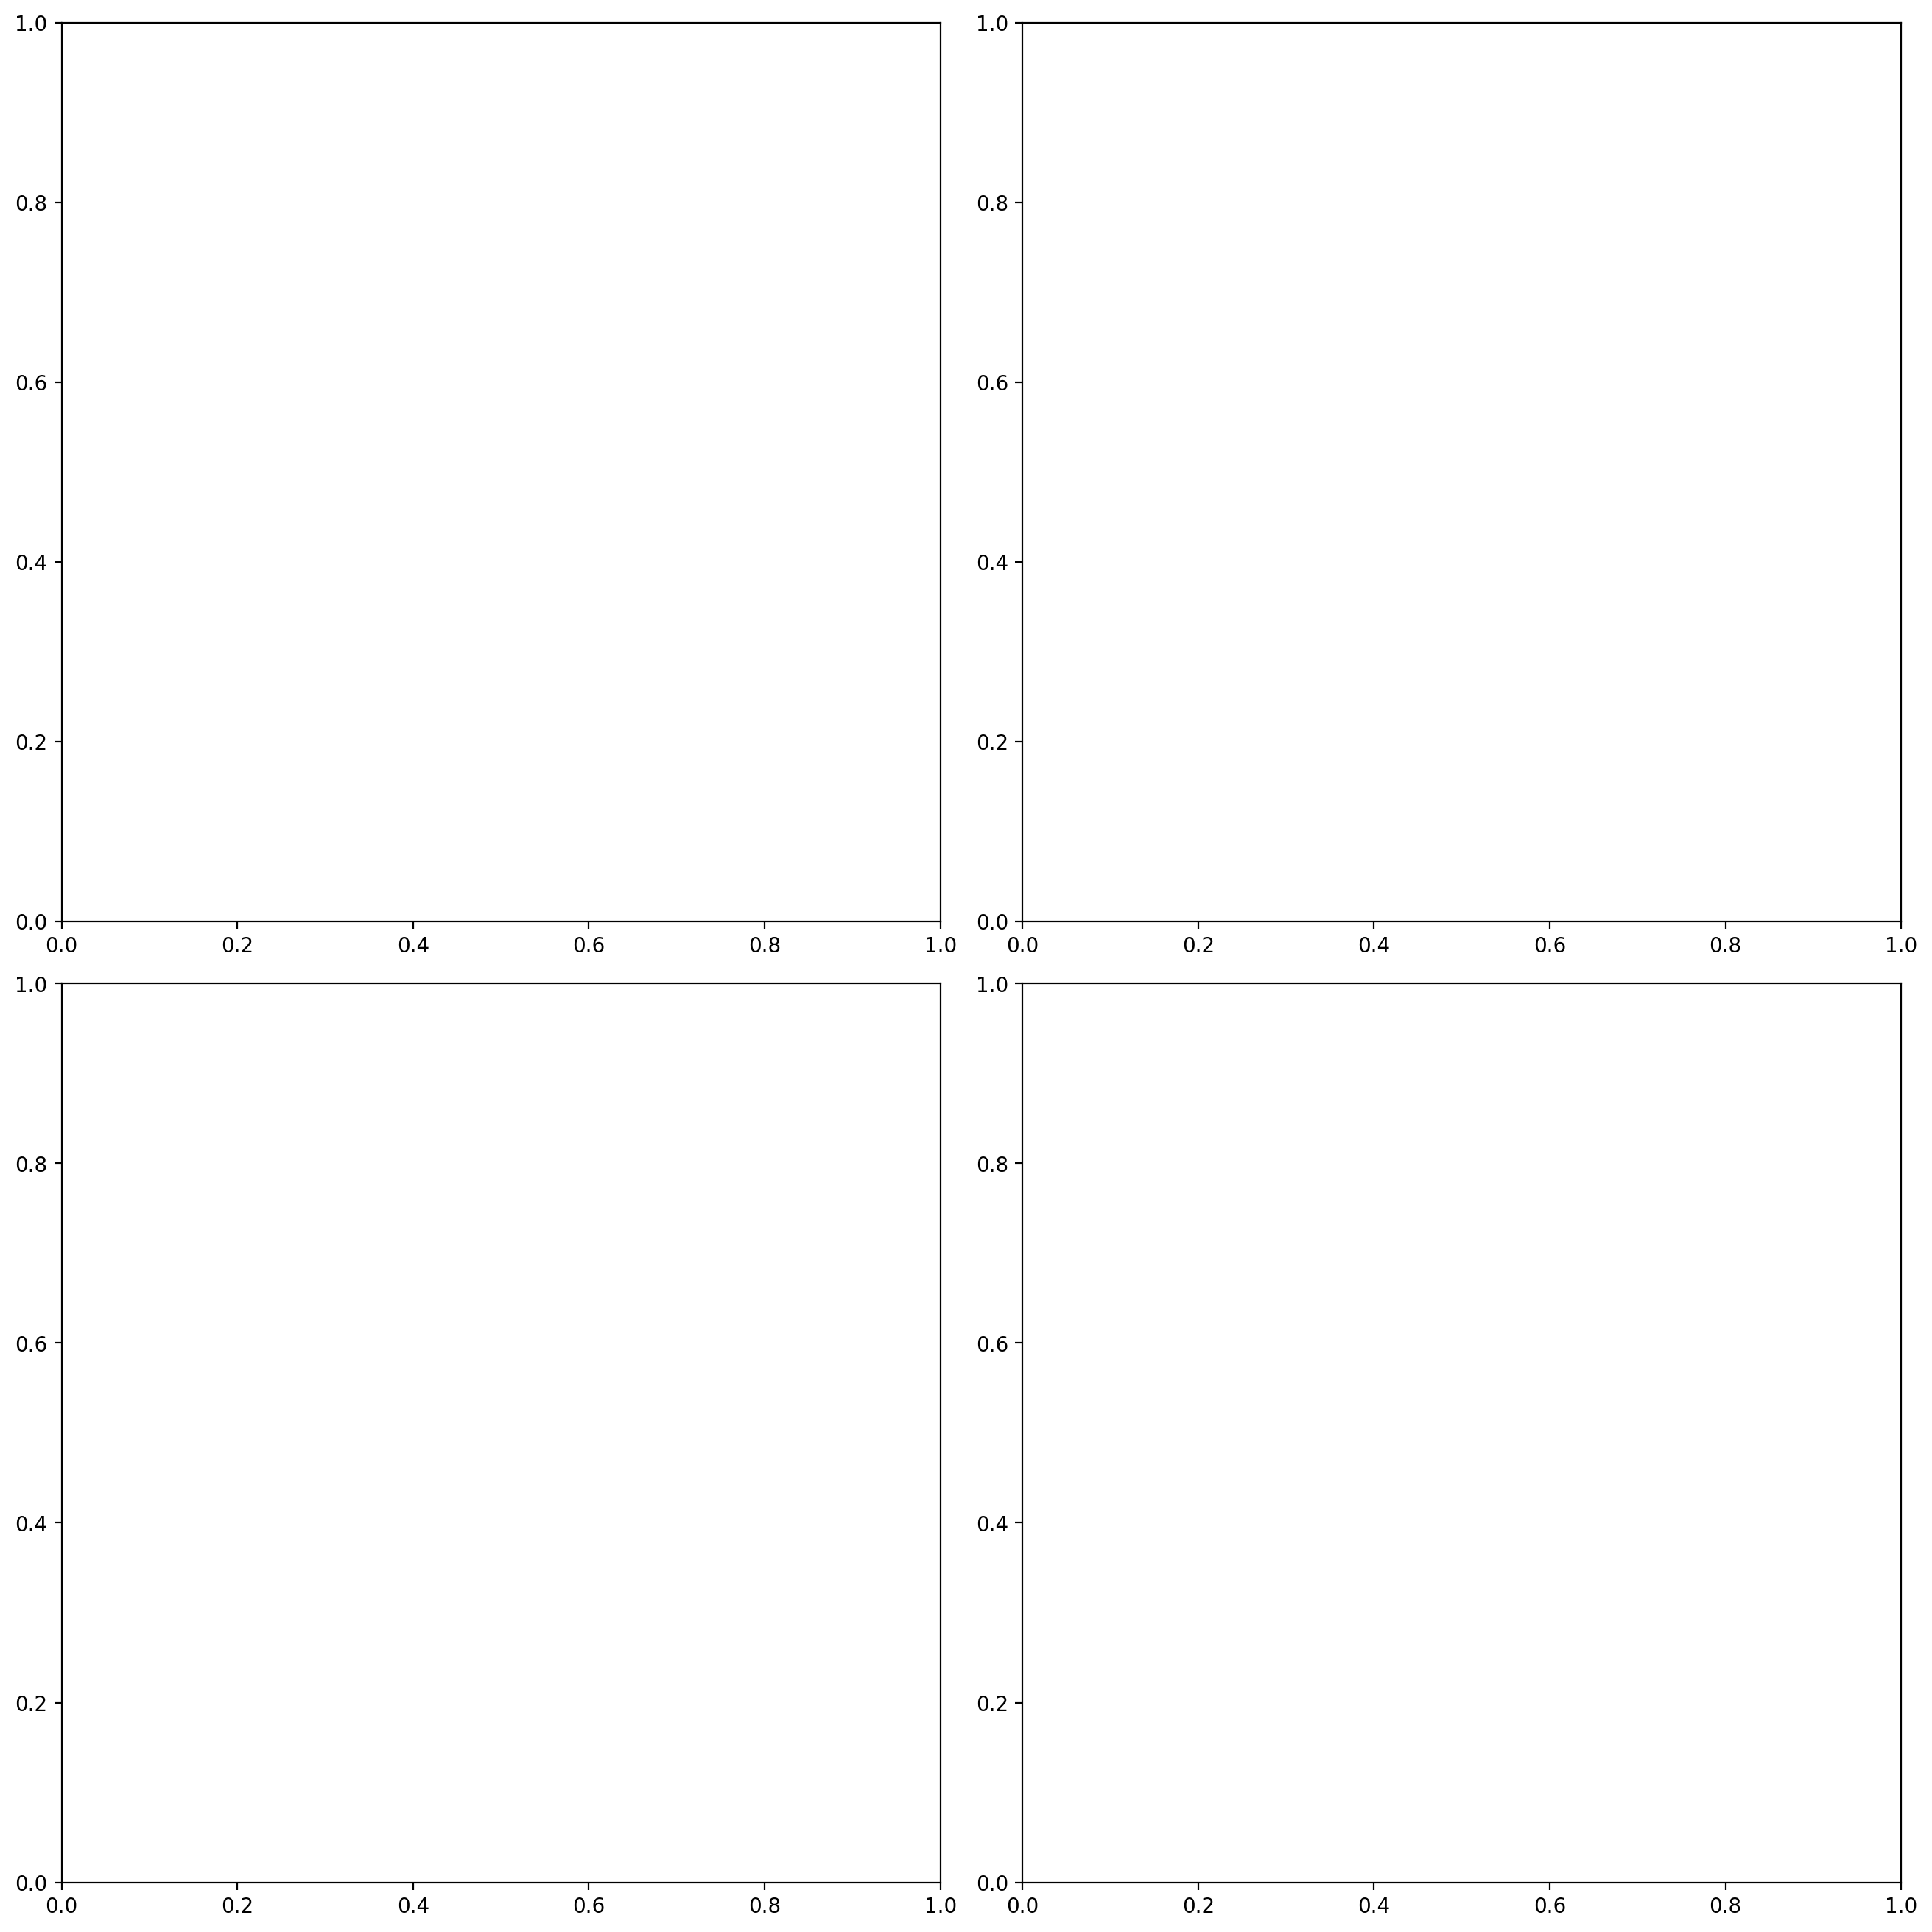

In [19]:
fig_cmd, ax_cmd = plt.subplots(2,2, layout='constrained', figsize=(13,13))
logAges = np.arange(6, 7.1, 0.2)  # From 6.1 to 7.0, inclusive
num_colors = len(logAges)
unique_color_indices = np.linspace(0, 1, num_colors, endpoint=False)
colors = [plt.cm.hsv(x) for x in unique_color_indices[::-1]]
Zini = 0.050  # Assuming Zini is constant

#ax_cmd[0,0].hist2d(*phot_Nsigma, bins=(hess_xedges, hess_yedges), cmap=cmap, norm=LogNorm(), zorder=-1,alpha=0)

for i in [0,1]:
    ax_cmd[i,0].scatter(data_gaia['BP_RP'][pms_high],data_gaia['Gmag'][pms_high],s=80,alpha=0.95,lw=0,marker='*',c='red',label='PMS Members',zorder=5)
    ax_cmd[i,0].scatter(data_gaia['BP_RP'][pms_low],data_gaia['Gmag'][pms_low],s=35,alpha=0.85,lw=0,marker='d',c='orangered',label='PMS Probable Members',zorder=4)
    ax_cmd[i,0].scatter(data_gaia['BP_RP'][nopms_high],data_gaia['Gmag'][nopms_high],s=80,alpha=0.95,lw=0,marker='*',c='blue',label='MS Members',zorder=5)
    ax_cmd[i,0].scatter(data_gaia['BP_RP'][nopms_low],data_gaia['Gmag'][nopms_low],s=35,alpha=0.85,lw=0,marker='d',c='blueviolet',label='MS Probable Members',zorder=4)
    ax_cmd[i,0].set_xlabel(r'Color $(BP - RP)$ [{}]'.format(data_gaia['BP_RP'].unit),fontsize=14)
    ax_cmd[i,0].set_ylabel(r'$G_{{mag}}\,[{}]$'.format(data_gaia['Gmag'].unit),fontsize=14)
    ax_cmd[i,1].scatter(data_gaia['RP_J'][pms_high],data_gaia['Gmag'][pms_high],s=80,alpha=0.95,lw=0,marker='*',c='red',label='PMS Members',zorder=5)
    ax_cmd[i,1].scatter(data_gaia['RP_J'][pms_low],data_gaia['Gmag'][pms_low],s=35,alpha=0.85,lw=0,marker='d',c='orangered',label='PMS Probable Members',zorder=4)
    ax_cmd[i,1].scatter(data_gaia['RP_J'][nopms_high],data_gaia['Gmag'][nopms_high],s=80,alpha=0.95,lw=0,marker='*',c='blue',label='MS Members',zorder=5)
    ax_cmd[i,1].scatter(data_gaia['RP_J'][nopms_low],data_gaia['Gmag'][nopms_low],s=35,alpha=0.85,lw=0,marker='d',c='blueviolet',label='MS Probable Members',zorder=4)
    ax_cmd[i,1].set_xlabel(r'Color $(RP - J)$ [{}]'.format(data_gaia['BP_RP'].unit),fontsize=14)
    ax_cmd[i,1].set_ylabel(r'$G_{{mag}}\,[{}]$'.format(data_gaia['Gmag'].unit),fontsize=14)
#ax_cmd[0,0].scatter(x_isoch, y_isoch, c='k',s=6,marker='.',label=r'Best fit + $\mathcal{N}(\mu,\sigma)$')
#ax_cmd[0,0].annotate("", xy=(x0 + dx, y0 + dy), xytext=(x0, y0), arrowprops=prop)

yl_gaia = ax_cmd[0,0].get_ylim()
for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_isochrone(all_isochrones_DR3,round(logAge,5), Zini,color_row='BP_RP',mag_row='Gmag', ax=ax_cmd[0,0], dm=10.3, A_V=1.8, color=color,linestyle='--',yl=yl_gaia)
yl_2mass = ax_cmd[0,1].get_ylim()
for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_isochrone(all_isochrones_2MASS,round(logAge,5), Zini,color_row='RP_J',mag_row='Gmag', ax=ax_cmd[0,1], dm=10.3, A_V=1.4, color=color,linestyle='--',yl=yl_2mass)

ax_cmd[0,0].scatter([],[],label=rf'$Z_{{ini}}={Zini}$',s=0)
ax_cmd[0,1].scatter([],[],label=rf'$Z_{{ini}}={Zini}$',s=0)

Zini = 0.06

#ax_cmd[1,0].hist2d(*phot_Nsigma, bins=(hess_xedges, hess_yedges), cmap=cmap, norm=LogNorm(), zorder=-1,alpha=0)
#ax_cmd[1,0].scatter(x_isoch, y_isoch, c='k',s=6,marker='.',label=r'Best fit + $\mathcal{N}(\mu,\sigma)$')
#ax_cmd[1,0].annotate("", xy=(x0 + dx, y0 + dy), xytext=(x0, y0), arrowprops=prop)

for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_isochrone(all_isochrones_DR3,round(logAge,5), Zini,color_row='BP_RP',mag_row='Gmag', ax=ax_cmd[1,0], dm=10.3, A_V=1.8, color=color,linestyle='--',yl=yl_gaia)

for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_isochrone(all_isochrones_2MASS,round(logAge,5), Zini,color_row='RP_J',mag_row='Gmag', ax=ax_cmd[1,1], dm=10.3, A_V=1.4, color=color,linestyle='--',yl=yl_2mass)
ax_cmd[1,0].scatter([],[],label=rf'$Z_{{ini}}={Zini}$',s=0)
ax_cmd[1,1].scatter([],[],label=rf'$Z_{{ini}}={Zini}$',s=0)
for ax in ax_cmd.flatten():
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set(adjustable='datalim',xlim=[-0.3,4.2],ylim=[0.9*np.min(data_gaia['Gmag'][cluster]),1.03*np.max(data_gaia['Gmag'][cluster])])
    ax.legend()
    ax.invert_yaxis()
fig_cmd.savefig('Tex_File/Figures/ngc6383_cmd_various.pdf',dpi=1500);

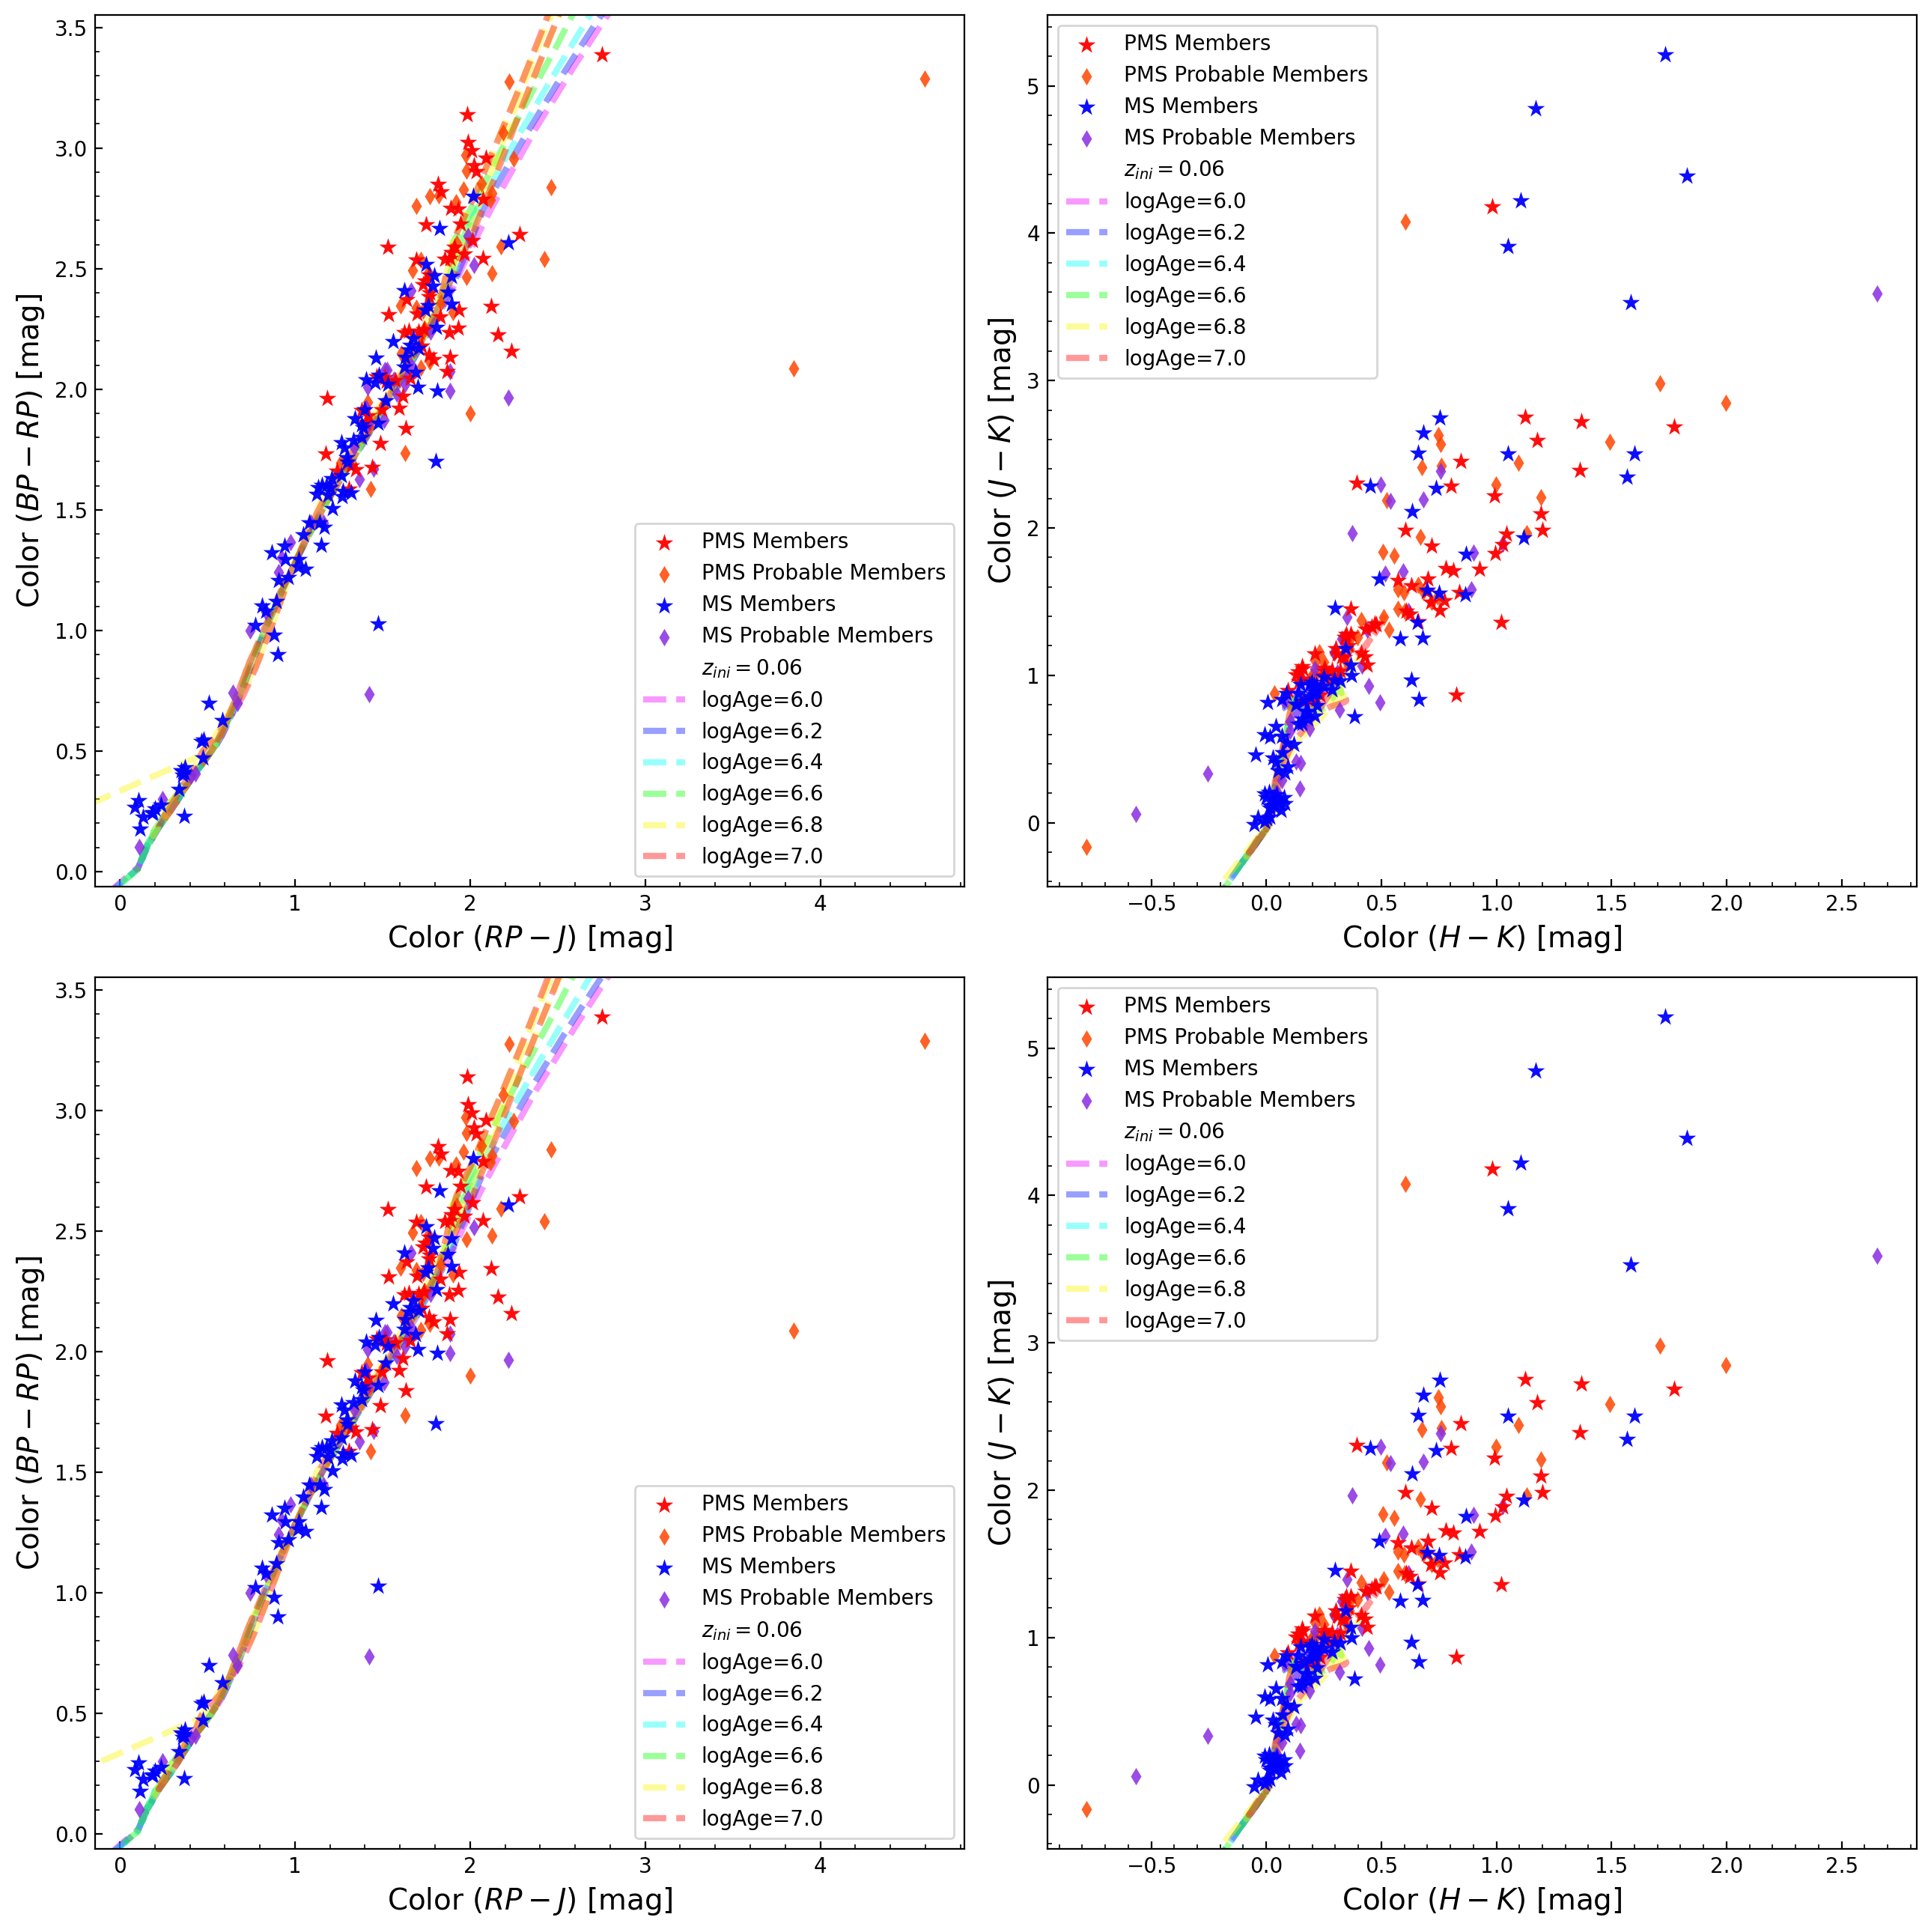

In [81]:
fig_cc, ax_cc = plt.subplots(2,2, layout='tight', figsize=(13,13))
Zini = 0.050  # Assuming Zini is constant

for i in [0,1]:
    Zini = 0.06
    ax_cc[i,0].scatter(data_gaia['RP_J'][pms_high],data_gaia['BP_RP'][pms_high],s=80,alpha=0.95,lw=0,marker='*',c='red',label='PMS Members',zorder=5)
    ax_cc[i,0].scatter(data_gaia['RP_J'][pms_low],data_gaia['BP_RP'][pms_low],s=35,alpha=0.85,lw=0,marker='d',c='orangered',label='PMS Probable Members',zorder=4)
    ax_cc[i,0].scatter(data_gaia['RP_J'][nopms_high],data_gaia['BP_RP'][nopms_high],s=80,alpha=0.95,lw=0,marker='*',c='blue',label='MS Members',zorder=5)
    ax_cc[i,0].scatter(data_gaia['RP_J'][nopms_low],data_gaia['BP_RP'][nopms_low],s=35,alpha=0.85,lw=0,marker='d',c='blueviolet',label='MS Probable Members',zorder=4)
    ax_cc[i,0].set_xlabel(r'Color $(RP - J)$ [{}]'.format(data_gaia['RP_J'].unit),fontsize=14)
    ax_cc[i,0].set_ylabel(r'Color $(BP - RP)$ [{}]'.format(data_gaia['BP_RP'].unit),fontsize=14)
    ax_cc[i,1].scatter(data_gaia['H_K'][pms_high],data_gaia['J_K'][pms_high],s=80,alpha=0.95,lw=0,marker='*',c='red',label='PMS Members',zorder=5)
    ax_cc[i,1].scatter(data_gaia['H_K'][pms_low],data_gaia['J_K'][pms_low],s=35,alpha=0.85,lw=0,marker='d',c='orangered',label='PMS Probable Members',zorder=4)
    ax_cc[i,1].scatter(data_gaia['H_K'][nopms_high],data_gaia['J_K'][nopms_high],s=80,alpha=0.95,lw=0,marker='*',c='blue',label='MS Members',zorder=5)
    ax_cc[i,1].scatter(data_gaia['H_K'][nopms_low],data_gaia['J_K'][nopms_low],s=35,alpha=0.85,lw=0,marker='d',c='blueviolet',label='MS Probable Members',zorder=4)
    ax_cc[i,1].set_xlabel(r'Color $(H - K)$ [{}]'.format(data_gaia['H_K'].unit),fontsize=14)
    ax_cc[i,1].set_ylabel(r'Color $(J - K)$ [{}]'.format(data_gaia['RP_J'].unit),fontsize=14)

ax_cc[0,0].scatter([],[],label=rf'$z_{{ini}}={Zini}$',s=0)
ax_cc[0,1].scatter([],[],label=rf'$z_{{ini}}={Zini}$',s=0)

Zini = 0.06

ax_cc[1,0].scatter([],[],label=rf'$z_{{ini}}={Zini}$',s=0)
ax_cc[1,1].scatter([],[],label=rf'$z_{{ini}}={Zini}$',s=0)

for ax in ax_cc.flatten():
    xlim,ylim = ax.get_xlim(),ax.get_ylim()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set(adjustable='datalim',xlim=xlim,ylim=ylim)

for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_color_color(all_isochrones_2MASS,all_isochrones_DR3,round(logAge,5), Zini,color_2_row='BP_RP',color_1_row='RP_J', ax=ax_cc[0,0], A_V=1.8, color=color,linestyle='--')
for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_color_color(all_isochrones_2MASS,all_isochrones_2MASS,round(logAge,5), Zini,color_2_row='J_K',color_1_row='H_K', ax=ax_cc[0,1], A_V=0, color=color,linestyle='--')
for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_color_color(all_isochrones_2MASS,all_isochrones_DR3,round(logAge,5), Zini,color_2_row='BP_RP',color_1_row='RP_J', ax=ax_cc[1,0], A_V=1.8, color=color,linestyle='--')
for i, logAge in enumerate(logAges):
    # Use the ith unique color from the generated colormap
    color = colors[i]
    plot_color_color(all_isochrones_2MASS,all_isochrones_2MASS,round(logAge,5), Zini,color_2_row='J_K',color_1_row='H_K', ax=ax_cc[1,1], A_V=0, color=color,linestyle='--')

for ax in ax_cc.flatten():
    ax.legend()

fig_cc.savefig('Tex_File/Figures/ngc6383_cc_various.pdf',bbox_inches='tight');

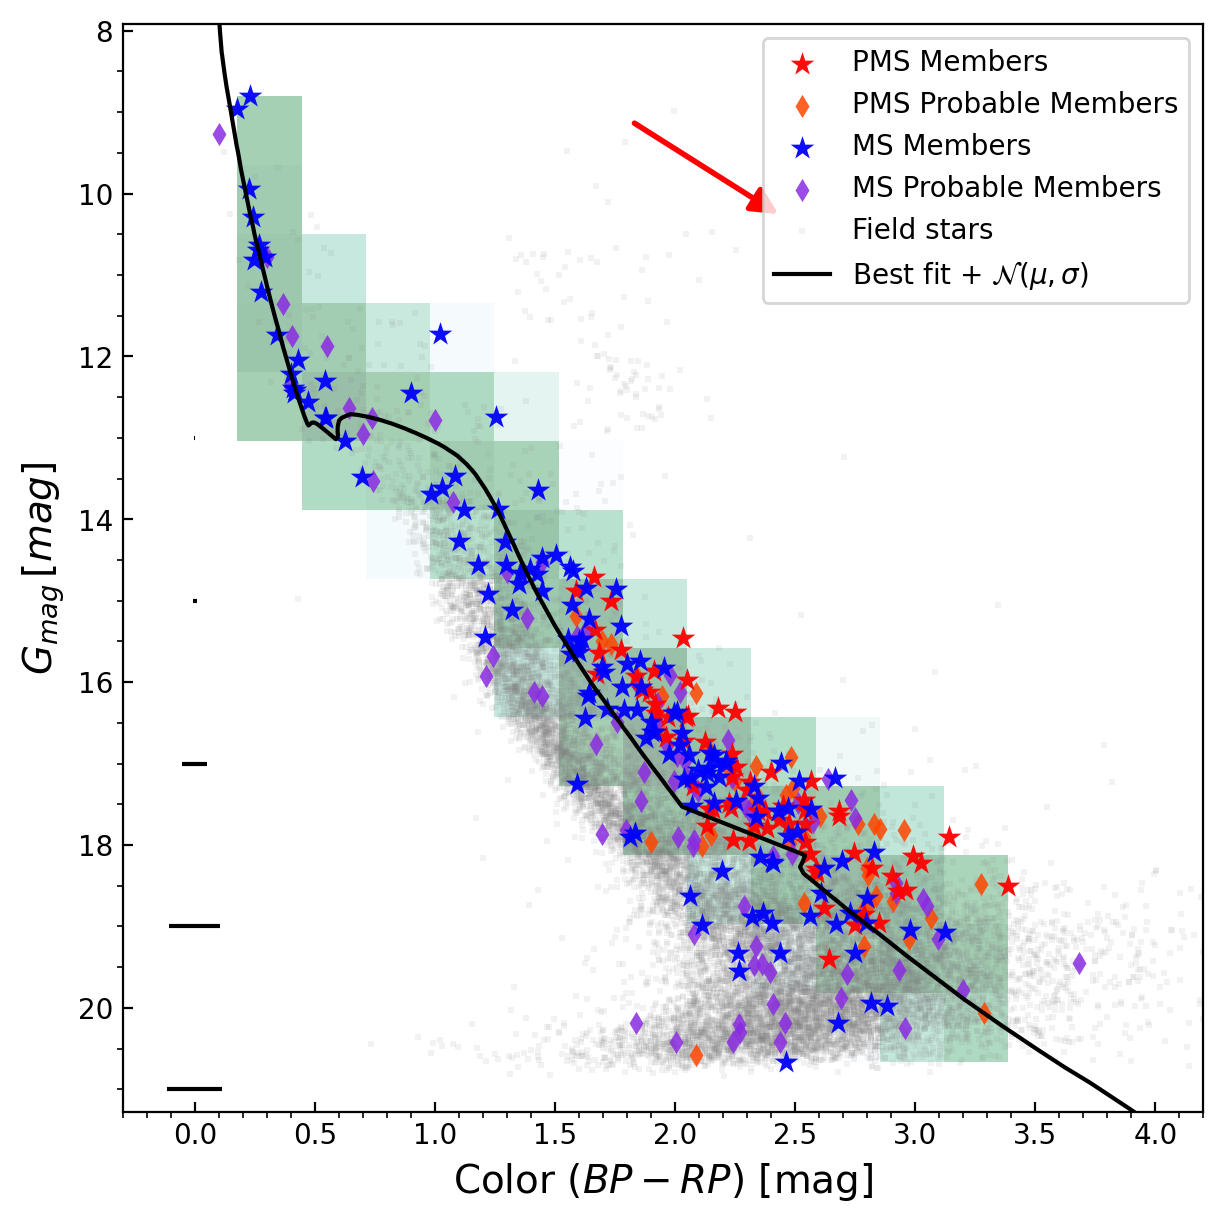

In [82]:
cmd_gaia = np.load('ASteCA/output/NGC_6383_dr3_all.npz')
phot_Nsigma_gaia = cmd_gaia['phot_Nsigma']
hess_xedges_gaia, hess_yedges_gaia = cmd_gaia['hess_xedges'], cmd_gaia['hess_yedges']
# Generate 69 evenly spaced values from 0 to 1
cmap = ListedColormap(plt.colormaps['BuGn'](np.linspace(0, 1, 69)))

x_isoch_gaia, y_isoch_gaia = cmd_gaia['x_isoch'],cmd_gaia['y_isoch']
x0_gaia,y0_gaia, dx_gaia, dy_gaia = cmd_gaia['arrow']

prop = dict(arrowstyle="-|>,head_width=0.4,head_length=0.8",color='red', shrinkA=0, shrinkB=0, lw=2)

fig_cmd, ax_cmd = plt.subplots(1,1, layout='constrained', figsize=(6,6))

ax_cmd.hist2d(*phot_Nsigma_gaia, bins=(hess_xedges_gaia, hess_yedges_gaia), cmap=cmap, norm=LogNorm(), zorder=-1,alpha=0.4)
ax_cmd.scatter(data_gaia['BP_RP'][pms_high],data_gaia['Gmag'][pms_high],s=80,alpha=0.95,lw=0,marker='*',c='red',label='PMS Members',zorder=5)
ax_cmd.scatter(data_gaia['BP_RP'][pms_low],data_gaia['Gmag'][pms_low],s=35,alpha=0.85,lw=0,marker='d',c='orangered',label='PMS Probable Members',zorder=4)
ax_cmd.scatter(data_gaia['BP_RP'][nopms_high],data_gaia['Gmag'][nopms_high],s=80,alpha=0.95,lw=0,marker='*',c='blue',label='MS Members',zorder=5)
ax_cmd.scatter(data_gaia['BP_RP'][nopms_low],data_gaia['Gmag'][nopms_low],s=35,alpha=0.85,lw=0,marker='d',c='blueviolet',label='MS Probable Members',zorder=4)
ax_cmd.scatter(data_gaia['BP_RP'][noise],data_gaia['Gmag'][noise],s=6,alpha=0.1,lw=0,marker=',',c='gray',label='Field stars',zorder=1)
ax_cmd.plot(x_isoch_gaia, y_isoch_gaia, c='k',label=r'Best fit + $\mathcal{N}(\mu,\sigma)$',zorder=6)
ax_cmd.annotate("", xy=(x0_gaia + dx_gaia, y0_gaia + dy_gaia), xytext=(x0_gaia, y0_gaia), arrowprops=prop)
ax_cmd.set(adjustable='datalim',xlim=[-0.3,4.2],ylim=[0.9*np.min(data_gaia['Gmag'][cluster]),1.03*np.max(data_gaia['Gmag'][cluster])])
ax_cmd.set_xlabel(r'Color $(BP - RP)$ [{}]'.format(data_gaia['BP_RP'].unit),fontsize=14)
ax_cmd.set_ylabel(r'$G_{{mag}}\,[{}]$'.format(data_gaia['Gmag'].unit),fontsize=14)
plot_errors_bar(data_gaia[cluster]['Gmag'],data_gaia[cluster]['BP_RP'], data_gaia[cluster]['e_Gmag'], data_gaia[cluster]['e_BP_RP'], ax_cmd)
ax_cmd.xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_cmd.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_cmd.tick_params(axis='both', which='major',direction='in')
ax_cmd.legend() # legend added
ax_cmd.invert_yaxis()

fig_cmd.savefig('Tex_File/Figures/ngc6383_cmd.pdf',dpi=1500);

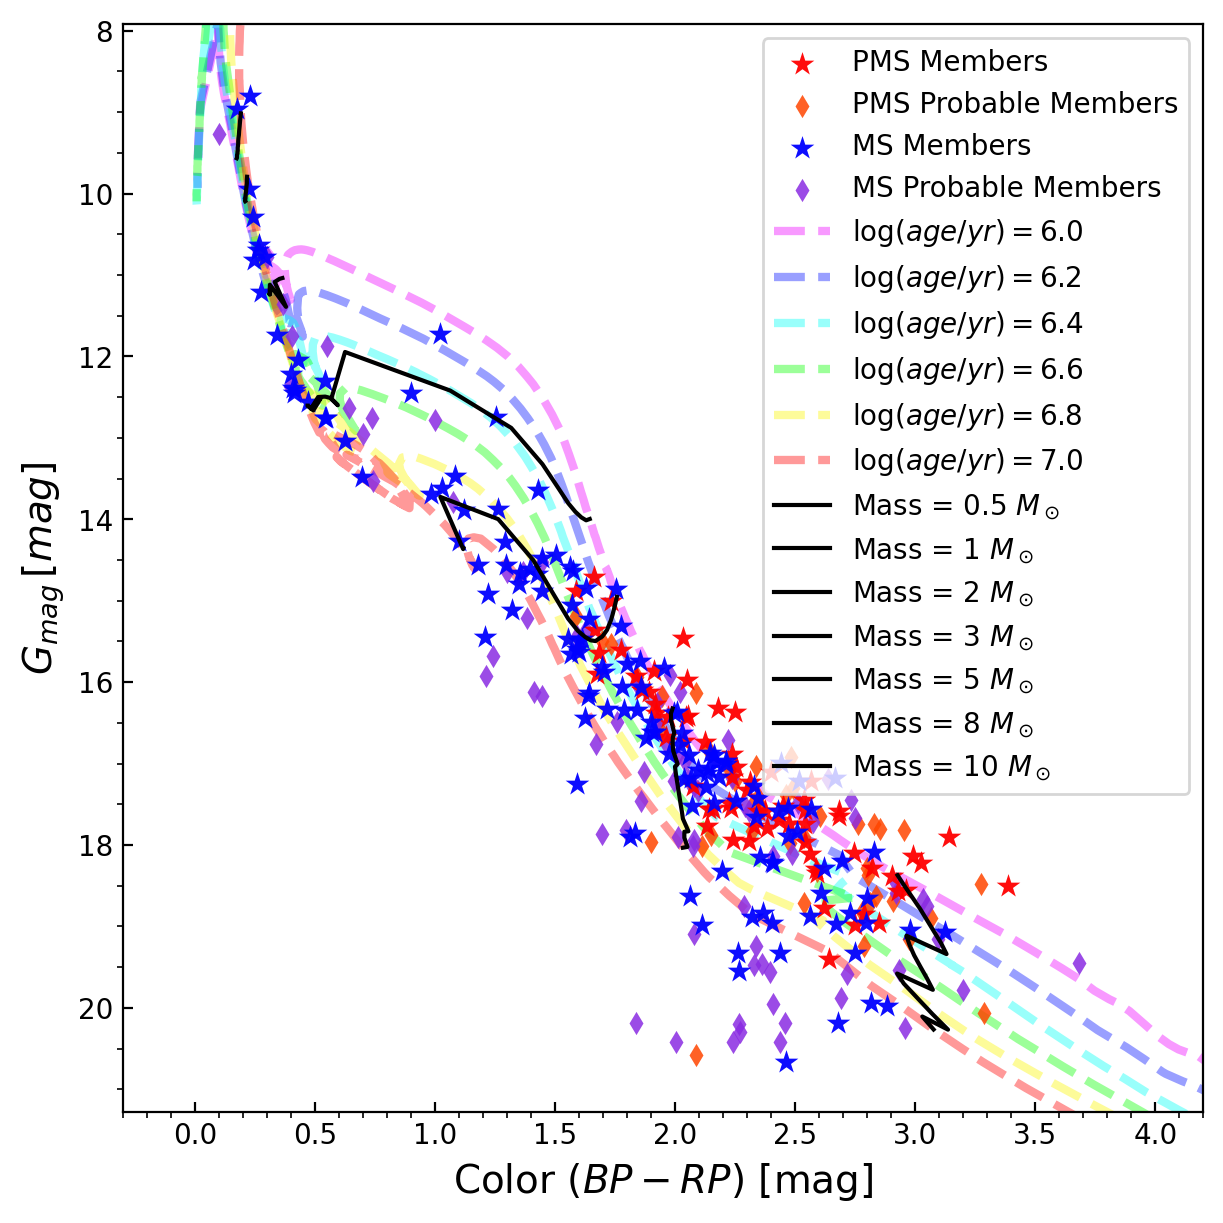

In [83]:
fig_mass, ax_mass = plt.subplots(1, 1, layout='constrained', figsize=(6, 6))

ax_mass.scatter(data_gaia['BP_RP'][pms_high],data_gaia['Gmag'][pms_high],s=80,alpha=0.95,lw=0,marker='*',c='red',label='PMS Members',zorder=5)
ax_mass.scatter(data_gaia['BP_RP'][pms_low],data_gaia['Gmag'][pms_low],s=35,alpha=0.85,lw=0,marker='d',c='orangered',label='PMS Probable Members',zorder=4)
ax_mass.scatter(data_gaia['BP_RP'][nopms_high],data_gaia['Gmag'][nopms_high],s=80,alpha=0.95,lw=0,marker='*',c='blue',label='MS Members',zorder=5)
ax_mass.scatter(data_gaia['BP_RP'][nopms_low],data_gaia['Gmag'][nopms_low],s=35,alpha=0.85,lw=0,marker='d',c='blueviolet',label='MS Probable Members',zorder=4)
yl_gaia = ax_mass.get_ylim()

# Aggregate mass data across all isochrones
aggregated_mass_data = {}  # Correctly initialize as a dictionary

# Iterate through isochrones to collect mass data
for i, logAge in enumerate(logAges):
    color = colors[i]
    plot_isochrone(all_isochrones_DR3, round(logAge, 5), Zini, color_row='BP_RP', mag_row='Gmag', ax=ax_mass, dm=10.3, A_V=1.8, color=color, linestyle='--', yl=yl_gaia)
plot_iso_mass_curves_across_isochrones(all_isochrones_DR3, [6,7], Zini, ax_mass, dm=10.3, A_V=1.8, color='k', linestyle='-', mass_values=[0.5, 1,2, 3, 5, 8,10],zorder=100)
# Adjust plot settings
ax_mass.set(adjustable='datalim',xlim=[-0.3,4.2],ylim=[0.9*np.min(data_gaia['Gmag'][cluster]),1.03*np.max(data_gaia['Gmag'][cluster])])
ax_mass.set_xlabel(r'Color $(BP - RP)$ [{}]'.format(data_gaia['BP_RP'].unit),fontsize=14)
ax_mass.set_ylabel(r'$G_{{mag}}\,[{}]$'.format(data_gaia['Gmag'].unit),fontsize=14)
ax_mass.xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_mass.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_mass.tick_params(axis='both', which='major',direction='in')
ax_mass.legend() # legend added
ax_mass.invert_yaxis()

plt.show()

# Save the figure
fig_mass.savefig('Tex_File/Figures/ngc6383_isomass.pdf',bbox_inches='tight');

## Masses

In [49]:
data_gaia.colnames

['solution_id',
 'designation',
 'source_id',
 'random_index',
 'ref_epoch',
 'ra',
 'ra_error',
 'dec',
 'dec_error',
 'parallax_observed',
 'parallax_error',
 'parallax_over_error',
 'pm',
 'pmra',
 'pmra_error',
 'pmdec',
 'pmdec_error',
 'ra_dec_corr',
 'ra_parallax_corr',
 'ra_pmra_corr',
 'ra_pmdec_corr',
 'dec_parallax_corr',
 'dec_pmra_corr',
 'dec_pmdec_corr',
 'parallax_pmra_corr',
 'parallax_pmdec_corr',
 'pmra_pmdec_corr',
 'astrometric_n_obs_al',
 'astrometric_n_obs_ac',
 'astrometric_n_good_obs_al',
 'astrometric_n_bad_obs_al',
 'astrometric_gof_al',
 'astrometric_chi2_al',
 'astrometric_excess_noise',
 'astrometric_excess_noise_sig',
 'astrometric_params_solved',
 'astrometric_primary_flag',
 'nu_eff_used_in_astrometry',
 'pseudocolour',
 'pseudocolour_error',
 'ra_pseudocolour_corr',
 'dec_pseudocolour_corr',
 'parallax_pseudocolour_corr',
 'pmra_pseudocolour_corr',
 'pmdec_pseudocolour_corr',
 'astrometric_matched_transits',
 'visibility_periods_used',
 'astrometric_si

In [52]:
mass_isochrone = assign_mass_nearest_isochrone_point_kdtree(all_isochrones_DR3, data_gaia[cluster & (data_gaia['probability'] >= 0.7)], (6,7), 0.06, 'BP_RP', 'Gmag', 10.3, 1.8)
asteca_mass = QTable.read('ASteCA/output/NGC_6383_dr3_all/NGC_6383_dr3_all_mass.dat',format='ascii')

In [53]:
masses = join(mass_isochrone,asteca_mass,keys_left='designation',keys_right='ID',join_type='outer')
for i in masses:
    if i['P_binar'] >= 0.6:
        i['mass'] = (i['M1'] + i['M2'])*u.Msun

In [54]:
data_gaia = join(data_gaia,masses['designation','mass','M2','P_binar'],keys='designation',join_type='left')

TableMergeError: Right key column 'designation' has missing values

In [87]:
if not any(column in data_gaia.colnames for column in ['av_sagitta', 'pms_sagitta', 'age']):
    # If none of the columns exist in data_gaia, perform the join operation
    data_gaia = join(data_gaia, pms['source_id', 'av_sagitta', 'pms_sagitta', 'age'], keys='source_id', join_type='left')
    data_gaia['pms_sagitta'] = data_gaia['pms_sagitta'].filled(0)
    data_gaia['mass']

In [88]:
for column_name in data_gaia.colnames:
    if hasattr(data_gaia[column_name], 'mask'):  # Check if the column has a mask attribute
        # Convert column to float if it's an integer type
        if np.issubdtype(data_gaia[column_name].dtype, np.integer):
            data_gaia[column_name] = data_gaia[column_name].astype(float)
        # Now safe to fill masked values with np.nan
        data_gaia[column_name] = data_gaia[column_name].filled(np.nan)

In [89]:
prob_thresholds = [0.5, 0.6, 0.7, 0.8]

for i in prob_thresholds:
    condition = data_gaia[cluster]['probability'] >= i 
    condition_mag = (data_gaia[cluster]['probability'] >= i) & (data_gaia[cluster]['Gmag'] <= 18*u.mag)
    print(len(data_gaia[cluster][condition]),len(data_gaia[cluster][condition_mag]))

328 241
257 198
205 161
167 135


In [90]:
len(masses[masses['P_binar'] >= 0.6])/len(masses)

0.35609756097560974

## Parallax

In [224]:
def distance_model(data, return_trace=False, progressbar=False,prior_type='uniform'):
    prior_mu_r = np.mean([np.mean(1 / data['parallax']).value, 1 / np.mean(data['parallax']).value])*u.mas
    with pm.Model() as distance_model:
        # Hyperprior for the mean distance to the star cluster
        if prior_type == 'uniform':
            mu_r = pm.Uniform("mu_r", lower=0.5*prior_mu_r, upper=1.5*prior_mu_r)
        elif prior_type == 'normal':
            mu_r = pm.TruncatedNormal("mu_r", lower=0.5*prior_mu_r, upper=1.5*prior_mu_r,mu=prior_mu_r,sigma=1)
        std_r = pm.Uniform("std_r", lower=10E-8,upper=1)
        # Model for the distances to each star
        r = pm.TruncatedNormal("r", mu_r, std_r, shape=len(data), lower=0, upper=np.inf)
        # Model the observed parallax directly
        # Likelihood for the observed parallax
        pm.Normal("observed_parallax", mu=1 / r, sigma=data["parallax_error"], observed=data["parallax"])

    # Iterative sampling process
    max_rhat = 2.0
    target_accept = 0.9
    tune = 4000

    while max_rhat > 1.0:
        with distance_model:
            trace = pm_jax.sample_numpyro_nuts(draws=10000, tune=tune, target_accept=target_accept, progressbar=progressbar)
            
            # Using ArviZ to compute rhat values
            rhat_vals = az.rhat(trace, var_names=['~r'])
            # Extract the maximum rhat value
            max_rhat = np.round(np.max(rhat_vals.to_array()), 2)
            
            if target_accept <= 0.9999999:
                target_accept += 0.05
            tune += 2000

    results = {
        'mu_r_mean': trace.posterior['mu_r'].mean().item(),
        'std_r_mean': trace.posterior['std_r'].mean().item(),
        'mu_r_std': trace.posterior['mu_r'].std().item(),
        'std_r_std': trace.posterior['std_r'].std().item(),
    }

    if return_trace:
        results['trace_distance'] = trace
    return results

In [225]:
def fit_parallax_model(data, return_trace=False, progressbar=False,prior_distance=None,prior_type='uniform'):
    with pm.Model() as plx_model:
        # Prior for the mean true parallax of the cluster
        if prior_type == 'uniform':
            if prior_distance:
                mu_parallax = pm.Uniform("mu_parallax", lower=0.5*(1/prior_distance),upper=1.5*(1/prior_distance))
            else:
                mu_parallax = pm.Uniform("mu_parallax", lower=0.5*np.mean(data['parallax']),upper=1.5*np.mean(data['parallax']))
        if prior_type == 'normal':
            if prior_distance:
                mu_parallax = pm.TruncatedNormal("mu_parallax", lower=0.5*(1/prior_distance),upper=1.5*(1/prior_distance),sigma=1,mu=(1/prior_distance))
            else:
                mu_parallax = pm.TruncatedNormal("mu_parallax", lower=0.5*np.mean(data['parallax']),upper=1.5*np.mean(data['parallax']),sigma=1,mu=np.mean(data['parallax']))
        # Prior for the standard deviation of the true parallaxes within the cluster
        sigma_parallax = pm.HalfNormal("sigma_parallax", sigma=np.std(data['parallax']))
        
        # Likelihood for observed parallaxes, considering observational errors
        observed_parallax = pm.Normal("observed_parallax", mu=mu_parallax, 
                                      sigma=sigma_parallax, observed=data["parallax"])
        # Sampling
    max_rhat = 2.0
    target_accept = 0.9
    tune = 4000
    while max_rhat > 1.0:
        with plx_model:
            trace = pm_jax.sample_numpyro_nuts(draws=10000, tune=tune, target_accept=target_accept, progressbar=progressbar)
            
            # Using ArviZ to compute rhat values
            rhat_vals = az.rhat(trace)
            # Extract the maximum rhat value
            max_rhat = np.round(np.max(rhat_vals.to_array()), 2)
            
            if target_accept <= 0.9999999:
                target_accept += 0.05
            tune += 2000
    results = {
        'mu_parallax_mean': np.mean(trace.posterior['mu_parallax'].values),
        'sigma_parallax_mean': np.mean(trace.posterior['sigma_parallax'].values),
        'mu_parallax_std': np.std(trace.posterior['mu_parallax'].values),
        'sigma_parallax_std': np.std(trace.posterior['sigma_parallax'].values),
    }
    if return_trace:
        results['trace_parallax'] = trace
    return results

In [226]:
def parallax_determination(data, prob_thresholds=[50, 60, 70, 80], return_trace=False, progressbar=False, savefig=None, prior_type='uniform', paper_single=False, parallax_hist=True):
    prob_number = np.array(prob_thresholds) / 100
    num_types = 2 if paper_single else 3  # Adjust the number of types of graphics based on 'paper_single'
    
    # Adjust num_rows if parallax_hist is True
    num_rows = num_types + (1 if parallax_hist else 0)
    # Determine the grid layout
    num_cols = len(prob_number)  # Number of columns is equal to the number of thresholds
    
    # Create the subplots with dynamic layout
    if paper_single:
        if parallax_hist:
            figsize = (17,5)
        else:
            figsize=(13,5)
    else:
        figsize = (6 * num_cols, 4.5 * num_rows)
    if paper_single:
        fig, axes = plt.subplots(num_cols,num_rows, figsize=figsize, constrained_layout=True)
    else:
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, constrained_layout=True)
    # Ensure axes is a 2D array for consistency in indexing
    axes = np.atleast_2d(axes)
    
    # If paper_single, adjust axes for a single plot type
    results_distance = {
         'mu_r_mean': [],
        'std_r_mean': [],
        'mu_r_std': [],
        'std_r_std': [],
    }
    results_parallax = {
        'mu_parallax_mean': [],
        'sigma_parallax_mean': [],
        'mu_parallax_std': [],
        'sigma_parallax_std': [],
    }
    all_traces = []
    min_data = (data['probability'] >= np.min(prob_number))
    data = data[min_data]
    for j, prob_threshold in enumerate(prob_number):
        print(f"{prob_threshold * 100}%")
        # Filter data based on probability threshold
        filtered_data = data[data['probability'] >= prob_threshold]
        error_criteria = (filtered_data['parallax_error']/filtered_data['parallax']) <= 0.1
        useful_data = filtered_data[error_criteria]
        nonuseful_data = filtered_data[~error_criteria]
        # Assuming you have a way to get 'model_results' from your 'parallax_model' function call
        print('Distance sampling')
        distance_model_results = distance_model(useful_data, return_trace, progressbar)# Placeholder function call
        print('Parallax sampling')
        parallax_model_results = fit_parallax_model(useful_data, return_trace, progressbar,prior_distance=distance_model_results['mu_r_mean'],prior_type='uniform')
        mean_parallax = parallax_model_results['mu_parallax_mean']
        std_mean_parallax = parallax_model_results['mu_parallax_std']
        std_parallax = parallax_model_results['sigma_parallax_mean']
        if parallax_hist:
            ax0 = axes[0, j]
            ax0.axvline(mean_parallax, color='g', linestyle='--', label=r'$\mu_\varpi = {:.3f}\pm{:.3f}\,[{}]$'.format(mean_parallax,std_mean_parallax,u.mas))
            _,bins,_ = ax0.hist(useful_data['parallax'], bins='auto', color='red', alpha=0.95, histtype='step', label='Useful parallax')
            ax0.hist(filtered_data['parallax'], bins=bins, color='orange', alpha=0.95, histtype='step', label='Parallax')
            ax0.hist(nonuseful_data['parallax'], bins=bins, color='green', alpha=0.95, histtype='step', label='Non useful parallax')
            bin_width = np.diff(bins)[0]
            scaling_factor = len(useful_data) * bin_width
            x = np.linspace(mean_parallax - 3*std_parallax,mean_parallax + 3*std_parallax , 100)
            p = norm.pdf(x, mean_parallax, std_parallax) * scaling_factor  # Scale the PDF by the scaling factor
            ax0.plot(x, p)
            ax0.set_ylim(0, ax0.get_ylim()[1])
            ax0.fill_betweenx(y=[0, 1.5*ax0.get_ylim()[1]], x1=mean_parallax - std_mean_parallax, x2=mean_parallax + std_mean_parallax, color='blue', alpha=0.05,label='Standard desviation')
            ax0.set_xlabel(r'$\varpi$ [{}]'.format(data['parallax'].unit),fontsize=16)
            ax0.set_ylabel('Counts',fontsize=16)
            ax0.legend(loc='upper left',fontsize=10)
            if paper_single:
                ax1 = axes[j,1]
            else:
                ax1 = axes[1, j]
        else:
            ax1 = axes[0, j]
        ax1.scatter(useful_data['parallax'], useful_data['Gmag'], s=10, alpha=0.9,c='red',edgecolor='blue',label='Used for distance estimation')
        ax1.scatter(nonuseful_data['parallax'], nonuseful_data['Gmag'], s=10, alpha=0.9,c='red',label='Not used for distance estimation')
        ax1.errorbar(filtered_data['parallax'], filtered_data['Gmag'], xerr=filtered_data['parallax_error'], fmt='none', alpha=0.3,capsize=0,elinewidth=0.5,color='gray')
        ax1.axvline(mean_parallax, color='g', linestyle='--', label=r'$\mu_\varpi = {:.3f}\pm{:.3f}\,[{}]$'.format(mean_parallax,std_parallax,u.mas))
        ax1.set_xlabel(r'$\varpi$ [{}]'.format(data['parallax'].unit),fontsize=15)
        ax1.set_ylabel(r'$G_\mathrm{mag}$',fontsize=15)
        ax1.set_xlim(mean_parallax-15*std_parallax,mean_parallax+15*std_parallax)
        lim_y_ax1 = ax1.get_ylim()
        ax1.fill_betweenx(y=[lim_y_ax1[0], 1.5*lim_y_ax1[1]], x1=mean_parallax - std_parallax, x2=mean_parallax + std_parallax, color='blue', alpha=0.05,label='Standard desviation')
        ax1.set_ylim(lim_y_ax1)
        ax1.invert_yaxis()
        ax1.legend(loc='upper left',framealpha=0.3,fontsize=10)
        # Second type of graphic: Histogram of inverse parallax with sampled distance chains
        if parallax_hist:
            if paper_single:
                ax2 = axes[j,2]
            else:
                ax2 = axes[2, j]
        else:
            ax2 = axes[j,1]
        _,bins,_ = ax2.hist(1/useful_data['parallax'], bins='auto', color='red', alpha=0.95, histtype='step', label='Used for distance estimation')
        ax2.hist(1 / filtered_data['parallax'], bins=bins, color='orange', alpha=0.95, histtype='step', label='All sources')
        ax2.hist(1/nonuseful_data['parallax'], bins=bins, color='green', alpha=0.95, histtype='step', label='Not used for distance estimation')
        # Store results
        for key in results_distance.keys():
            results_distance[key].append(distance_model_results[key])
        for key in results_parallax.keys():
            results_parallax[key].append(parallax_model_results[key])
        mean_distance = distance_model_results['mu_r_mean']
        std_distance = distance_model_results['std_r_mean']
        ax2.axvline(mean_distance, color='blue', linestyle='--',label=f'$\mu_d: {mean_distance:.3f} \pm$ {std_distance:.3f} kpc')
        ax2.set_ylim(0, ax2.get_ylim()[1])
        ax2.fill_betweenx(y=[0, 1.5*ax2.get_ylim()[1]], x1=mean_distance - std_distance, x2=mean_distance + std_distance, color='blue', alpha=0.05,label='Standard desviation')
        ax2.set_xlabel('Distance [kpc]',fontsize=16)
        ax2.set_ylabel('Counts',fontsize=16)
        ax2.legend(loc='upper right')
        
        # Fine-tuning the plots
        for ax in axes.flatten():
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.tick_params(axis='both', which='both', direction='in',labelsize=13)
        if return_trace:
            all_traces.append(distance_model_results['trace_distance'])
            all_traces.append(parallax_model_results['trace_parallax'])
    if savefig:
        if paper_single:
            plt.savefig(savefig + 'parallax_determination_paper.pdf',bbox_inches='tight')
        else:
            plt.savefig(savefig + 'parallax_determination.pdf',bbox_inches='tight')
    plt.show()
    results = {}
    results.update(results_distance),results.update(results_parallax)
    return results  # or any other results you wish to return

60.0%
Distance sampling


There were 10447 divergences after tuning. Increase `target_accept` or reparameterize.


Parallax sampling


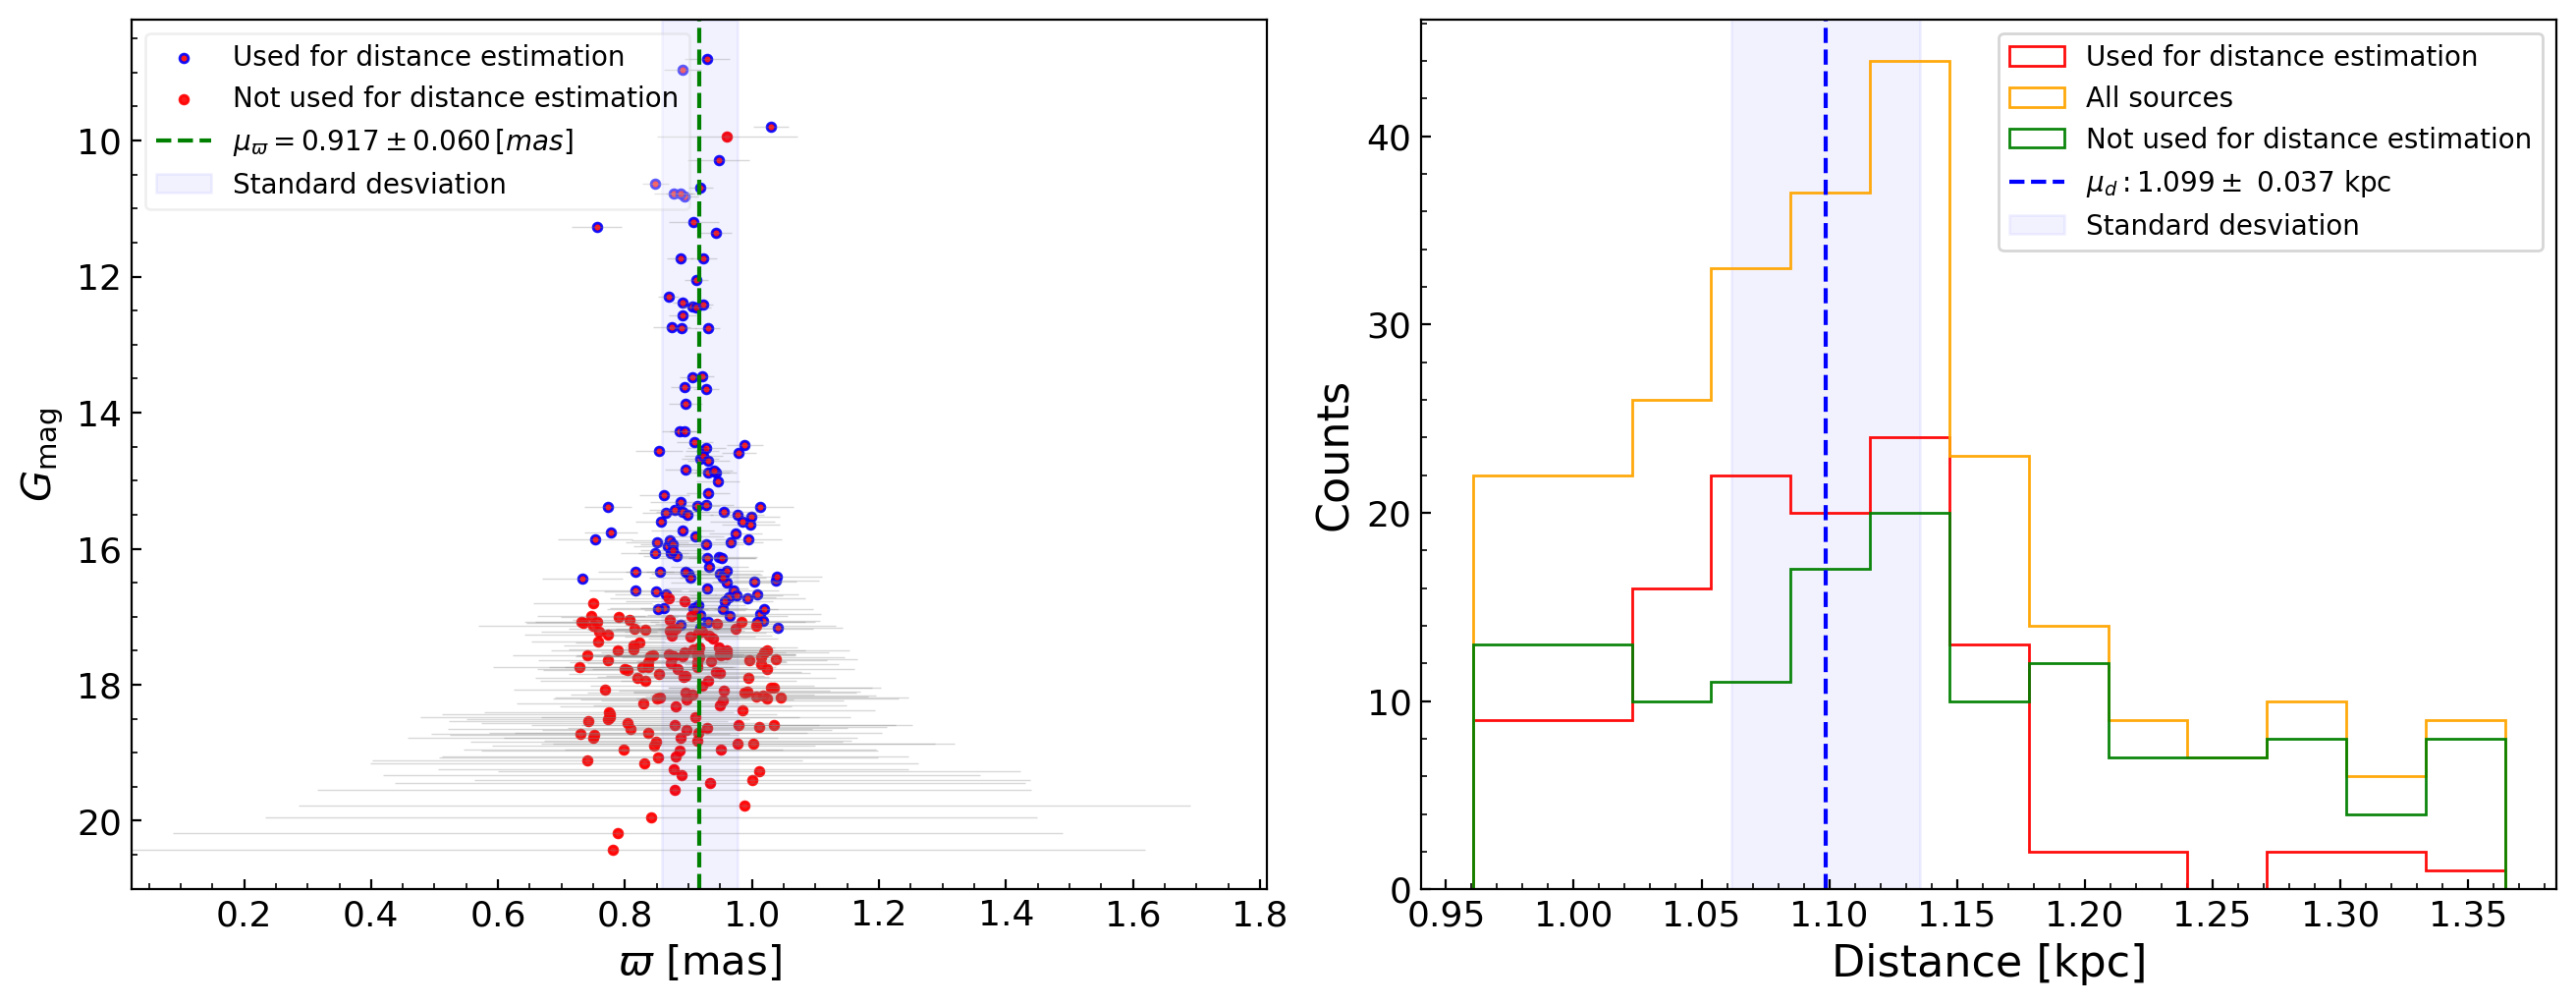

In [223]:
parallax_results = parallax_determination(data_gaia[cluster], return_trace=True,savefig='Tex_File/Figures/',prob_thresholds=[60],paper_single=True,parallax_hist=False)

## Proper motion

In [227]:
def FitProperMotion2DGaussian(pm_RA, pm_Dec, return_trace=False, progressbar=False):
    pm_RA = ensure_units(pm_RA, u.mas/u.yr)
    pm_Dec = ensure_units(pm_Dec, u.mas/u.yr)
    mpm_RA = np.median(pm_RA)
    mpm_DEC = np.median(pm_Dec)
    std_RA = np.std(pm_RA)
    std_DEC = np.std(pm_Dec)
    with pm.Model() as pm_model:
        # Priors for 2D Gaussian parameters
        #mu_RA = pm.Uniform('mu_RA', lower=0.5*mpm_RA,upper=1.5*mpm_RA)
        #mu_Dec = pm.Uniform('mu_Dec', lower=0.5*mpm_DEC,upper=1.5*mpm_DEC)
        mu_RA = pm.Normal('mu_RA',mu=mpm_RA,sigma=std_RA)
        mu_Dec = pm.Normal('mu_Dec',mu=mpm_DEC,sigma=std_DEC)
        sigma_RA = pm.HalfNormal('sigma_RA', sigma=std_RA)
        sigma_Dec = pm.HalfNormal('sigma_Dec', sigma=std_DEC)
        corr = pm.Uniform('corr', lower=-1, upper=1)

        # Covariance matrix
        cov = pm.math.stack([[sigma_RA**2, corr * sigma_RA * sigma_Dec],
                             [corr * sigma_RA * sigma_Dec, sigma_Dec**2]])

        # Multivariate normal likelihood
        obs = pm.MvNormal('obs', mu=pm.math.stack([mu_RA, mu_Dec]), cov=cov, observed=np.stack([pm_RA, pm_Dec], axis=1))

        # Iterative sampling parameters
        max_rhat = 2.0  
        target_accept = 0.8
        tune = 4000

        while max_rhat > 1.0:
            with pm_model:
                pm_trace = pm_jax.sample_numpyro_nuts(draws=10000, tune=tune, target_accept=target_accept, progressbar=progressbar)
                rhat_vals = az.rhat(pm_trace)
            # Extract the maximum rhat value
            max_rhat = round(np.max(rhat_vals.to_array().values),2)
            if target_accept <= 0.9999999:
                target_accept += 0.05
            tune += 2000
        
        # Extracting the posterior statistics
        mu_RA_mean = pm_trace.posterior['mu_RA'].mean().item()
        mu_Dec_mean = pm_trace.posterior['mu_Dec'].mean().item()
        sigma_RA_mean = pm_trace.posterior['sigma_RA'].mean().item()
        sigma_Dec_mean = pm_trace.posterior['sigma_Dec'].mean().item()
        corr_mean = pm_trace.posterior['corr'].mean().item()

        mu_RA_std = pm_trace.posterior['mu_RA'].std().item()
        mu_Dec_std = pm_trace.posterior['mu_Dec'].std().item()
        sigma_RA_std = pm_trace.posterior['sigma_RA'].std().item()
        sigma_Dec_std = pm_trace.posterior['sigma_Dec'].std().item()
        corr_std = pm_trace.posterior['corr'].std().item()

        bayesian_results = {
            'mu_RA_mean': mu_RA_mean,
            'mu_Dec_mean': mu_Dec_mean,
            'sigma_RA_mean': sigma_RA_mean,
            'sigma_Dec_mean': sigma_Dec_mean,
            'corr_mean': corr_mean,
            'mu_RA_std': mu_RA_std,
            'mu_Dec_std': mu_Dec_std,
            'sigma_RA_std': sigma_RA_std,
            'sigma_Dec_std': sigma_Dec_std,
            'corr_std': corr_std
        }
        results = {'results': bayesian_results}

        if return_trace:
            results['trace'] = pm_trace

        return results

In [232]:
def pm_determination(data, savefig=None, prob_number=[50, 60, 70, 80], progressbar=False,return_trace=False,return_pmdist=False,return_pmprob=False,paper_single=False):
    prob_number = np.array(prob_number) / 100
    if len(prob_number) == 1:
        fig, axes = plt.subplots(1, layout='constrained', figsize=(7,5))
    elif len(prob_number) == 2:
        fig, axes = plt.subplots(1, 2, layout='constrained', figsize=(17.5,7))
    elif len(prob_number) == 3:
        fig, axes = plt.subplots(1, 3, layout='constrained', figsize=(13,13))
    elif len(prob_number) == 4:
        fig, axes = plt.subplots(2, 2, layout='constrained', figsize=(13,13))
    else:
        raise ValueError("Unsupported number of probability thresholds")

    stats_results = []
    distance_pm = []
    pm_prob = []
    if len(prob_number) == 1:
        axes = np.array([axes])
    min_data = (data['probability'] >= np.min(prob_number))
    data = data[min_data]
    # Determine the overall grid range
    total_pm_RA = data['pmra']
    total_pm_DEC = data['pmdec']
    added_space_ra = (np.max(total_pm_RA) - np.min(total_pm_RA)) / 8
    added_space_dec = (np.max(total_pm_DEC) - np.min(total_pm_DEC)) / 8
    grid_RA, grid_DEC = np.meshgrid(
        np.linspace(np.min(total_pm_RA) - added_space_ra, np.max(total_pm_RA) + added_space_ra, 700),
        np.linspace(np.min(total_pm_DEC) - added_space_dec, np.max(total_pm_DEC) + added_space_dec, 700)
    )

    for i, ax in zip(prob_number, axes.flatten()):
        print(f"{i * 100}%")
        # Filter the data based on the probability threshold
        probability_selection = (data['probability'] >= i)
        iterative_data = data[probability_selection]
        pm_RA = iterative_data['pmra']
        pm_DEC = iterative_data['pmdec']
        error_RA = iterative_data['pmra_error']
        error_Dec = iterative_data['pmdec_error']
        probability = iterative_data['probability']
        # Perform Bayesian analysis for the filtered data
        trace_results = FitProperMotion2DGaussian(pm_RA, pm_DEC, progressbar=progressbar)

        # Extract Bayesian analysis results
        bayesian_results = trace_results['results']
        
        # Extract and store the statistics
        stats = {
            'probability': i,
            'mu_RA_mean': bayesian_results['mu_RA_mean'],
            'mu_Dec_mean': bayesian_results['mu_Dec_mean'],
            'sigma_RA_mean': bayesian_results['sigma_RA_mean'],
            'sigma_Dec_mean': bayesian_results['sigma_Dec_mean'],
            'corr_mean': bayesian_results['corr_mean'],
            'mu_RA_std': bayesian_results['mu_RA_std'],
            'mu_Dec_std': bayesian_results['mu_Dec_std'],
            'sigma_RA_std': bayesian_results['sigma_RA_std'],
            'sigma_Dec_std': bayesian_results['sigma_Dec_std'],
            'corr_std': bayesian_results['corr_std']
        }
        if return_trace:
            stats['trace'] = trace_results.get('trace')
        stats_results.append(stats)
        # Create a 2D Gaussian distribution with mean parameters
        rv = multivariate_normal([bayesian_results['mu_RA_mean'], bayesian_results['mu_Dec_mean']],
                                 [[bayesian_results['sigma_RA_mean']**2, 
                                   bayesian_results['corr_mean'] * bayesian_results['sigma_RA_mean'] * bayesian_results['sigma_Dec_mean']],
                                  [bayesian_results['corr_mean'] * bayesian_results['sigma_RA_mean'] * bayesian_results['sigma_Dec_mean'], 
                                   bayesian_results['sigma_Dec_mean']**2]])
        density = rv.pdf(np.dstack([grid_RA, grid_DEC]))
        max_density_idx = np.argmax(density)
        max_density_coords = (grid_RA.ravel()[max_density_idx], grid_DEC.ravel()[max_density_idx])
            
        # Contour plot and scatter plot
        ax.contour(grid_RA, grid_DEC, density, levels=10, cmap=sns.color_palette("flare_r", as_cmap=True))
        sc = ax.scatter(pm_RA, pm_DEC, s=25, alpha=0.8, marker='*',c='purple')
        #fig.colorbar(sc).set_label('Probability')
        ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue')
        ax.axvline(max_density_coords[0], color='darkorange', ls='--')
        ax.axhline(max_density_coords[1], color='darkorange', ls='--')
        # Axis labels and title
        ax.set_xlabel(r'$\mu_\alpha*$ [mas/yr]',fontsize=16)
        ax.set_ylabel(r'$\mu_\delta$ [mas/yr]',fontsize=16)

        # Fine-tuning the plot
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in',labelsize=13)
        ax.set_aspect('equal')
        legend_label = r'$C = ({:.4f},{:.4f})\;{}$'.format(max_density_coords[0].value, max_density_coords[1].value, (u.mas/u.yr))
        ax.legend([legend_label], loc='best', framealpha=0.8,fontsize=10)
        if return_pmdist:
            distance_center_pm = np.sqrt((pm_RA - bayesian_results['mu_RA_mean']*(u.mas/u.yr))**2 + (pm_DEC - bayesian_results['mu_Dec_mean']*(u.mas/u.yr))**2)
            distancepm = {
                'probability': i,
                'distancepm': 1/distance_center_pm}
            distance_pm.append(distancepm)
            if return_pmprob:
                pmprob_ = (1/distance_center_pm)*iterative_data['probability']
                pm_prob.append(pmprob_)
    # Save the figure if a path is provided
    if savefig:
        if paper_single:
            fig.savefig(f"{savefig}proper_motion_2d_paper.pdf",bbox_inches='tight')
        else:
            fig.savefig(f"{savefig}proper_motion_2d.pdf",bbox_inches='tight')
    plt.show()
    if return_pmdist and return_pmprob:
        return stats_results, distance_pm, pm_prob
    elif return_pmdist:
        return stats_results, distance_pm
    else:
        return stats_results

60.0%


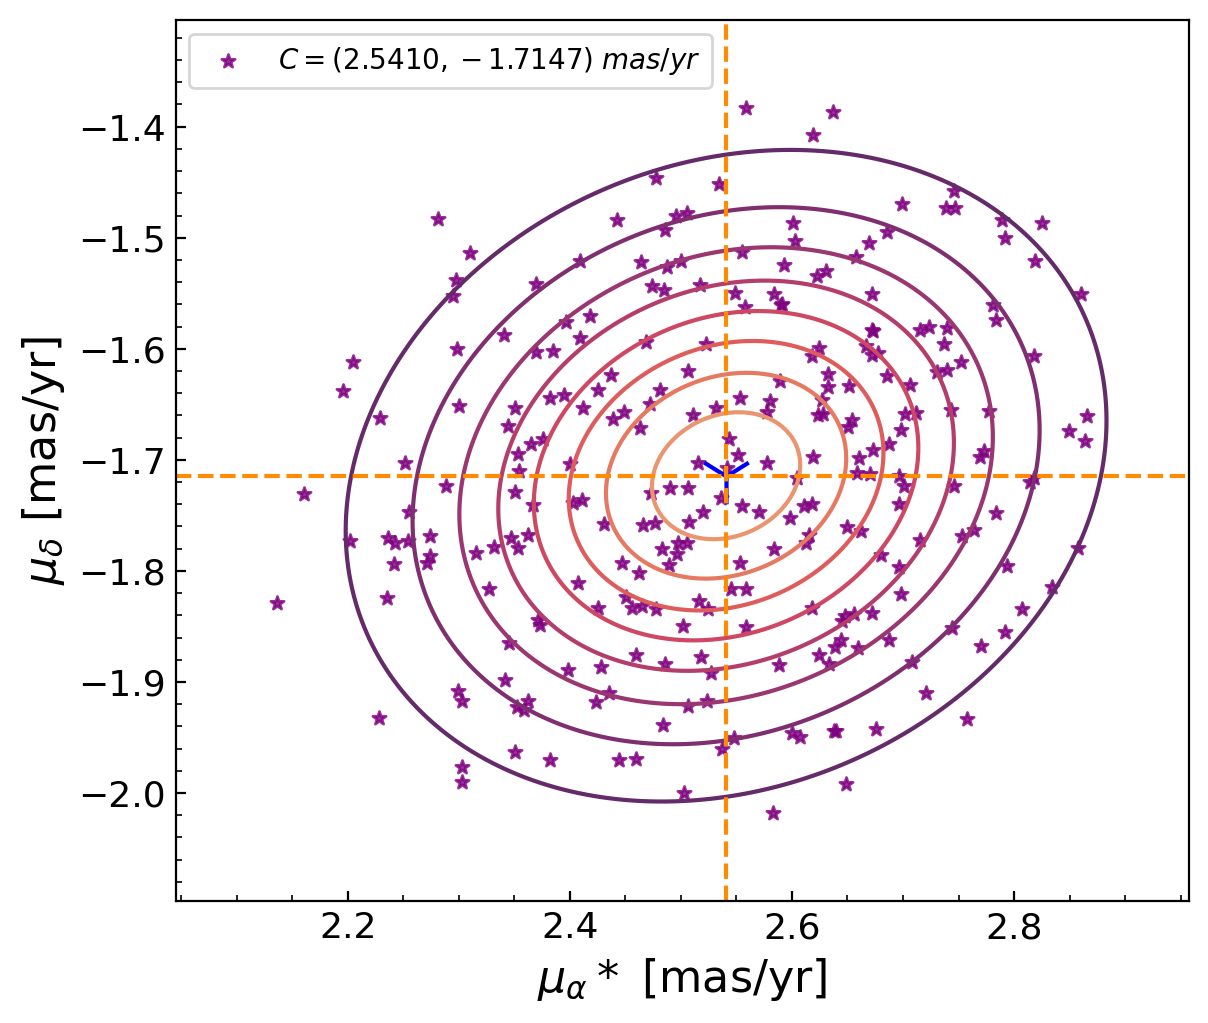

In [233]:
pm_results, pm_dist, pmprob = pm_determination(data_gaia[cluster],return_pmdist=True,return_pmprob=True,savefig='Tex_File/Figures/',prob_number=[60],paper_single=True)

In [267]:
pm_results

[{'probability': 0.6,
  'mu_RA_mean': 2.5407044346646415,
  'mu_Dec_mean': -1.714286737039385,
  'sigma_RA_mean': 0.16474288321817393,
  'sigma_Dec_mean': 0.141100202095548,
  'corr_mean': 0.16931292757985483,
  'mu_RA_std': 0.010132737458287324,
  'mu_Dec_std': 0.00865250473783671,
  'sigma_RA_std': 0.0071191305776495805,
  'sigma_Dec_std': 0.006156749331142936,
  'corr_std': 0.05928323866060946}]

## Projected velocity

In [31]:
data_gaia['projected_velocity'] = np.sqrt(data_gaia['pmra']**2 + data_gaia['pmdec']**2)

In [32]:
def velocity_model(data, return_trace=False, progressbar=False):
    # Assuming projected_velocity is in mas/yr, calculate prior mean
    prior_mu_v = np.mean(data['projected_velocity'])

    with pm.Model() as vel_model:
        # Hyperprior for the mean velocity of the star cluster
        mu_v = pm.Normal("mu_v", mu=prior_mu_v, sigma=10)
        
        # Standard deviation for the velocity
        std_v = pm.Uniform("std_v", lower=0, upper=50)
        
        # Likelihood for the observed velocity
        pm.Normal("observed_velocity", mu=mu_v, sigma=std_v, observed=data["projected_velocity"])

    # Iterative sampling process
    max_rhat = 2.0
    target_accept = 0.8
    tune = 4000

    while max_rhat > 1.0:
        with vel_model:
            trace = pm_jax.sample_numpyro_nuts(draws=10000, tune=tune, target_accept=target_accept, progressbar=progressbar)
            
        rhat_vals = az.rhat(trace)
        # Extract the maximum rhat value
        max_rhat = round(np.max(rhat_vals.to_array().values),2)
        if target_accept <= 0.9999999:
            target_accept += 0.05
        tune += 2000

    results = {
        'mu_v_mean': trace.posterior['mu_v'].mean().item(),
        'std_v_mean': trace.posterior['std_v'].mean().item(),
        'mu_v_std': trace.posterior['mu_v'].std().item(),
        'std_v_std': trace.posterior['std_v'].std().item(),
    }

    if return_trace:
        results['trace'] = trace

    return results


In [33]:
def velocity_determination(data, prob_thresholds=[50, 60, 70, 80], return_trace=False, progressbar=False,savefig=None,paper_single=False):
    prob_thresholds = np.array(prob_thresholds) / 100
    num_thresholds = len(prob_thresholds)
    
    # Determine the layout of subplots based on the number of thresholds
    if num_thresholds <= 2:
        nrows, ncols = 1, num_thresholds
    else:
        nrows = 2
        ncols = int(np.ceil(num_thresholds / 2))
    
    fig, axs = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), constrained_layout=True)
    if num_thresholds == 1:
        axs = np.array([axs])  # Ensure axs is iterable even for a single subplot
    
    results = []

    for i, prob_threshold in enumerate(prob_thresholds):
        print(f"Processing for probability threshold: {prob_threshold * 100}%")
        
        # Filter data based on probability threshold
        filtered_data = data[data['probability'] >= prob_threshold]
    
        # Call velocity model with filtered data (Assuming velocity_model is defined elsewhere)
        model_results = velocity_model(filtered_data, return_trace=return_trace, progressbar=progressbar)
    
        # Store results
        results.append({
            'probability': prob_threshold,
            'model_results': model_results
        })
        
        # Select the current axis for plotting
        ax = axs.flatten()[i]

        # Histogram of observed velocities
        _, bins, _ = ax.hist(filtered_data['projected_velocity'], bins='auto', color='orange', alpha=0.7, histtype='step', label='Observed Velocity')

        # Mean velocity line and label
        mean_velocity = model_results['mu_v_mean']
        std_velocity = model_results['std_v_mean']
        mean_std = model_results['mu_v_std']
        ax.axvline(mean_velocity, color='blue', linestyle='--', label=f'Mean Velocity: {mean_velocity:.3f} ± {mean_std:.3f} km/s')
        lim_y_ax = ax.get_ylim()
        ax.fill_betweenx(y=[lim_y_ax[0], 1.5*lim_y_ax[1]], x1=mean_velocity - mean_std, x2=mean_velocity + mean_std, color='blue', alpha=0.05,label='Standard desviation')
        bin_width = np.diff(bins)[0]
        scaling_factor = len(filtered_data) * bin_width
        x = np.linspace(mean_velocity - 3*std_velocity, mean_velocity + 3*std_velocity, 100)
        p = norm.pdf(x, mean_velocity, std_velocity) * scaling_factor
        ax.plot(x, p, label='Velocity Model')
        ax.set_xlabel('Projected Velocity [$\mathrm{mas~yr}^{-1}$]',fontsize=14)
        ax.set_ylabel('Counts',fontsize=14)
        if not paper_single:
            ax.set_title(f'Prob Threshold: {prob_threshold * 100:.0f}%')
        ax.legend()

    # Adjust layout if fewer plots than slots
    for j in range(i + 1, nrows * ncols):
        fig.delaxes(axs.flatten()[j])

    if savefig:
        if paper_single:
            fig.savefig(f"{savefig}projected_velocity_paper.pdf",bbox_inches='tight')
        else:
            fig.savefig(f"{savefig}projected_velocity.pdf",bbox_inches='tight')
    plt.show()
    return results


Compiling...


Processing for probability threshold: 70.0%


Compilation time = 0:00:00.363600
Sampling...
Sampling time = 0:00:00.979494
Transforming variables...
Transformation time = 0:00:00.045840


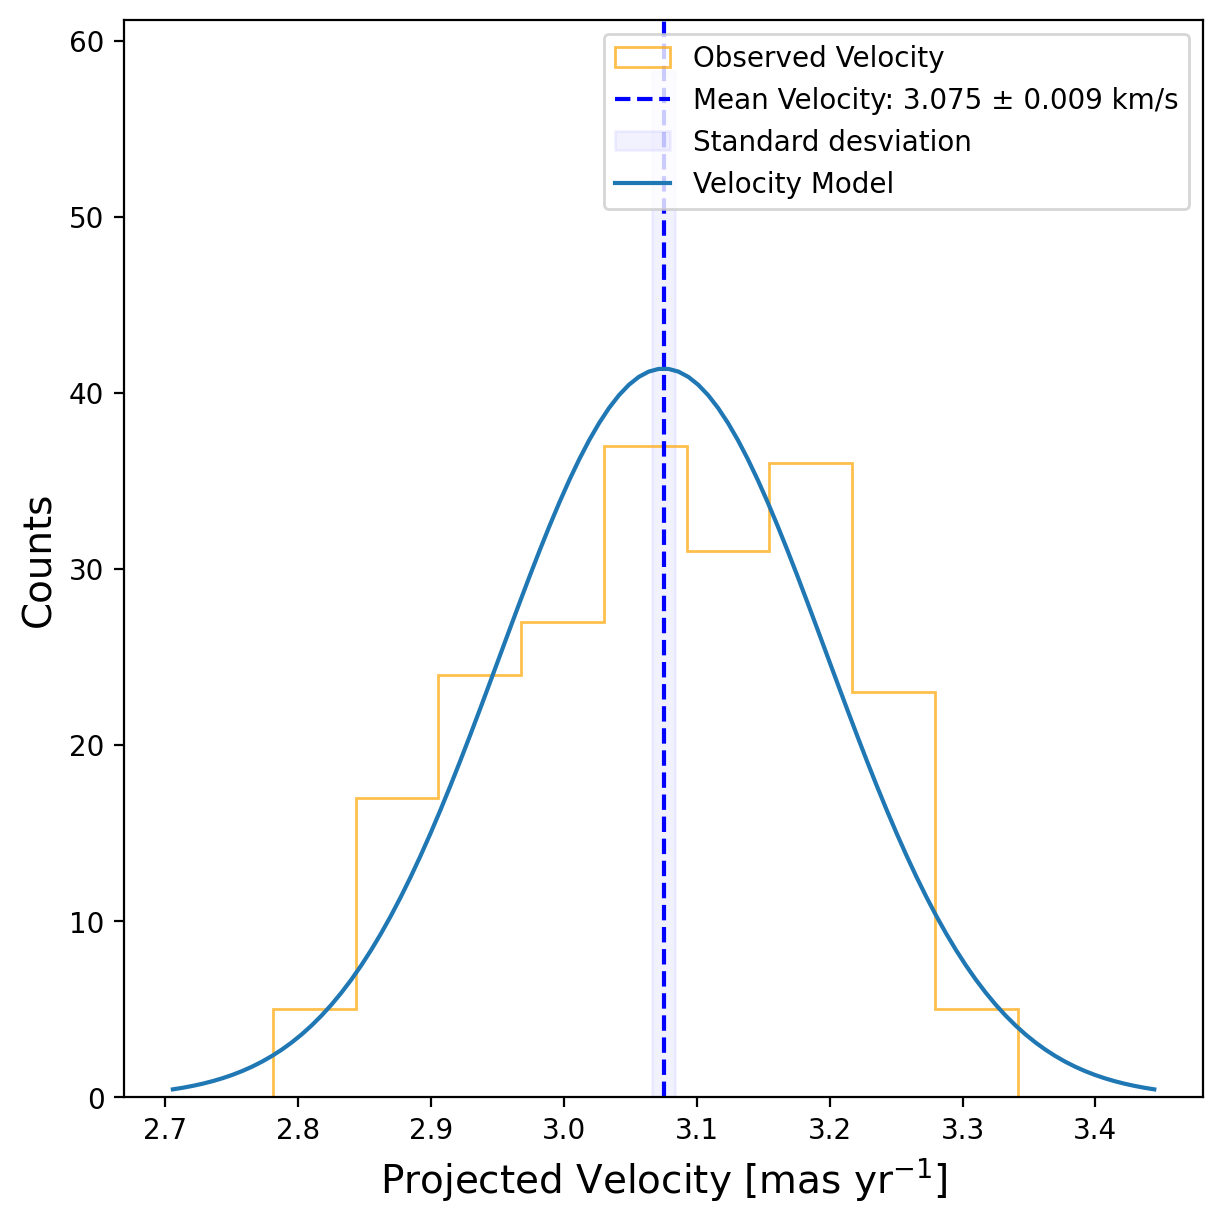

In [34]:
results_vp = velocity_determination(data_gaia[cluster], return_trace=True,savefig='Tex_File/Figures/',prob_thresholds=[70],paper_single=True)

## Center determination

In [28]:
def center_determination(data, grid_ra=None, grid_dec=None, weights=None, return_density=False, return_grids=False, return_bestparams=False):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        ra = data['ra']
        dec = data['dec']
        ra_err = data['ra_error']
        dec_err = data['dec_error']
        ra_dec = np.vstack([ra, dec]).T
        min_bandwidth = np.mean([np.mean(ra_err).to(u.deg).value, np.mean(dec_err).to(u.deg).value])
        params = {
            'bandwidth': np.linspace(min_bandwidth, 0.7, 500),
            'kernel': ['gaussian', 'epanechnikov', 'exponential', 'linear']
        }
        grid = GridSearchCV(KernelDensity(), params, cv=5, n_jobs=-1)
        if weights is not None:
            grid.fit(ra_dec, sample_weight=weights)
        else:
            grid.fit(ra_dec)
        kde = grid.best_estimator_
        if grid_ra is None or grid_dec is None:
            added_space_ra = (np.max(ra) - np.min(ra)) / 6
            added_space_dec = (np.max(dec) - np.min(dec)) / 5
            grid_ra, grid_dec = np.meshgrid(
                np.linspace(np.min(ra) - added_space_ra, np.max(ra) + added_space_ra, 700),
                np.linspace(np.min(dec) - added_space_dec, np.max(dec) + added_space_dec, 700)
            )

        grid_points = np.vstack([grid_ra.ravel(), grid_dec.ravel()]).T
        log_density = kde.score_samples(grid_points)
        density = np.exp(log_density).reshape(grid_ra.shape)
        max_density_idx = np.argmax(density)
        max_density_coords = (grid_ra.ravel()[max_density_idx], grid_dec.ravel()[max_density_idx])
        best_bandwidth = grid.best_params_['bandwidth']*u.deg
        # Assuming the bandwidth represents an additional "smoothing" uncertainty, 
        
        # Calculate the mean errors (assuming errors are standard deviations)
        ra_mean_error = np.mean(data['ra_error'])
        dec_mean_error = np.mean(data['dec_error'])
        
        # Incorporate the bandwidth as an additional error term linearly rather than quadratically
        ra_total_error = ra_mean_error + best_bandwidth
        dec_total_error = dec_mean_error + best_bandwidth
        
        # Now, if you want to express this in terms of variance for further calculations,
        # you would square the total errors
        ra_variance = ra_total_error**2
        dec_variance = dec_total_error**2
        
        # Standard error of the mean (SEM) calculation remains the same
        ra_sem = np.sqrt(ra_variance) / np.sqrt(len(data['ra_error']))
        dec_sem = np.sqrt(dec_variance) / np.sqrt(len(data['dec_error']))

        results = {'center_coords': max_density_coords,
                  'center_coords_error' : (ra_sem.to(u.deg), dec_sem.to(u.deg))}
        if return_density:
            results['density'] = density
        if return_grids:
            results['grid_ra'] = grid_ra
            results['grid_dec'] = grid_dec
        if return_bestparams:
            results['best_params'] = grid.best_params_
            
        return results

In [242]:
def graph_center_determination(data, projection=None, savefig=None, prob_number=[50, 60, 70, 80], weighted=False, weight_array=None, only_weight=False,paper_single=False,weight_prob=60,distance_scale=None):
    # Ensure prob_number is a list or None
    if prob_number is not None:
        prob_number = np.array(prob_number) / 100.0

    # Determine the number of columns for the subplot based on the inputs
    num_cols = len(prob_number) if prob_number is not None else 0
    if weighted:
        num_cols += 1  # Add an extra column for weighted KDE if needed

    # Adjust num_cols to ensure there's at least one plot
    num_cols = max(1, num_cols)

    subplot_kw = {'projection': projection} if projection else {}
    centers = []
    best_params_list = []

    # Calculate the grid for KDE
    total_ra = data['ra']
    total_dec = data['dec']
    added_space_ra = (np.max(total_ra) - np.min(total_ra)) / 8
    added_space_dec = (np.max(total_dec) - np.min(total_dec)) / 8
    grid_ra, grid_dec = np.meshgrid(
        np.linspace(np.min(total_ra) - added_space_ra, np.max(total_ra) + added_space_ra, 700),
        np.linspace(np.min(total_dec) - added_space_dec, np.max(total_dec) + added_space_dec, 700)
    )

    # Setup the figure and axes for plotting
    fig_kde, ax_kde = plt.subplots(1, num_cols, figsize=(7,5), subplot_kw=subplot_kw, constrained_layout=True)
    if num_cols == 1:
        ax_kde = [ax_kde]  # Ensure ax_kde is always a list for consistency
    
    ax_index = 0  # Index to track the current axis for plotting

    # Unweighted KDE calculations for each probability threshold
    if prob_number is not None:
        for i, ax in zip(prob_number, ax_kde[:len(prob_number)]):
            selected_data = data[data['probability'] >= i]
            # Perform center determination and plotting...
            # (Insert your center_determination function and plotting code here)
            print(f"{i * 100}% probability members")
            ax_index += 1
            # Filter the data based on the probability threshold
            selected_data = data[data['probability'] >= i]
            results = center_determination(selected_data, grid_ra, grid_dec, return_density=True, return_bestparams=True)
            max_density_coords = results['center_coords']
            density = results['density']
            best_params = results.get('best_params', {})
            levels = levels = np.sort(np.concatenate([np.linspace(density.min(), density.max()/5, 6),np.linspace(density.max()/5, density.max(), 4)[1:]]))
            lim_coord_min = SkyCoord(ra=grid_ra.min(), dec=grid_dec.min(), frame='icrs', unit='deg')
            lim_coord_max = SkyCoord(ra=grid_ra.max(), dec=grid_dec.max(), frame='icrs', unit='deg')
            if projection is not None:
                ax.scatter(selected_data['ra'], selected_data['dec'], color='yellow', s=30, marker='*', transform=ax.get_transform('world'))
                ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue', transform=ax.get_transform('world'))
                ax.contour(grid_ra, grid_dec, density, levels=levels, cmap='viridis',transform=ax.get_transform('world'))
                coord = SkyCoord(ra=max_density_coords[0], dec=max_density_coords[1], frame='icrs', unit='deg')
                pixels = ax.wcs.world_to_pixel(coord)
                ax.axvline(pixels[0], color='lavender', ls='--')
                ax.axhline(pixels[1], color='lavender', ls='--')
                ax.coords.grid(True, color='gray', linestyle='dotted')
                ax.coords[0].set_major_formatter('d.ddd')
                ax.coords[1].set_major_formatter('d.ddd')
                pixels_min,pixels_max = ax.wcs.world_to_pixel(lim_coord_min),ax.wcs.world_to_pixel(lim_coord_max)
                ax.set_ylim(pixels_min[0],pixels_max[0])
                ax.set_xlim(pixels_min[1],pixels_max[1])
                if distance_scale != None:
                    gc_distance = distance_scale
                    scalebar_length = 10 * u.pc
                    scalebar_angle = (scalebar_length / gc_distance).to(u.deg, equivalencies=u.dimensionless_angles())
                    add_scalebar(ax, scalebar_angle, label="10 pc", color="white")
            if projection is None:
                ax.scatter(selected_data['ra'], selected_data['dec'], color='yellow', s=30, marker='*')
                ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue')
            ax.set_xlabel(r'$\alpha$ [{}]'.format(data['ra'].unit))
            ax.set_ylabel(r'$\delta$ [{}]'.format(data['dec'].unit))
            ax.set_title(f'{i * 100}% probability members')
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
            ax.tick_params(axis='both', which='both', direction='in')
            ax.set_aspect('equal')
            ax.set_facecolor('black')
            legend_label = r'$C = ({:.4f},{:.4f})\;{}$'.format(max_density_coords[0].value, max_density_coords[1].value, u.deg)
            ax.legend([legend_label], loc='best', shadow=True, framealpha=0.8)
            centers.append([max_density_coords,results['center_coords_error']])
            best_params_list.append(best_params)

    # Weighted KDE calculation
    if weighted and weight_array is not None:
        ax = ax_kde[ax_index] if ax_index < len(ax_kde) else ax_kde[-1]
        print("Weighted KDE")
        selected_data = data[data['probability'] >= weight_prob/100]
        results = center_determination(selected_data, grid_ra, grid_dec, weights=weight_array, return_density=True, return_bestparams=True)
        max_density_coords = results['center_coords']
        density = results['density']
        best_params = results.get('best_params', {})
        levels = np.sort(np.concatenate([np.linspace(density.min(), density.max()/5, 6),np.linspace(density.max()/5, density.max(), 4)[1:]]))
        lim_coord_min = SkyCoord(ra=grid_ra.min(), dec=grid_dec.min(), frame='icrs', unit='deg')
        lim_coord_max = SkyCoord(ra=grid_ra.max(), dec=grid_dec.max(), frame='icrs', unit='deg')
        if projection is not None:
            sc = ax.scatter(selected_data['ra'], selected_data['dec'], s=25, marker='.', transform=ax.get_transform('world'),c='yellow',alpha=0.95)
            #fig_kde.colorbar(sc).set_label('Probability')
            ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue', transform=ax.get_transform('world'))
            ax.contour(grid_ra, grid_dec, density, levels=levels, cmap='viridis',transform=ax.get_transform('world'))
            coord = SkyCoord(ra=max_density_coords[0], dec=max_density_coords[1], frame='icrs', unit='deg')
            pixels = ax.wcs.world_to_pixel(coord)
            ax.axvline(pixels[0], color='lavender', ls='--')
            ax.axhline(pixels[1], color='lavender', ls='--')
            ax.coords.grid(True, color='gray', linestyle='dotted')
            ax.coords[0].set_major_formatter('d.dd')
            ax.coords[1].set_major_formatter('d.dd')
            pixels_min,pixels_max = ax.wcs.world_to_pixel(lim_coord_min),ax.wcs.world_to_pixel(lim_coord_max)
            ax.set_ylim(pixels_min[0],pixels_max[0])
            ax.set_xlim(pixels_min[1],pixels_max[1])
            if distance_scale != None:
                gc_distance = distance_scale
                scalebar_length = 5 * u.pc
                scalebar_angle = (scalebar_length / gc_distance).to(u.deg, equivalencies=u.dimensionless_angles())
                add_scalebar(ax, scalebar_angle, label="5 pc", color="white")
        if projection is None:
            ax.scatter(selected_data['ra'], selected_data['dec'], color='yellow', s=30, marker='*')
            ax.scatter(max_density_coords[0], max_density_coords[1], marker='1', s=400, color='blue')
        ax.set_xlabel(r'$\alpha$ [{}]'.format(data['ra'].unit),fontsize=16)
        ax.set_ylabel(r'$\delta$ [{}]'.format(data['dec'].unit),fontsize=16)
        if not only_weight:
            ax.set_title(f'Weighted')
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in',labelsize=13)
        ax.set_aspect('equal')
        ax.set_facecolor('black')
        legend_label = r'$C = ({:.4f},{:.4f})\;{}$'.format(max_density_coords[0].value, max_density_coords[1].value, u.deg)
        ax.legend([legend_label], loc='best', shadow=True, framealpha=0.8,fontsize=10)
        centers.append([max_density_coords,results['center_coords_error']])
        best_params_list.append(best_params)
    # Saving the figure
    if savefig:
        if paper_single:
            plt.savefig(f"{savefig}center_determination_paper.pdf",bbox_inches='tight')
        else:
            plt.savefig(f"{savefig}center_determination.pdf",bbox_inches='tight')
    plt.show()
    return centers, best_params_list

Weighted KDE


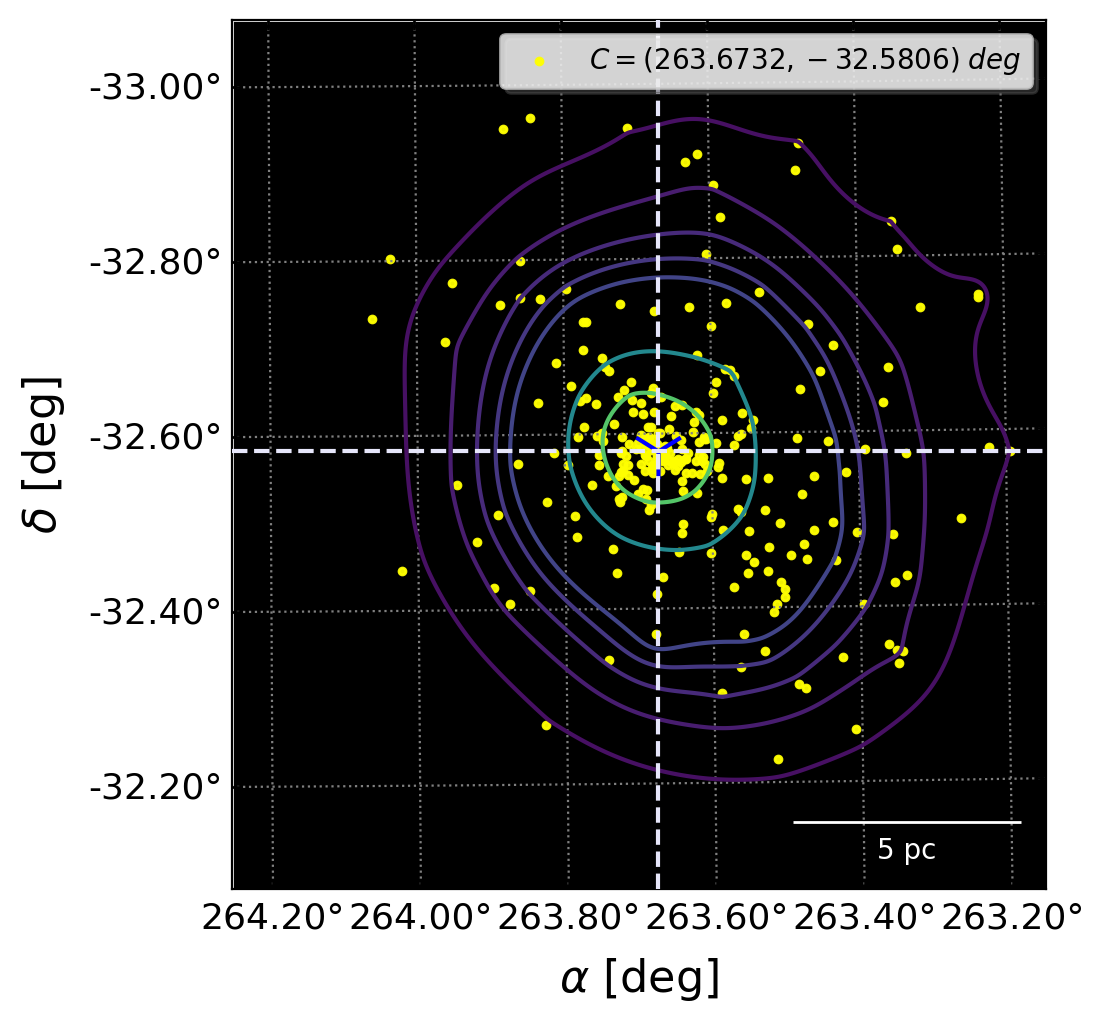

In [243]:
centers, params_list = graph_center_determination(data=data_gaia[cluster],projection=wcs,weighted=True,weight_array=pmprob[0],weight_prob=60,prob_number=None
                                                  ,savefig='Tex_File/Figures/',only_weight=True,paper_single=True,distance_scale=parallax_results['mu_r_mean'][0]*u.kpc)

In [51]:
SkyCoord(ra=centers[0][0][0],dec=centers[0][0][1]).galactic

<SkyCoord (Galactic): (l, b) in deg
    (355.66578458, 0.05264228)>

## Radial Density Profile (cite Andreas H. W. Kupper 2010)

3P King Porfile

$
f(R)  = k \left[\dfrac{1}{\sqrt{1+\left(\frac{R}{R_c}\right)^2}} - \dfrac{1}{\sqrt{1+\left(\frac{R_t}{R_c}\right)^2}}\right]^2+b
$

and 2P King Profile

$
f(R) = \dfrac{k}{1+\left(\frac{R}{R_c}\right)^2}+b
$

In [35]:
def density_annulus_calculator_width(data, center, width, return_radius_gen=False):
    d_center = (angular_separation(data['ra'], data['dec'], center.ra, center.dec)).to(u.arcmin)
    # Generate radii
    radius_gen = np.unique(np.concatenate([np.arange(0, np.max(d_center.value) / 3, 0.5 * width), 
    np.arange(np.max(d_center.value) / 3, 2 * np.max(d_center.value) / 3, width),
    np.arange(2 * np.max(d_center.value) / 3, 1.1 * np.max(d_center.value), 2 * width)
]))
    # Initialize lists to store density and density errors for annulus and circles
    density_annulus = []
    density_errors_annulus = []
    valid_radii = []  # List to store radii corresponding to non-zero densities

    # Calculate density using annulus
    for i in range(len(radius_gen) - 1):
        inner_radius = radius_gen[i]
        outer_radius = radius_gen[i + 1]
        criteria = (d_center >= inner_radius * u.arcmin) & (d_center < outer_radius * u.arcmin)
        counts = len(d_center[criteria])
        annulus_area = np.pi * (outer_radius ** 2 - inner_radius ** 2)
        if counts > 0:  # Only consider annuli with non-zero counts
            density_r_annulus = counts / annulus_area
            density_error_r_annulus = np.sqrt(counts) / annulus_area
            density_annulus.append(density_r_annulus)
            density_errors_annulus.append(density_error_r_annulus)
            valid_radii.append((inner_radius + outer_radius) / 2)  # Midpoint of the annulus

    results = {
        'density_annulus': density_annulus,
        'density_errors_annulus': density_errors_annulus,
        'd_center' : d_center
    }
    if return_radius_gen:
        results['radius_gen'] = valid_radii  # Return only the radii for non-zero densities
    return results

In [36]:
def density_annulus_calculator_equip(data, center, return_radius_gen=False):
    # Calculate the angular separation of each star from the cluster center
    d_center = angular_separation(data['ra'], data['dec'], center.ra, center.dec).to(u.arcmin)
    
    # Determine the number of bins using the equiprobable bin rule
    n = len(data)
    k = int(2 *n**(2/5))  # Number of bins
    
    # Calculate bin edges such that each bin has approximately equal number of stars
    sorted_d_center = np.sort(d_center.value)
    bin_edges = np.interp(np.linspace(0, len(sorted_d_center), k+1),
                          np.arange(len(sorted_d_center)),
                          sorted_d_center)
    # Initialize lists to store density and density errors for each annulus
    density_annulus = []
    density_errors_annulus = []
    valid_radii = []  # To store the average radius of each annulus
    
    # Calculate density for each annulus
    for i in range(len(bin_edges) - 1):
        inner_radius = bin_edges[i]
        outer_radius = bin_edges[i + 1]
        
        criteria = (d_center.value >= inner_radius) & (d_center.value < outer_radius)
        counts = np.sum(criteria)
        
        annulus_area = np.pi * (outer_radius**2 - inner_radius**2)  # Area of the annulus in arcmin^2
        
        density_r_annulus = counts / annulus_area
        density_error_r_annulus = np.sqrt(counts) / annulus_area
        
        density_annulus.append(density_r_annulus)
        density_errors_annulus.append(density_error_r_annulus)
        valid_radii.append((inner_radius + outer_radius) / 2)  # Midpoint radius of the annulus
    
    results = {
        'density_annulus': density_annulus,
        'density_errors_annulus': density_errors_annulus,
        'd_center' : d_center
    }
    
    if return_radius_gen:
        results['radius_gen'] = valid_radii
    
    return results


### Priors

#### Galactic mass

In [37]:
def calculate_galactic_mass(galactic_radius):
    galactic_radius = ensure_units(galactic_radius,u.pc)
    galactic_mass = 2E8*(galactic_radius/(30*u.pc))**1.2*u.Msun
    return galactic_mass.to(u.Msun)

#### Tidal radius considering the potential gravitatory

In [38]:
def tidal_radius_prior(cluster_mass,galactic_radius,galactic_mass=None,type='angular',distance=None,return_galactic_mass=False,data=None):
    if galactic_mass is None:
        galactic_mass = calculate_galactic_mass(galactic_radius)
    if cluster_mass is None:
        cluster_mass = estimate_cluster_mass(data,distance)
    cluster_mass = ensure_units(cluster_mass,u.Msun)
    galactic_mass = ensure_units(galactic_mass,u.Msun)
    galactic_radius = ensure_units(galactic_radius,u.kpc)
    tidal_radius = (cluster_mass/(2*galactic_mass))**(1/3)*galactic_radius
    results = {}
    if type == 'angular':
        results['angular_size'] = angular_size(tidal_radius.to(u.pc),distance)
    if type == 'linear':
        results['linear_size'] = tidal_radius.to(u.pc)
    if type == 'both':
        results['linear_size'] = tidal_radius.to(u.pc)
        results['angular_size'] = angular_size(tidal_radius.to(u.pc),distance)
    if return_galactic_mass:
        results['galactic_mass'] = galactic_mass
    return results

#### Hill radius

In [39]:
def calculate_absolute_magnitude(apparent_mag, distance):
    # Convert distance from parsec to pc if it's not in the correct unit
    distance = distance.to(u.pc) if hasattr(distance, 'unit') else distance * u.pc
    # Calculate absolute magnitude
    return apparent_mag - 5 * (np.log10(distance.value) - 1)*u.mag

def estimate_luminosity(absolute_mag):
    # Calculate luminosity based on absolute magnitude
    return 10**((4.74 - absolute_mag.value) / 2.5)

def estimate_mass_from_luminosity(luminosity):
    # Invert the mass-luminosity relation
    return luminosity**(1/3.5)*u.Msun

def estimate_cluster_mass(data,distance):
    # Calculate absolute magnitude for each star
    data['G_abs'] = calculate_absolute_magnitude(data['Gmag'], distance)
    
    # Calculate luminosity for each star
    data['luminosity'] = estimate_luminosity(data['G_abs'])
    
    # Estimate mass for each star
    data['mass'] = estimate_mass_from_luminosity(data['luminosity'])

    # Sum the masses to get total cluster mass
    total_mass = np.sum(data['mass'])
    return total_mass

def calculate_galactocentric_distance(ra, dec, distance):
    # Convert RA and Dec to Galactic coordinates
    sky_coord = SkyCoord(ra=ra, dec=dec, frame='icrs')
    galactic_coord = sky_coord.transform_to('galactic')
    distance = ensure_units(distance,u.kpc)
    # Constants
    R_sun = 8.3 * u.kpc
    # Sun's distance to Galactic center

    # Extract Galactic coordinates
    l = galactic_coord.l.rad  # Galactic longitude in radians
    b = galactic_coord.b.rad  # Galactic latitude in radians

    # Calculate galactocentric distance
    d_gc = np.sqrt(R_sun**2 + distance**2 - 2 * R_sun * distance * np.cos(l) * np.cos(b))

    return d_gc

In [40]:
def calculate_hill_radius(distance,center=None,galactocentric_distance=None,galactic_mass=None,cluster_mass=None,data=None,return_galdist=False,return_cluster_mass=False,return_linear_size=False,return_galactic_mass=False):
    distance = ensure_units(distance,u.kpc)
    if galactocentric_distance is None:
        galactocentric_distance = calculate_galactocentric_distance(center[0],center[1], distance)
    if galactic_mass is None:
        galactic_mass = calculate_galactic_mass(galactocentric_distance)
    if cluster_mass is None:
        cluster_mass = estimate_cluster_mass(data,distance)
    hill_radius = (galactocentric_distance * (cluster_mass / (3 * galactic_mass))**(1/3)).to(u.pc)
    hill_angular = (hill_radius / distance).to(u.deg, equivalencies=u.dimensionless_angles())
    results = {}
    results['angular_size'] = hill_angular.to(u.arcmin)
    if return_galdist:
        results['galactocentric_distance'] = galactocentric_distance
    if return_cluster_mass:
        results['cluster_mass'] = cluster_mass
    if return_linear_size:
        results['linear_size'] = hill_radius
    if return_galactic_mass:
        results['galactic_mass'] = galactic_mass
    return results

#### Gravitational bound radius

In [41]:
def grav_bound_radius(M_total, A=15.3*u.kpc**-1*u.km/u.s, A_err=0.4*u.kpc**-1*u.km/u.s, B=-11.9*u.kpc**-1*u.km/u.s, B_err=0.4*u.kpc**-1*u.km/u.s,distance=None):
    """
    Calculate the tidal radius of a star cluster.

    Parameters:
    - M_total: Total mass of the cluster members in solar masses.
    - A: Oort constant A in kpc^-1.
    - A_err: Error in Oort constant A.
    - B: Oort constant B in kpc^-1.
    - B_err: Error in Oort constant B.

    Returns:
    - rt: Tidal radius in parsecs.
    - rt_err: Error in tidal radius.
    """

    # Gravitational constant 

    A_B_squared = (A - B)**2
    A_B_squared_err = 2 * np.abs(A - B) * np.sqrt(A_err**2 + B_err**2)
    # Calculate the tidal radius
    radius = (((G * M_total) / (2 * A_B_squared))**(1/3)).to(u.pc)
    
    # Propagate error for tidal radius
    radius_err = radius * np.sqrt((4 * A_B_squared_err / A_B_squared)**2)
    results = {}
    if distance is None:
        results['linear_radius'] = radius.to(u.pc)
        results['linear_radius_err'] = radius_err.to(u.pc)
    if distance is not None:
        results['angular_radius'] = angular_size(radius,distance)
        results['angular_radius_err'] = angular_size(radius_err,distance)
    return results

### Models

In [42]:
def calculate_half_light_radius(Gmag, distance_to_center):
    """
    Calculate the half-light radius for a cluster given the G-band magnitudes
    and distances of stars from the cluster center.
    
    Parameters:
    - Gmag: numpy.ndarray, apparent magnitudes of the stars in the G band.
    - distance_to_center: numpy.ndarray, distances of each star from the cluster center.
    
    Returns:
    - R_h: float, the half-light radius of the cluster (in the same units as distance_to_center).
    """
    if hasattr(Gmag, 'unit'):
        Gmag = Gmag.value  # Assuming Gmag is an Astropy Quantity with unnecessary units
    # Convert Gmag to relative luminosities
    L = 10 ** (-0.4 * (Gmag - np.min(Gmag)))
    
    # Sort stars by their distance from the cluster center
    indices_sorted_by_distance = np.argsort(distance_to_center)
    sorted_distances = distance_to_center[indices_sorted_by_distance]
    sorted_luminosities = L[indices_sorted_by_distance]
    
    # Compute cumulative luminosity
    cumulative_luminosity = np.cumsum(sorted_luminosities)
    
    # Total luminosity is the last value in the cumulative sum
    total_luminosity = cumulative_luminosity[-1]
    half_total_luminosity = total_luminosity / 2
    
    # Find the smallest distance at which the cumulative luminosity exceeds half of the total luminosity
    half_light_radius_index = np.argmax(cumulative_luminosity >= half_total_luminosity)
    R_h = sorted_distances[half_light_radius_index]
    
    return R_h


In [59]:
def RDP_bayesian(density_annulus, radius_gen, return_trace=False,progressbar=False,d_center=None,priors=False,priors_parameters=None,return_priors=None):
    with pm.Model() as king_model:
        sigma = pm.HalfNormal('sigma', sigma=5)
        b = pm.Uniform('b', lower=0, upper=2*np.min(density_annulus))
        k = pm.Uniform('k', lower=b, upper=2*np.max(density_annulus))
        if d_center is None:
            R_c = pm.Uniform('R_c',lower=0,upper=0.8*np.max(radius_gen).value)
            R_t = pm.Uniform('R_t', lower=R_c, upper=1.5*np.max(radius_gen))  # Ensure R_t > R_c
        if (d_center is not None) and (priors == False):
            R_c = pm.Uniform('R_c',lower=0,upper=0.8*np.max(d_center).value)
            R_t = pm.Uniform('R_t', lower=R_c, upper=1.5*np.max(d_center))  # Ensure R_t > R_c
        if (d_center is not None) and (priors == True):
            cluster_mass = priors_parameters['cluster_mass']
            galactic_radius = priors_parameters['galactic_radius']
            distance = priors_parameters['distance']
            tidal_pot_results = tidal_radius_prior(cluster_mass,galactic_radius,galactic_mass=None,type='angular',distance=distance,return_galactic_mass=True)
            tidal_potential = tidal_pot_results['angular_size']
            galactic_mass= tidal_pot_results['galactic_mass']
            hill_radius = calculate_hill_radius(galactocentric_distance=galactic_radius,distance=distance,galactic_mass=galactic_mass,cluster_mass=cluster_mass,data=None)['angular_size']
            gravitational_bound_radius = grav_bound_radius(cluster_mass,distance=distance)['angular_radius']
            max_tidal = np.max([tidal_potential.value,hill_radius.value,gravitational_bound_radius.value])
            R_c = pm.Uniform('R_c',lower=0,upper=0.8*np.max(d_center).value)
            R_t = pm.Uniform('R_t', lower=R_c, upper=1.5*max_tidal)  # Ensure R_t > R_c
        r = pm.ConstantData('radius', radius_gen)
        density_points = pm.ConstantData('density', density_annulus)
        king = pm.Deterministic('king', pm.math.switch(r < R_t,
                                                       k * ((1 / pm.math.sqrt(1 + (r / R_c) ** 2)) - (1 / pm.math.sqrt(1 + (R_t / R_c) ** 2))) ** 2 + b,
                                                       b))
        obs_density = pm.Normal('obs_density', mu=king, sigma=sigma, observed=density_points)
    rhat = [2, 2]
    target_accept = 0.9
    tune = 4000
    while any(x > 1 for x in rhat):
        with king_model:
            king_trace = pm_jax.sample_numpyro_nuts(draws=10000, tune=tune, target_accept=target_accept, random_seed=np.random.randint(1, 100000),progressbar=progressbar)
            rhat = az.summary(king_trace, var_names=["sigma", "k", "R_c", "R_t", "b"])['r_hat'].iloc[:]
        if target_accept <= 0.9999999:
            target_accept += 0.05
        tune += 2000
    k_mean = king_trace.posterior['k'].median().item()
    b_mean = king_trace.posterior['b'].median().item()
    R_c_mean = king_trace.posterior['R_c'].median().item()
    R_t_mean = king_trace.posterior['R_t'].median().item()
    k_std = king_trace.posterior['k'].std().item()
    b_std = king_trace.posterior['b'].std().item()
    R_c_std = king_trace.posterior['R_c'].std().item()
    R_t_std = king_trace.posterior['R_t'].std().item()
    king_std = king_trace.posterior['sigma'].median().item()
    bg_level = (b_mean + 3*b_std)
    C = np.log(R_t_mean/R_c_mean)
    d_c = 1 + k_mean/bg_level
    r_lim = R_c_mean*np.sqrt(k_mean/(3*b_std)-1)
    results = {
        'k_mean': k_mean,
        'b_mean': b_mean,
        'R_c_mean': R_c_mean*u.arcmin,
        'R_t_mean': R_t_mean*u.arcmin,
        'k_std': k_std,
        'b_std': b_std,
        'bg_level' : bg_level,
        'R_c_std': R_c_std,
        'R_t_std': R_t_std,
        'king_std': king_std,
        'C' : C,
        'd_c' : d_c,
        'r_lim': r_lim
    }
    if return_trace is True:
        results['king_trace'] = king_trace
    if return_priors is True:
        priors_results = {
            'cluster_mass' : cluster_mass,
            'galactic_radius' : galactic_radius,
            'galactic_mass' : galactic_mass,
            'tidal_pot_radius' : tidal_potential,
            'hill_radius' : hill_radius,
            'gravitational_bound_radius' : gravitational_bound_radius,
            'far_member' : np.max(d_center.value),
            'max_tidal' : max_tidal}
        results['priors_results'] = priors_results
    return results

In [44]:
def RDP_bayesian_log_space(density_annulus, radius_gen, return_trace=False, progressbar=False, d_center=None):
    with pm.Model() as king_model:
        # Use a log transformation for parameters that span several orders of magnitude
        log_sigma = pm.Normal('log_sigma', mu=np.log(5), sigma=np.log(1.0000000001))
        sigma = pm.Deterministic('sigma', pm.math.exp(log_sigma))
        log_b = pm.Uniform('log_b', upper=np.log(0.5 * np.max(density_annulus)))
        b = pm.Deterministic('b', pm.math.exp(log_b))
        log_k = pm.Normal('log_k', mu=np.log(b), sigma=np.log(1.000000001))
        k = pm.Deterministic('k', pm.math.exp(log_k))
        
        if d_center is None:
            log_R_c = pm.Uniform('log_R_c',upper=np.log(0.8*np.max(radius_gen).value))
            R_c = pm.Deterministic('R_c', pm.math.exp(log_R_c))

            log_R_t = pm.Uniform('log_R_t', lower=log_R_c, upper=np.log(2*np.max(radius_gen)) ) # Ensure R_t > R_c
            R_t = pm.Deterministic('R_t', pm.math.exp(log_R_t))
        else:
            log_R_c = pm.Uniform('log_R_c',upper=np.log(0.8*np.max(d_center).value))
            R_c = pm.Deterministic('R_c', pm.math.exp(log_R_c))

            log_R_t = pm.Uniform('log_R_t', lower=log_R_c, upper=np.log(2*np.max(d_center).value) ) # Ensure R_t > R_c
            R_t = pm.Deterministic('R_t', pm.math.exp(log_R_t))

        log_r = pm.ConstantData('log_radius', np.log(radius_gen))
        r = pm.Deterministic('radius', pm.math.exp(log_r))
        log_density_points = pm.ConstantData('density', np.log(density_annulus))
        # King model in log space
        log_king = pm.Deterministic('log_king', pm.math.log(pm.math.switch(
            r < R_t,
            k * ((1 / pm.math.sqrt(1 + (r / R_c) ** 2)) - (1 / pm.math.sqrt(1 + (R_t / R_c) ** 2))) ** 2 + b,
            b
        )))
        # Likelihood in log space
        log_obs_density = pm.Normal('obs_log_density', mu=log_king, sigma=log_sigma, observed=log_density_points)
    rhat = [2, 2]
    target_accept = 0.8
    tune = 4000
    while any(x > 1 for x in rhat):
        with king_model:
            king_trace = pm_jax.sample_numpyro_nuts(draws=100000, tune=tune, target_accept=target_accept, random_seed=np.random.randint(1, 100000),progressbar=progressbar)
            rhat = az.summary(king_trace, var_names=["sigma", "k", "R_c", "R_t", "b"])['r_hat'].iloc[:]
        if target_accept <= 0.9999999:
            target_accept += 0.05
        tune += 2000

    k_mean = king_trace.posterior['k'].median().item()
    b_mean = king_trace.posterior['b'].median().item()
    R_c_mean = king_trace.posterior['R_c'].median().item()
    R_t_mean = king_trace.posterior['R_t'].median().item()
    k_std = king_trace.posterior['k'].std().item()
    b_std = king_trace.posterior['b'].std().item()
    R_c_std = king_trace.posterior['R_c'].std().item()
    R_t_std = king_trace.posterior['R_t'].std().item()
    king_std = king_trace.posterior['sigma'].median().item()
    C = np.log(king_trace.posterior['R_t']/king_trace.posterior['R_c']).median().item(),
    d_c = 1 + king_trace.posterior['k'].median().item()/king_trace.posterior['b'].median().item(),
    results = {
        'k_mean': k_mean,
        'b_mean': b_mean,
        'R_c_mean': R_c_mean*u.arcmin,
        'R_t_mean': R_t_mean*u.arcmin,
        'k_std': k_std,
        'b_std': b_std,
        'R_c_std': R_c_std,
        'R_t_std': R_t_std,
        'king_std': king_std,
        'C' : C
    }
    if return_trace is True:
        results['king_trace'] = king_trace
    return results


In [60]:
def king_profile(x, k_mean, b_mean, R_c_mean, R_t_mean):
    king_profile = k_mean * ((1 / np.sqrt(1 + (x / R_c_mean)**2)) - 
                                  (1 / np.sqrt(1 + (R_t_mean / R_c_mean)**2)))**2 + b_mean
    return king_profile

In [261]:
def graph_king(data, centers,prob_number=[0.5,0.6,0.7,0.8], widths=None, savefig=None,return_trace=False,
               progressbar_bayesian=False,return_results=True,log_scale=False,log_space=False,
               density_method='equip',tidal_priors=True,distances=None,return_priors=False,paper_single=False,cluster_mass=None):
    # Assuming centers is a list of tuples or SkyCoord objects with ra & dec
    centers = [SkyCoord(ra=ra_dec[0][0], dec=ra_dec[0][1], frame='icrs') for ra_dec in centers]
    if len(prob_number) == 1:
        fig, axes = plt.subplots(1, layout='constrained', figsize=(7,4.5))
        axes = np.array(axes)
    elif len(prob_number) == 2:
        fig, axes = plt.subplots(1, 2, layout='constrained', figsize=(17.5,7))
    elif len(prob_number) == 3:
        fig, axes = plt.subplots(1, 3, layout='constrained', figsize=(13,13))
    elif len(prob_number) == 4:
        fig, axes = plt.subplots(2, 2, layout='constrained', figsize=(15,11))
    else:
        raise ValueError("Unsupported number of probability thresholds")
    all_bayesian_results = {
        'k_mean': [],
        'b_mean': [],
        'R_c_mean': [],
        'R_t_mean': [],
        'k_std': [],
        'b_std': [],
        'R_c_std': [],
        'R_t_std': [],
        'king_std': [],
        'bg_level': [],
        'C' : [],
        'd_c' : [],
        'r_lim': []
        }
    all_traces = []
    all_priors = []
    if widths is None:
        widths = [None] * len(prob_number)
    if savefig and not savefig.endswith('/'):
        savefig += '/'
    for i, ax, width, center, distance in zip(prob_number, axes.flatten(), widths, centers,distances):
        distance = ensure_units(distance,u.kpc)
        print(str(round(i * 100)) + '%')
        probability_selection = data['probability'] >= i
        iterative_data = data[probability_selection]
        # Calculate the density annulus (assumed function provided)
        if density_method=='kde_wdith':
            density_results = density_annulus_calculator_width(iterative_data, center, width,return_radius_gen=True)
        if density_method=='equip':
            density_results = density_annulus_calculator_equip(iterative_data, center,return_radius_gen=True)
        # Perform Bayesian fitting (assumed function provided)
        if log_space:
            bayesian_results = RDP_bayesian_log_space(density_results['density_annulus'], density_results['radius_gen'],return_trace=return_trace,progressbar=progressbar_bayesian,d_center=density_results['d_center'])
        # Generate the king profile (assumed function provided)
        if tidal_priors and (log_space == False):
            priors_parameters = {}
            if cluster_mass is None:
                priors_parameters['cluster_mass'] = estimate_cluster_mass(iterative_data,distance)
            else:
                priors_parameters['cluster_mass'] = cluster_mass
            priors_parameters['galactic_radius'] = calculate_galactocentric_distance(center.ra, center.dec, distance)
            priors_parameters['distance'] = ensure_units(distance,u.kpc)
            bayesian_results = RDP_bayesian(density_results['density_annulus'], density_results['radius_gen'],return_trace=return_trace,progressbar=progressbar_bayesian,d_center=density_results['d_center'],priors_parameters=priors_parameters,return_priors=return_priors,priors=True)
        x_radius = np.arange(0, bayesian_results['R_t_mean'].value+bayesian_results['R_t_std'], 0.001)
        kp = king_profile(x_radius[x_radius < bayesian_results['R_t_mean'].value], 
                          bayesian_results['k_mean'], bayesian_results['b_mean'], 
                          bayesian_results['R_c_mean'].value, bayesian_results['R_t_mean'].value)
        kp2 = king_profile(x_radius[x_radius >= bayesian_results['R_t_mean'].value], 
                  bayesian_results['k_mean'], bayesian_results['b_mean'], 
                  bayesian_results['R_c_mean'].value, bayesian_results['R_t_mean'].value)
        kp = np.concatenate((kp,kp2))
        half_light_radius = calculate_half_light_radius(iterative_data['Gmag'],angular_separation(iterative_data['ra'], iterative_data['dec'], center.ra, center.dec).to(u.arcmin))
        # Plotting the king profile and the observed data points
        ax.plot(x_radius, kp, label='King Model', color='fuchsia', alpha=0.7)
        ax.scatter(density_results['radius_gen'], density_results['density_annulus'], s=15, label='Density', color='blue')
        ax.errorbar(density_results['radius_gen'], density_results['density_annulus'], 
                    yerr=density_results['density_errors_annulus'], fmt='none', ecolor='k', alpha=0.5)
        # Adding vertical lines for core and tidal radii, and horizontal line for background level
        ax.axvline(bayesian_results['R_c_mean'], color='red', label=r'$R_c = {:.3f}\,[{}]$'.format(bayesian_results['R_c_mean'].value, u.arcmin), linestyle='--', linewidth=1.3)
        ax.axvline(bayesian_results['R_t_mean'], color='red', label=r'$R_t = {:.3f} \,[{}]$'.format(bayesian_results['R_t_mean'].value, u.arcmin), linestyle='dotted')
        #ax.axvline(half_light_radius, color='green', label=r'$R_{{hl}} = {:.3f} \,[{}]$'.format(half_light_radius.value, u.arcmin), linestyle='-.')
        ax.axhline(bayesian_results['b_mean'], color='green', alpha=0.8, linewidth=1, linestyle='--',label=r'$b$ parameter')
        y_min, y_max = ax.get_ylim()
        # Plotting the standard deviation as a filled area
        ax.fill_between(x_radius, 
                    kp - bayesian_results['king_std'],
                    kp + bayesian_results['king_std'], alpha=0.2, color='blue',label=r'King profile $\sigma$')
        # Plotting error regions for core and tidal radii using fill_betweenx
        ax.fill_betweenx([0.5*y_min, 1.5*y_max], 
                     bayesian_results['R_c_mean'].value - bayesian_results['R_c_std'], 
                     bayesian_results['R_c_mean'].value + bayesian_results['R_c_std'], color='red', alpha=0.1)
        ax.fill_betweenx([0.5*y_min, 1.5*y_max], 
                     bayesian_results['R_t_mean'].value - bayesian_results['R_t_std'], 
                     bayesian_results['R_t_mean'].value + bayesian_results['R_t_std'], color='red', alpha=0.1)
        # Setting labels, limits, and other plot attributes
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in',labelsize=14)
        if not log_scale:
            ax.set_ylim(y_max)
            ax.set_xlabel(r'$r$ [{}]'.format(u.arcmin),fontsize=14) 
            ax.set_ylabel(r'$\rho\, \left[stars\,/ \,arcmin^{2}\right]$',fontsize=17)
        if len(prob_number) != 1:
            ax.set_title(str(round(i * 100)) + '% probability members')
        ax.legend(fontsize=11)
        if log_scale:
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlim(left=0.2*np.min(density_results['radius_gen']))
            ax.set_ylim([0.5*np.min(density_results['density_annulus']),1.1*y_max])
            ax.set_xlabel(r'$\log\left(r\right)$', fontsize=17) 
            ax.set_ylabel(r'$\log\left(\rho \right)$', fontsize=17) 
        for key in all_bayesian_results.keys():
            all_bayesian_results[key].append(bayesian_results[key])
        # Store traces if requested
        if return_trace:
            all_traces.append(bayesian_results['king_trace'])
        if return_priors:
            all_priors.append(bayesian_results['priors_results'])
    # Save the figure if a save path is provide
    if savefig:
        if log_space:
            plt.savefig(f'{savefig}king_profile_log.pdf', dpi=800)
        elif log_scale:
            plt.savefig(f'{savefig}king_profile_logscale.pdf', dpi=800)
        else:
            if paper_single:
                plt.savefig(f'{savefig}king_profile_linscale_paper.pdf',bbox_inches='tight')
            else:
                plt.savefig(f'{savefig}king_profile_linscale.pdf',bbox_inches='tight')
    # Return the collected results and/or traces if requested
    return_data = {}
    if return_results:
        return_data['bayesian_results'] = all_bayesian_results
        return_data['bayesian_results']['half_light_radius'] = half_light_radius
    if return_trace:
        return_data['traces'] = all_traces
    if return_priors:
        return_data['priors'] = all_priors
    plt.show()
    return return_data if return_data else None

60%


There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


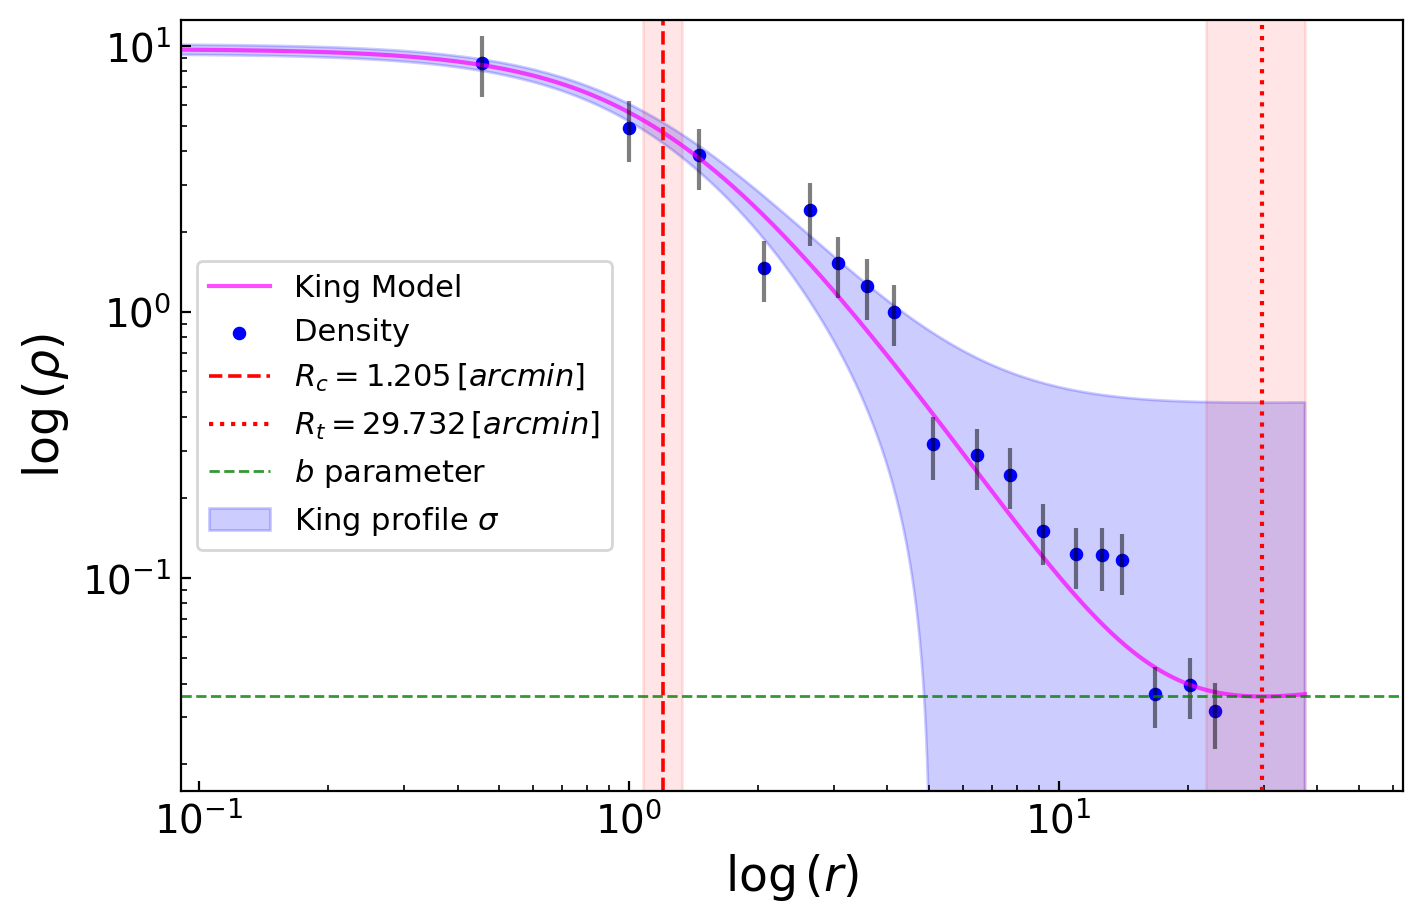

In [262]:
king_results = graph_king(data=data_gaia[cluster],centers=centers,savefig='Tex_File/Figures/',density_method='equip',
                          distances=parallax_results['mu_r_mean'],return_priors=True,prob_number=[0.6],paper_single=True,log_scale=True)

In [57]:
king_results = graph_king(data=data_gaia[cluster],centers=centers,savefig='Tex_File/Figures/',density_method='equip',
                          distances=parallax_results['mu_r_mean'],return_priors=True,prob_number=[0.6],paper_single=True,cluster_mass=np.nansum(data_gaia[cluster]['mass']))

KeyError: 'mass'

In [ ]:
cluster_mass=np.nansum(data_gaia[cluster]['mass'])

In [266]:
king_results

{'bayesian_results': {'k_mean': [10.50874801367478],
  'b_mean': [0.035753317468323165],
  'R_c_mean': [<Quantity 1.20450933 arcmin>],
  'R_t_mean': [<Quantity 29.73203044 arcmin>],
  'k_std': [0.7955225350768272],
  'b_std': [0.017915477607428922],
  'R_c_std': [0.12601043570076603],
  'R_t_std': [7.694726579810243],
  'king_std': [0.41926678014888313],
  'bg_level': [0.08949975029060993],
  'C': [3.206152644870737],
  'd_c': [118.41650652155316],
  'r_lim': [16.79954021651883],
  'half_light_radius': <Quantity 4.28499468 arcmin>},
 'priors': [{'cluster_mass': <Quantity 212.81085 solMass>,
   'galactic_radius': <Quantity 7.20501643 kpc>,
   'galactic_mass': <Quantity 1.43762779e+11 solMass>,
   'tidal_pot_radius': <Quantity 20.39419973 arcmin>,
   'hill_radius': <Quantity 17.81597448 arcmin>,
   'gravitational_bound_radius': <Quantity 26.66213603 arcmin>,
   'far_member': 24.52077564510203,
   'max_tidal': 26.662136027963545}]}

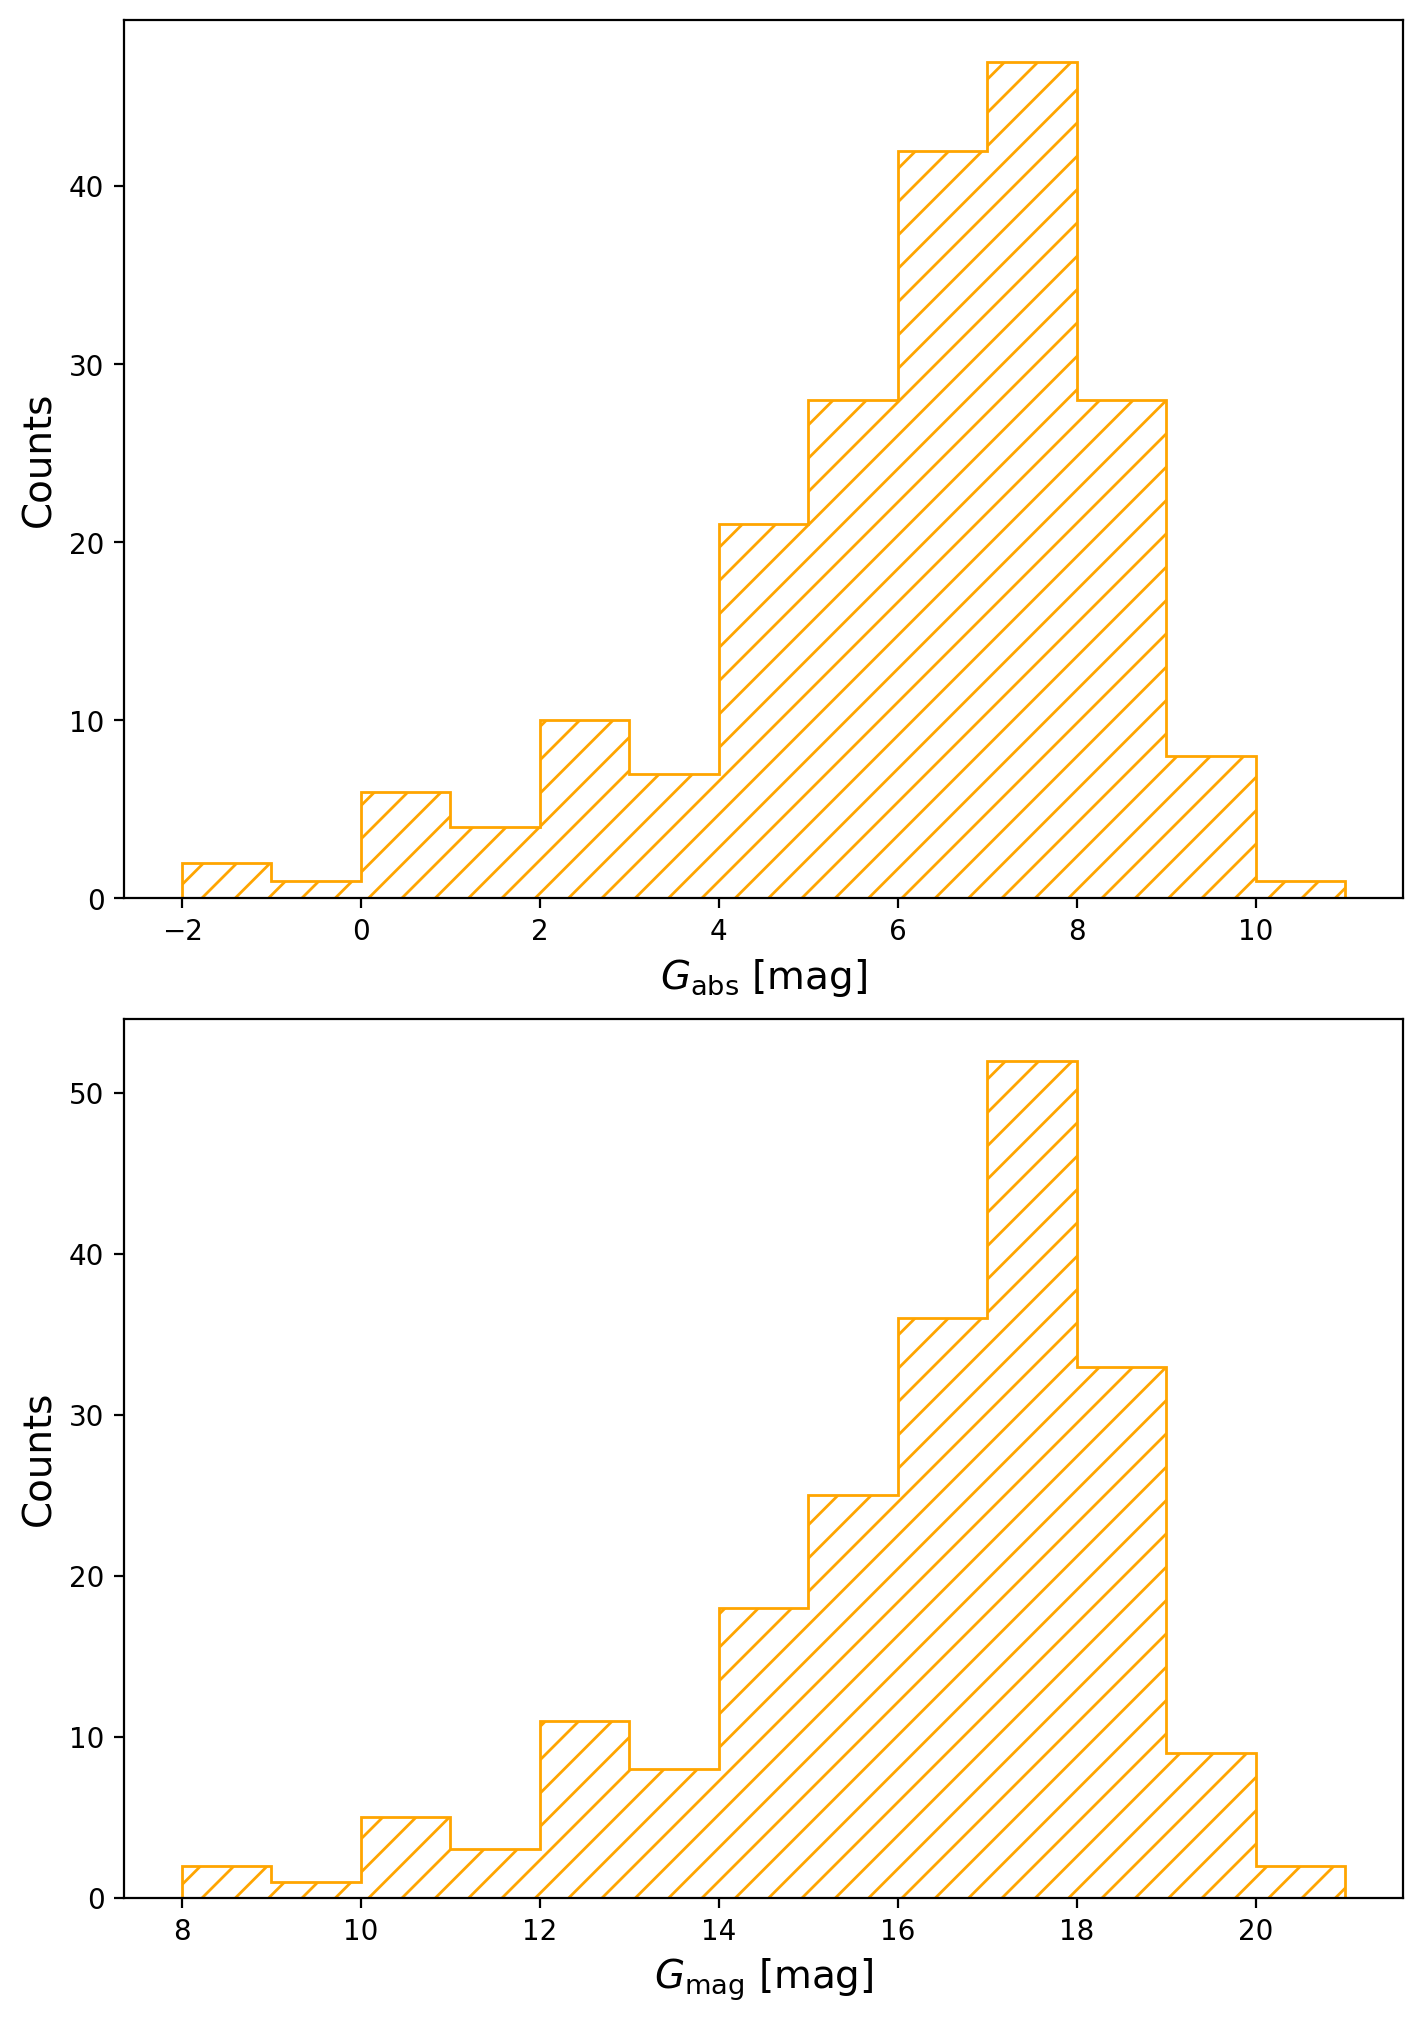

In [53]:
seventh = (cluster) & (data_gaia['probability'] >= 0.7)
lf = data_gaia[seventh]
abs_mag = calculate_absolute_magnitude(lf['Gmag'],parallax_results['mu_r_mean']*u.kpc)

min_mag = np.floor(np.nanmin(abs_mag)).value
max_mag = np.ceil(np.nanmax((abs_mag))).value
fig,ax = plt.subplots(2,1,layout='constrained',figsize=(7,10))
ax[0].hist(abs_mag,bins=np.arange(min_mag, max_mag + 1, 1),histtype='step',hatch='//',color='orange')
ax[0].set_xlabel(r'$G_\mathrm{abs}$ [mag]',fontsize=14)
ax[0].set_ylabel('Counts',fontsize=14)

min_mag = np.floor(np.min(lf['Gmag'])).value
max_mag = np.ceil(np.max(lf['Gmag'])).value

ax[1].hist(lf['Gmag'],bins=np.arange(min_mag, max_mag + 1, 1),histtype='step',hatch='//',color='orange')
ax[1].set_xlabel(r'$G_\mathrm{mag}$ [mag]',fontsize=14)
ax[1].set_ylabel('Counts',fontsize=14)

fig.savefig('Tex_File/Figures/luminosity_function.pdf',bbox_inches='tight')

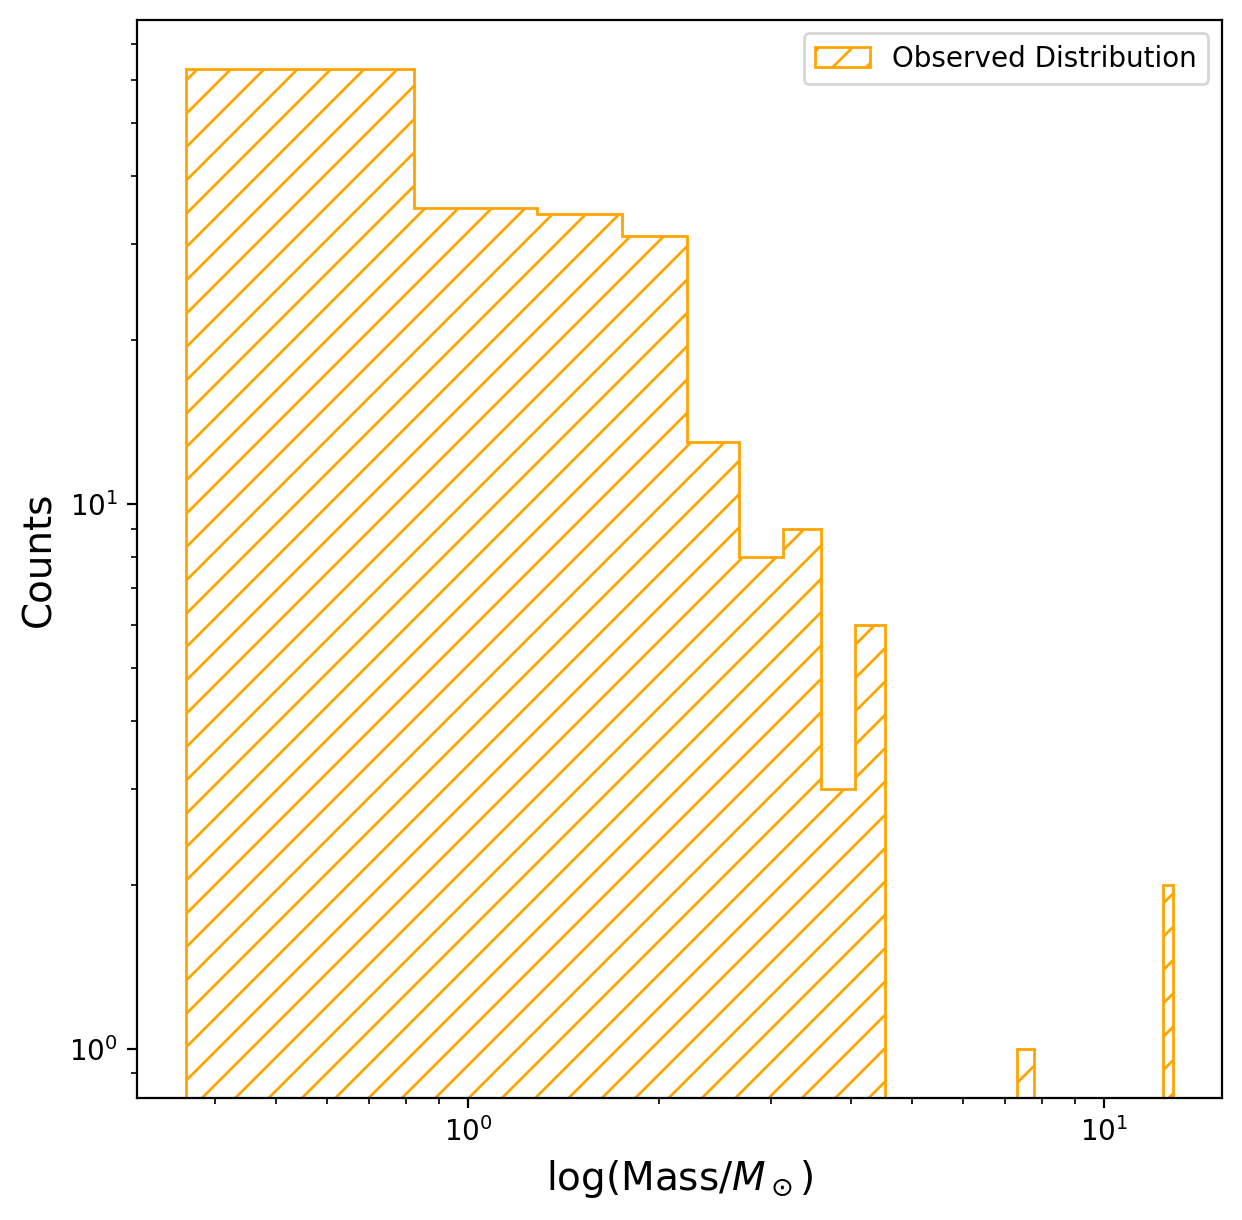

In [68]:
# Assuming data_gaia[cluster]['mass'] is your array of masses
masses = data_gaia[cluster]['mass']

min_mass = np.floor(np.nanmin(masses)).value
max_mass = np.ceil(np.nanmax(masses)).value

# Creating histogram
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.hist(masses, bins='auto', histtype='step', hatch='//', color='orange', label='Observed Distribution')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'log(Mass$/M_\odot$)', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)
ax.legend()
#fig.savefig('mass_function_with_fit.pdf', bbox_inches='tight')
plt.show()

In [55]:
np.nansum(data_gaia[cluster]['mass'])

<Quantity 334.47145 solMass>

### Cumulative plots

In [56]:
def plot_cumulative(data,centers,prob_number=[50,60,70,80],R_c=None,R_t=None,savefig=False):
    prob_number = np.array(prob_number) / 100
    centers = [SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg') for ra, dec in centers]
    if R_c is None:
        R_c = [None] * len(prob_number)
    if R_t is None:
        R_t = [None] * len(prob_number)
    if len(prob_number) == 1:
        fig_intmag, ax_intmag = plt.subplots(1, layout='constrained', figsize=(15,15))
    if len(prob_number) == 2:
        fig_intmag, ax_intmag = plt.subplots(1,2, layout='constrained', figsize=(17.5,7))
    if len(prob_number) == 3:
        fig_intmag, ax_intmag = plt.subplots(1,3, layout='constrained', figsize=(15,15))
    if len(prob_number) == 4:
        fig_intmag, ax_intmag = plt.subplots(2,2, layout='constrained', figsize=(15,11))
    if len(prob_number) == 1:
        ax_intmag = np.array(ax_intmag)
    for i, ax, center,r_c,r_t in zip(prob_number, ax_intmag.flatten(),centers,R_c,R_t):
        print(f"{i * 100}%")
        cumulative = []
        selected_data = data[data['probability'] >= i]
        selected_data['d_center'] = (angular_separation(selected_data['ra'], selected_data['dec'], center.ra, center.dec)).to(u.arcmin)
        x_radius = np.linspace(0,np.max(selected_data['d_center'].value),400)
        for r in x_radius:
            sum_i = -2.5 * np.log10(np.sum(10 ** ((selected_data[(selected_data['d_center'] <= r*u.arcmin)]['Gmag']).value / -2.5)) ) 
            cumulative.append(sum_i)
        intmag = ax.twinx()
        if r_c is None:
            ax.scatter(selected_data['d_center'],selected_data['Gmag'],s=10,color='blue')
        else:
            ax.scatter(selected_data['d_center'][selected_data['d_center'] <= r_c],selected_data['Gmag'][selected_data['d_center'] <= r_c],s=10,color='blue',label='$R \leq R_c$')
            ax.scatter(selected_data['d_center'][selected_data['d_center'] > r_c],selected_data['Gmag'][selected_data['d_center'] > r_c],s=10,color='gray',label='$R > R_c$')
        if r_c is not None:
            ax.axvline(r_c, color='green', label=r'$R_c = {:.3f} [{}]$'.format(r_c.value, u.arcmin), linestyle='-.',linewidth=2,alpha=0.8)
        if r_t is not None:
            ax.axvline(r_t, color='red', label=r'$R_t = {:.3f} [{}]$'.format(r_t.value, u.arcmin), linestyle='-.',linewidth=2,alpha=0.8)
        ax.legend(loc='lower right')
        intmag.plot(x_radius,cumulative,color='red',label='Integred Magnitude',linewidth=1)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        intmag.xaxis.set_minor_locator(ticker.AutoMinorLocator()),intmag.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.set(xlabel='Radius [{}]'.format(u.arcmin),ylabel=r'$G_{{mag}}\,[{}]$'.format(selected_data['Gmag'].unit))
        intmag.set(ylabel=r'$\sum G_{{mag}}\,[{}]$'.format(u.mag))
        ax.tick_params(axis='both', which='both', direction='in'),intmag.tick_params(axis='both', which='both', direction='in');
        intmag.legend()
        intmag.invert_yaxis(),ax.invert_yaxis()
        ax.set_title(str(round(i * 100)) + '% probability members')
        print(np.max(selected_data['d_center']))
    if savefig:
        fig_intmag.savefig(savefig + 'integred_magnitude.pdf',dpi='figure')
    plt.show()

50.0%


/var/folders/lj/qxq0p2094c559nnsb15xhpnh0000gn/T/ipykernel_19337/2660482464.py:25: RuntimeWarning: divide by zero encountered in log10
  sum_i = -2.5 * np.log10(np.sum(10 ** ((selected_data[(selected_data['d_center'] <= r*u.arcmin)]['Gmag']).value / -2.5)) )


39.979992887782885 arcmin


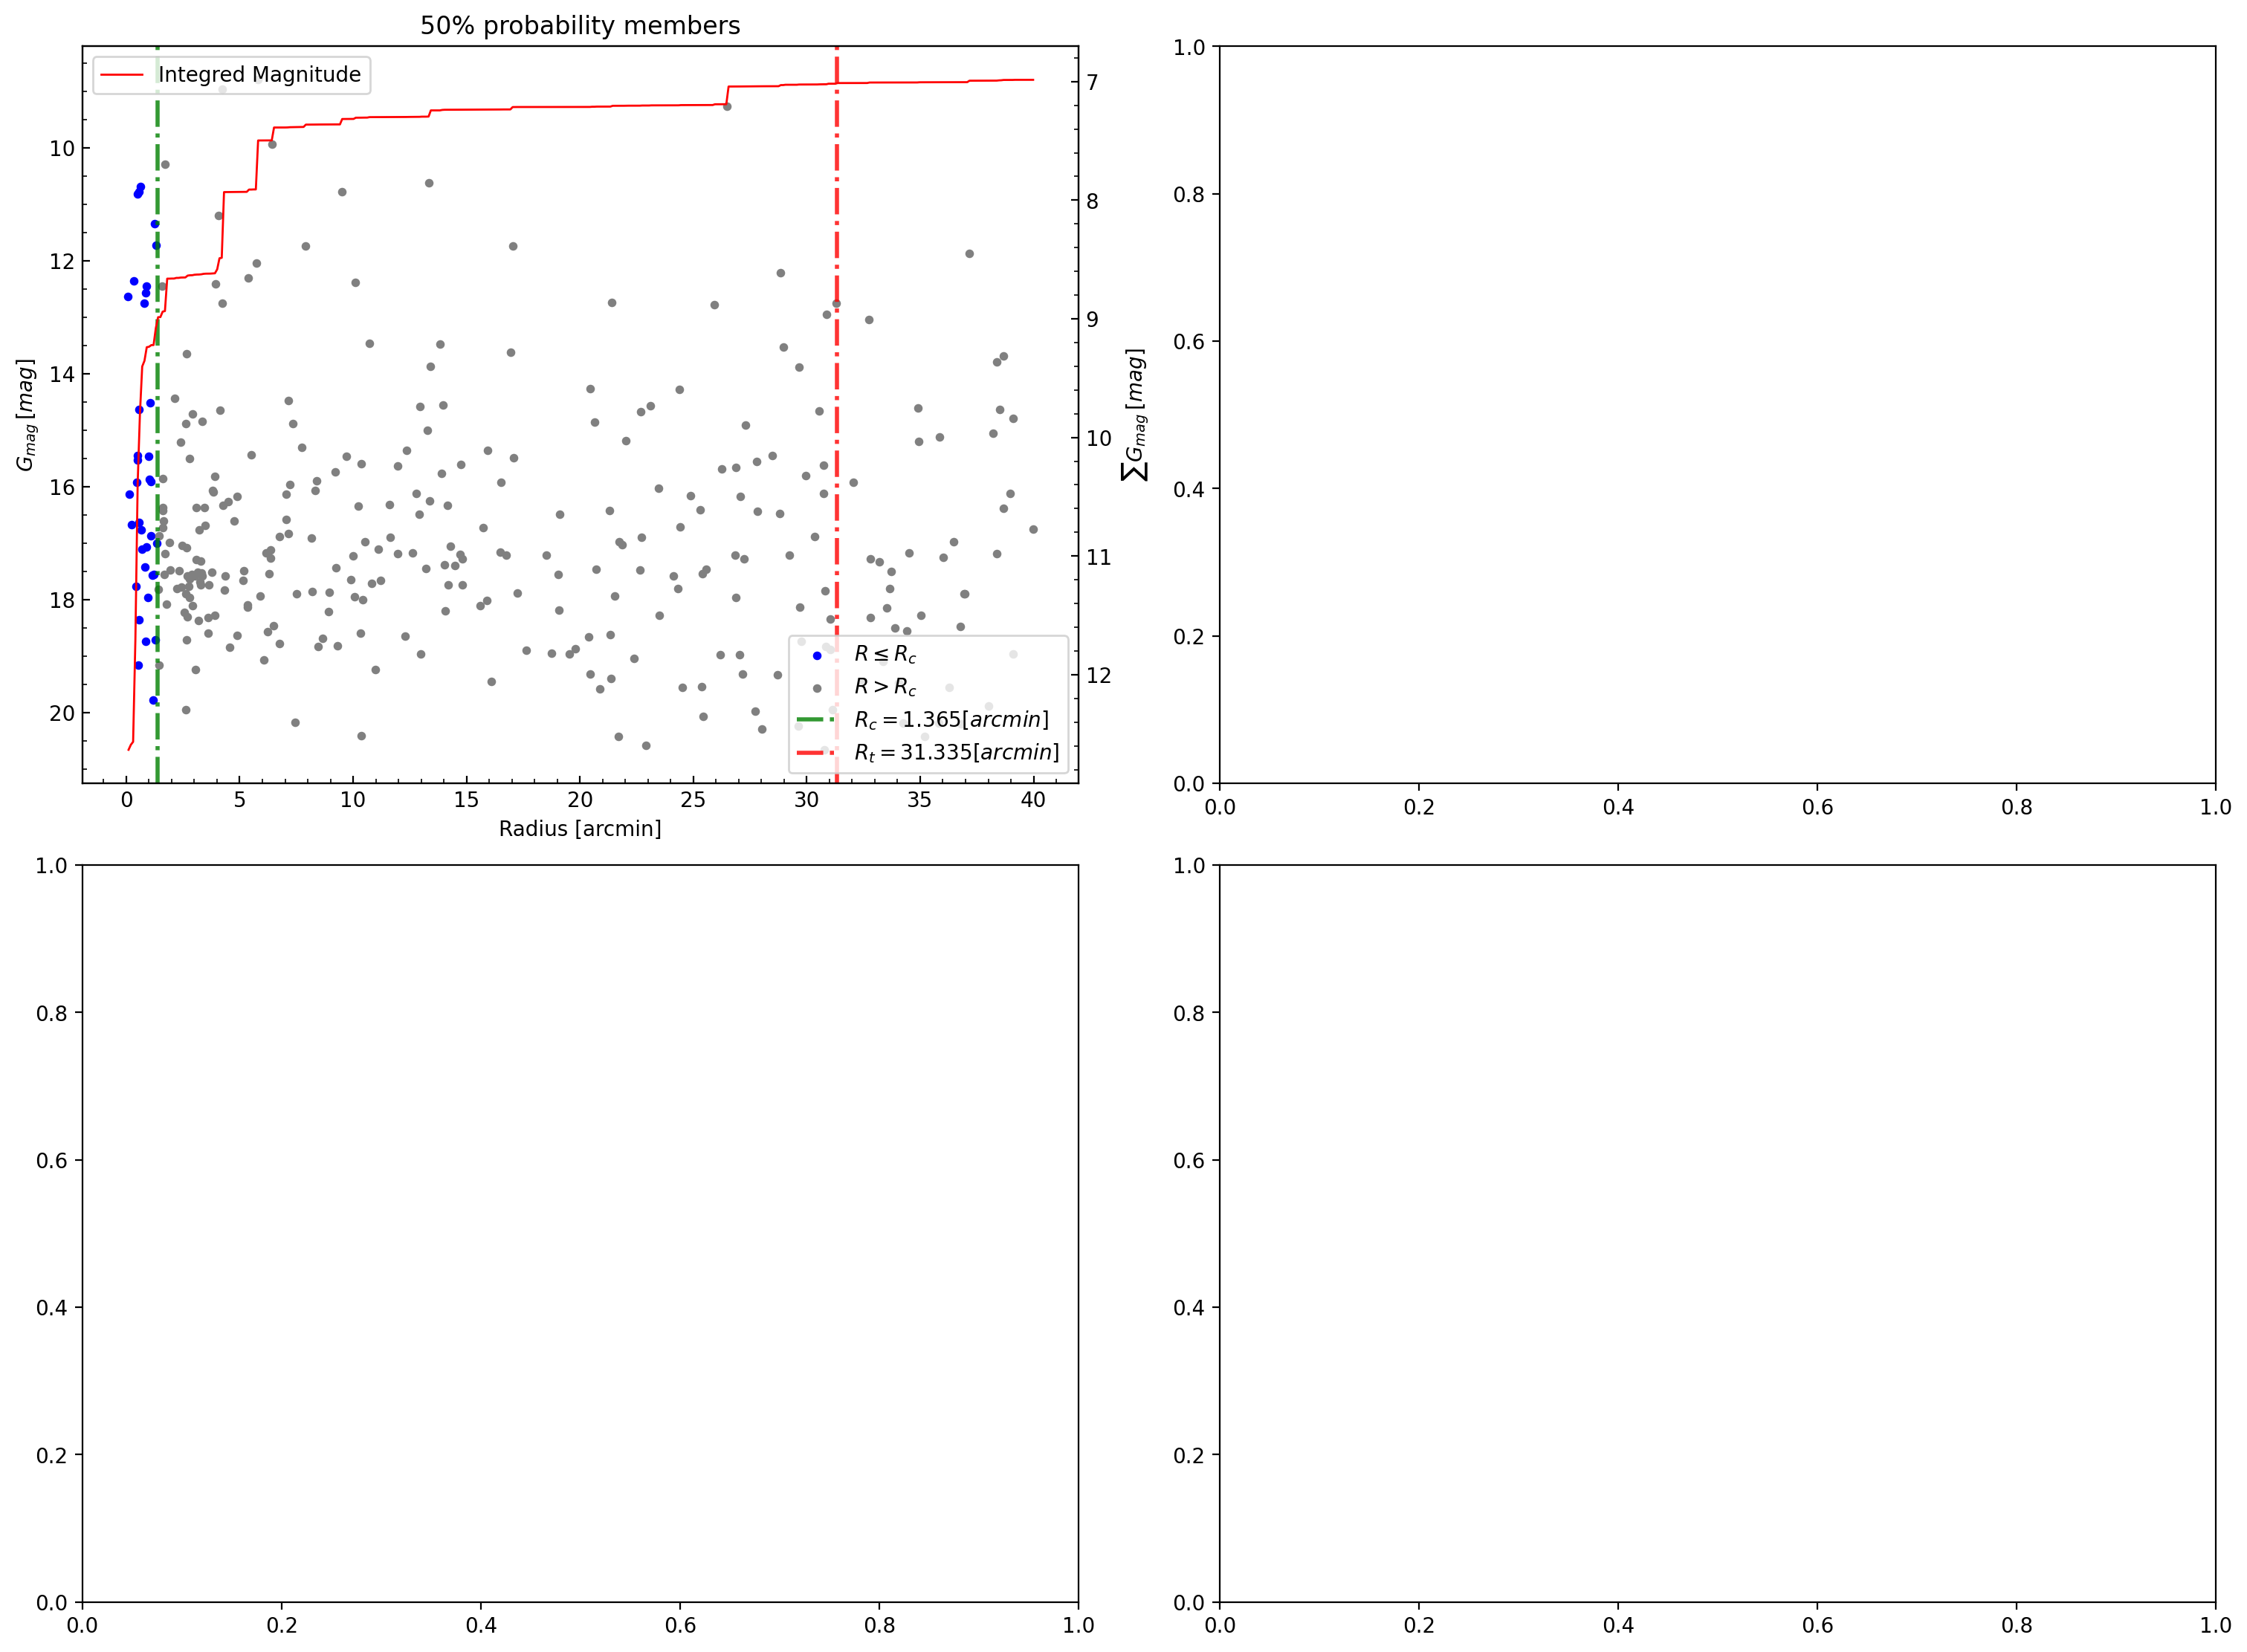

In [57]:
extracted_centers = [(item[0][0], item[0][1]) for item in centers]
plot_cumulative(data=data_gaia[cluster],centers=extracted_centers,R_c=king_results['bayesian_results']['R_c_mean'],R_t=king_results['bayesian_results']['R_t_mean'] ,savefig='Tex_File/Figures/')

In [58]:
def plot_cumulative_by_brightness(data, centers, prob_number=[50, 60, 70, 80], brightness_ranges=None, savefig=None, R_c=None, R_t=None, normalize=False, ks=True):
    prob_number = np.array(prob_number) / 100
    centers = [SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg') for ra, dec in centers]
    num_plots = len(prob_number)
    
    if R_c is None:
        R_c = [None] * len(prob_number)
    if R_t is None:
        R_t = [None] * len(prob_number)
    
    # Define brightness ranges if not supplied
    if brightness_ranges is None:
        gmag_sorted = np.sort(data['Gmag'])
        quartiles = np.percentile(gmag_sorted, [0, 25, 50, 75, 100])
        brightness_ranges = [(quartiles[i], quartiles[i+1]) for i in range(len(quartiles)-1)]
    if len(prob_number) == 2:
        figsize = (12,8)
    elif len(prob_number) == 1:
        figsize = (8,8)
    fig, axs = plt.subplots((num_plots + 1) // 2, 2 if num_plots > 1 else 1, figsize=figsize)
    axs = axs.flatten() if num_plots > 1 else [axs]
    
    ks_results = {}

    for i, ax, center, r_c, r_t in zip(prob_number, axs, centers, R_c, R_t):
        selected_data = data[data['probability'] >= i]
        selected_data['d_center'] = angular_separation(selected_data['ra'], selected_data['dec'], center.ra, center.dec).to(u.arcmin)
        x_radius = np.linspace(0, np.max(selected_data['d_center'].value), 400)
        
        cumulative_counts = [[] for _ in range(len(brightness_ranges))]
        total_counts = []  # Store total counts for each brightness range
        
        # Calculate total counts for normalization
        for (mag_min, mag_max) in brightness_ranges:
            total_counts.append(len(selected_data[(selected_data['Gmag'] > mag_min) & 
                                                  (selected_data['Gmag'] <= mag_max)]))
        
        for r in x_radius:
            for j, (mag_min, mag_max) in enumerate(brightness_ranges):
                count = len(selected_data[(selected_data['d_center'] <= r*u.arcmin) & 
                                          (selected_data['Gmag'] > mag_min) & 
                                          (selected_data['Gmag'] <= mag_max)])
                cumulative_counts[j].append(count)
        
        for j, (mag_min, mag_max) in enumerate(brightness_ranges):
            counts = cumulative_counts[j]
            if total_counts[j] > 0:  # Avoid division by zero
                normalized_counts = np.array(counts) / total_counts[j] if normalize else counts
                label = f'Gmag: {mag_min:.2f} to {mag_max:.2f}'
                ax.plot(x_radius, normalized_counts, label=label)
        
        if r_c is not None and r_c.value:
            ax.axvline(r_c.value, color='green', label=f'R_c = {r_c:.2f}', linestyle='-.', linewidth=2, alpha=0.8)
        if r_t is not None and r_t.value:
            ax.axvline(r_t.value, color='red', label=f'R_t = {r_t:.2f}', linestyle='-.', linewidth=2, alpha=0.8)
        
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.set(xlabel='Radius [arcmin]', ylabel='Normalized cumulative count' if normalize else 'Cumulative count')
        ax.legend()
        ax.set_title(f"{int(i * 100)}% probability members")

    # Perform the K-S test if ks is True
    if ks:
        for i in range(len(brightness_ranges) - 1):
            for j in range(i+1, len(brightness_ranges)):
                # Extract the distances from the cluster center for each brightness bin
                dist_i = selected_data[(selected_data['Gmag'] > brightness_ranges[i][0]) &
                                       (selected_data['Gmag'] <= brightness_ranges[i][1])]['d_center']
                dist_j = selected_data[(selected_data['Gmag'] > brightness_ranges[j][0]) &
                                       (selected_data['Gmag'] <= brightness_ranges[j][1])]['d_center']
                
                # Check if we have enough data points to perform K-S test
                if len(dist_i) > 0 and len(dist_j) > 0:
                    ks_stat, ks_pvalue = ks_2samp(dist_i, dist_j)
                    ks_results[(brightness_ranges[i], brightness_ranges[j])] = (ks_stat, ks_pvalue)
    
        # Print the K-S test results
        print("K-S test results:")
        for ((min_i, max_i), (min_j, max_j)), (ks_stat, ks_pvalue) in ks_results.items():
            print(f"Between brightness range {min_i:.3f}, {max_i:.3f} and {min_j:.3f}, {max_j:.3f}: KS-statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")


    # Save the figure if a save path is provided

    if savefig:
        plt.savefig(savefig + 'cumulative_by_brightness.pdf', bbox_inches='tight')

    # Show the plot
    plt.show()

K-S test results:
Between brightness range 8.800 mag, 15.603 mag and 15.603 mag, 17.174 mag: KS-statistic=0.1154, p-value=0.7622
Between brightness range 8.800 mag, 15.603 mag and 17.174 mag, 18.111 mag: KS-statistic=0.1584, p-value=0.4740
Between brightness range 8.800 mag, 15.603 mag and 18.111 mag, 20.662 mag: KS-statistic=0.2803, p-value=0.0349
Between brightness range 15.603 mag, 17.174 mag and 17.174 mag, 18.111 mag: KS-statistic=0.1372, p-value=0.6551
Between brightness range 15.603 mag, 17.174 mag and 18.111 mag, 20.662 mag: KS-statistic=0.3713, p-value=0.0018
Between brightness range 17.174 mag, 18.111 mag and 18.111 mag, 20.662 mag: KS-statistic=0.3436, p-value=0.0084


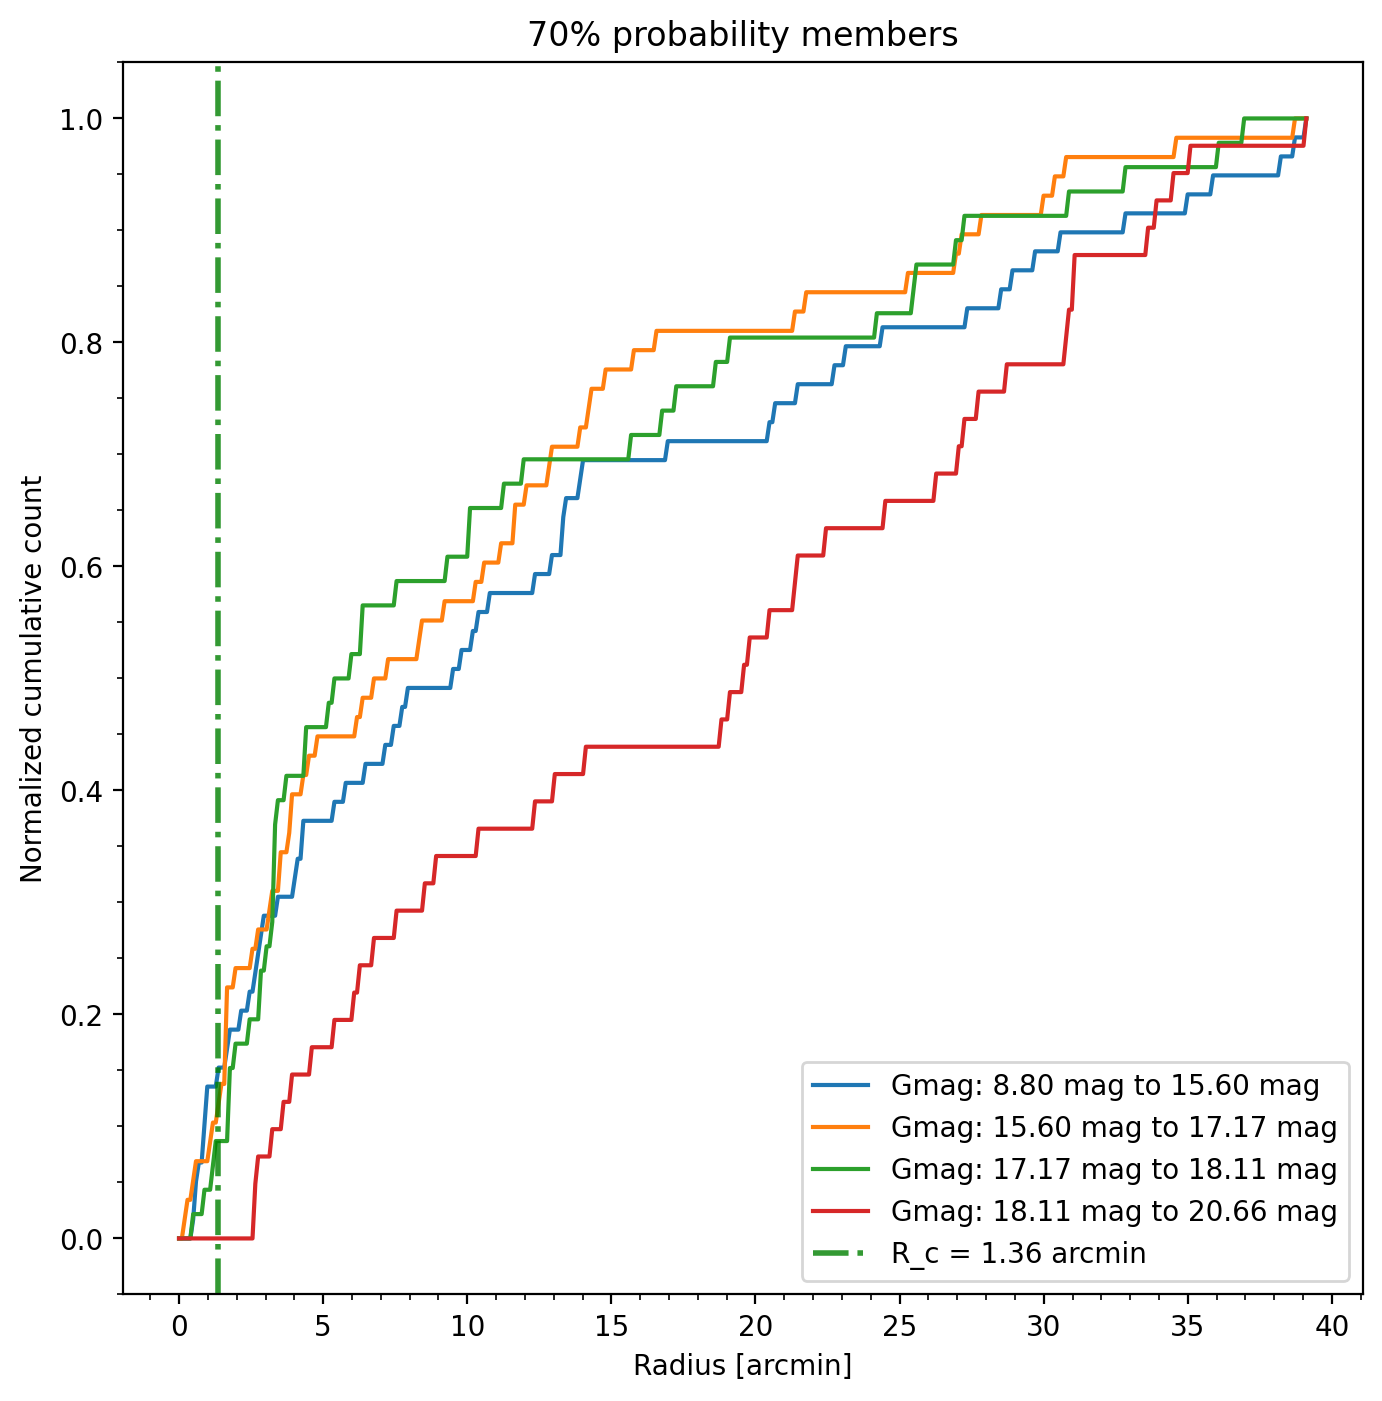

In [59]:
plot_cumulative_by_brightness(data=data_gaia[cluster],prob_number=[70],centers=extracted_centers,R_c=king_results['bayesian_results']['R_c_mean'],savefig='Tex_File/Figures/',normalize=True,ks=True)

In [60]:
def plot_cumulative_by_mass_and_type(data, centers, prob_number=[70], mass_ranges=None, savefig=None, R_c=None, R_t=None, normalize=False, ks=True):
    prob_number = np.array(prob_number) / 100
    centers = [SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg') for ra, dec in centers]

    if mass_ranges is None:
        mass_sorted = np.sort(data['mass'])
        quartiles = np.percentile(mass_sorted, [0, 25, 50, 75, 100])
        mass_ranges = [(quartiles[i], quartiles[i+1]) for i in range(4)]

    figsize = (18, 6)
    fig, axs = plt.subplots(1, 3, figsize=figsize, squeeze=False)
    axs = axs.flatten()

    data = data[data['probability'] >= prob_number[0]]
    data['d_center'] = angular_separation(data['ra'], data['dec'], centers[0].ra, centers[0].dec).to(u.arcmin)
    binary_data = data[data['P_binar'] >= 0.6]
    single_data = data[data['P_binar'] < 0.6]

    datasets = [('Single Stars', single_data), ('Binary Stars', binary_data)]
    ks_results = {}

    for idx, (title, selected_data) in enumerate(datasets):
        ax = axs[idx]
        all_dists = []

        for (mass_min, mass_max) in mass_ranges:
            mask = (selected_data['mass'] >= mass_min) & (selected_data['mass'] < mass_max)
            dists = selected_data[mask]['d_center']
            all_dists.append(dists)

            cumulative_dist = np.array([np.sum(dists <= r) for r in np.linspace(0, np.max(selected_data['d_center']), 400)])
            if normalize:
                cumulative_dist = cumulative_dist / np.max(cumulative_dist)
            label = f'Mass: {mass_min:.2f}-{mass_max:.2f} Msun'
            ax.plot(np.linspace(0, np.max(selected_data['d_center']), 400), cumulative_dist, label=label)

        # Perform KS tests within each dataset and store results
        if ks and len(mass_ranges) > 1:
            for i in range(len(all_dists) - 1):
                for j in range(i + 1, len(all_dists)):
                    if len(all_dists[i]) > 0 and len(all_dists[j]) > 0:
                        ks_stat, ks_pvalue = ks_2samp(all_dists[i], all_dists[j])
                        ks_results[(title, f"Mass range {i+1} vs {j+1}")] = (ks_stat, ks_pvalue)

        ax.set_title(title)
        ax.set_xlabel('Radius (arcmin)')
        ax.set_ylabel('Cumulative distribution' + (' (normalized)' if normalize else ''))
        ax.legend()

    # Third plot: Cumulative sum independent of mass range for single and binary stars
    ax = axs[2]
    single_dists = single_data['d_center']
    binary_dists = binary_data['d_center']
    ks_stat, ks_pvalue = ks_2samp(single_dists, binary_dists)
    ks_results[('Single vs Binary Stars', 'Overall')] = (ks_stat, ks_pvalue)

    for title, dataset in [('Single Stars', single_dists), ('Binary Stars', binary_dists)]:
        cumulative_dist = np.array([np.sum(dataset <= r) for r in np.linspace(0, np.max(data['d_center']), 400)])
        if normalize:
            cumulative_dist = cumulative_dist / np.max(cumulative_dist)
        ax.plot(np.linspace(0, np.max(data['d_center']), 400), cumulative_dist, label=title)

    ax.set_title('Cumulative Distribution: Single vs Binary Stars')
    ax.set_xlabel('Radius (arcmin)')
    ax.set_ylabel('Cumulative distribution' + (' (normalized)' if normalize else ''))
    ax.legend()

    if savefig:
        plt.savefig(savefig + 'cumulative_by_mass_and_type.pdf', bbox_inches='tight')
    plt.show()

    # Print KS test results
    print("K-S test results:")
    for key, (ks_stat, ks_pvalue) in ks_results.items():
        print(f"{key[0]} - {key[1]}: KS-stat={ks_stat:.4f}, p-value={ks_pvalue:.4f}")


/var/folders/lj/qxq0p2094c559nnsb15xhpnh0000gn/T/ipykernel_19337/1694976679.py:33: RuntimeWarning: invalid value encountered in divide
  cumulative_dist = cumulative_dist / np.max(cumulative_dist)


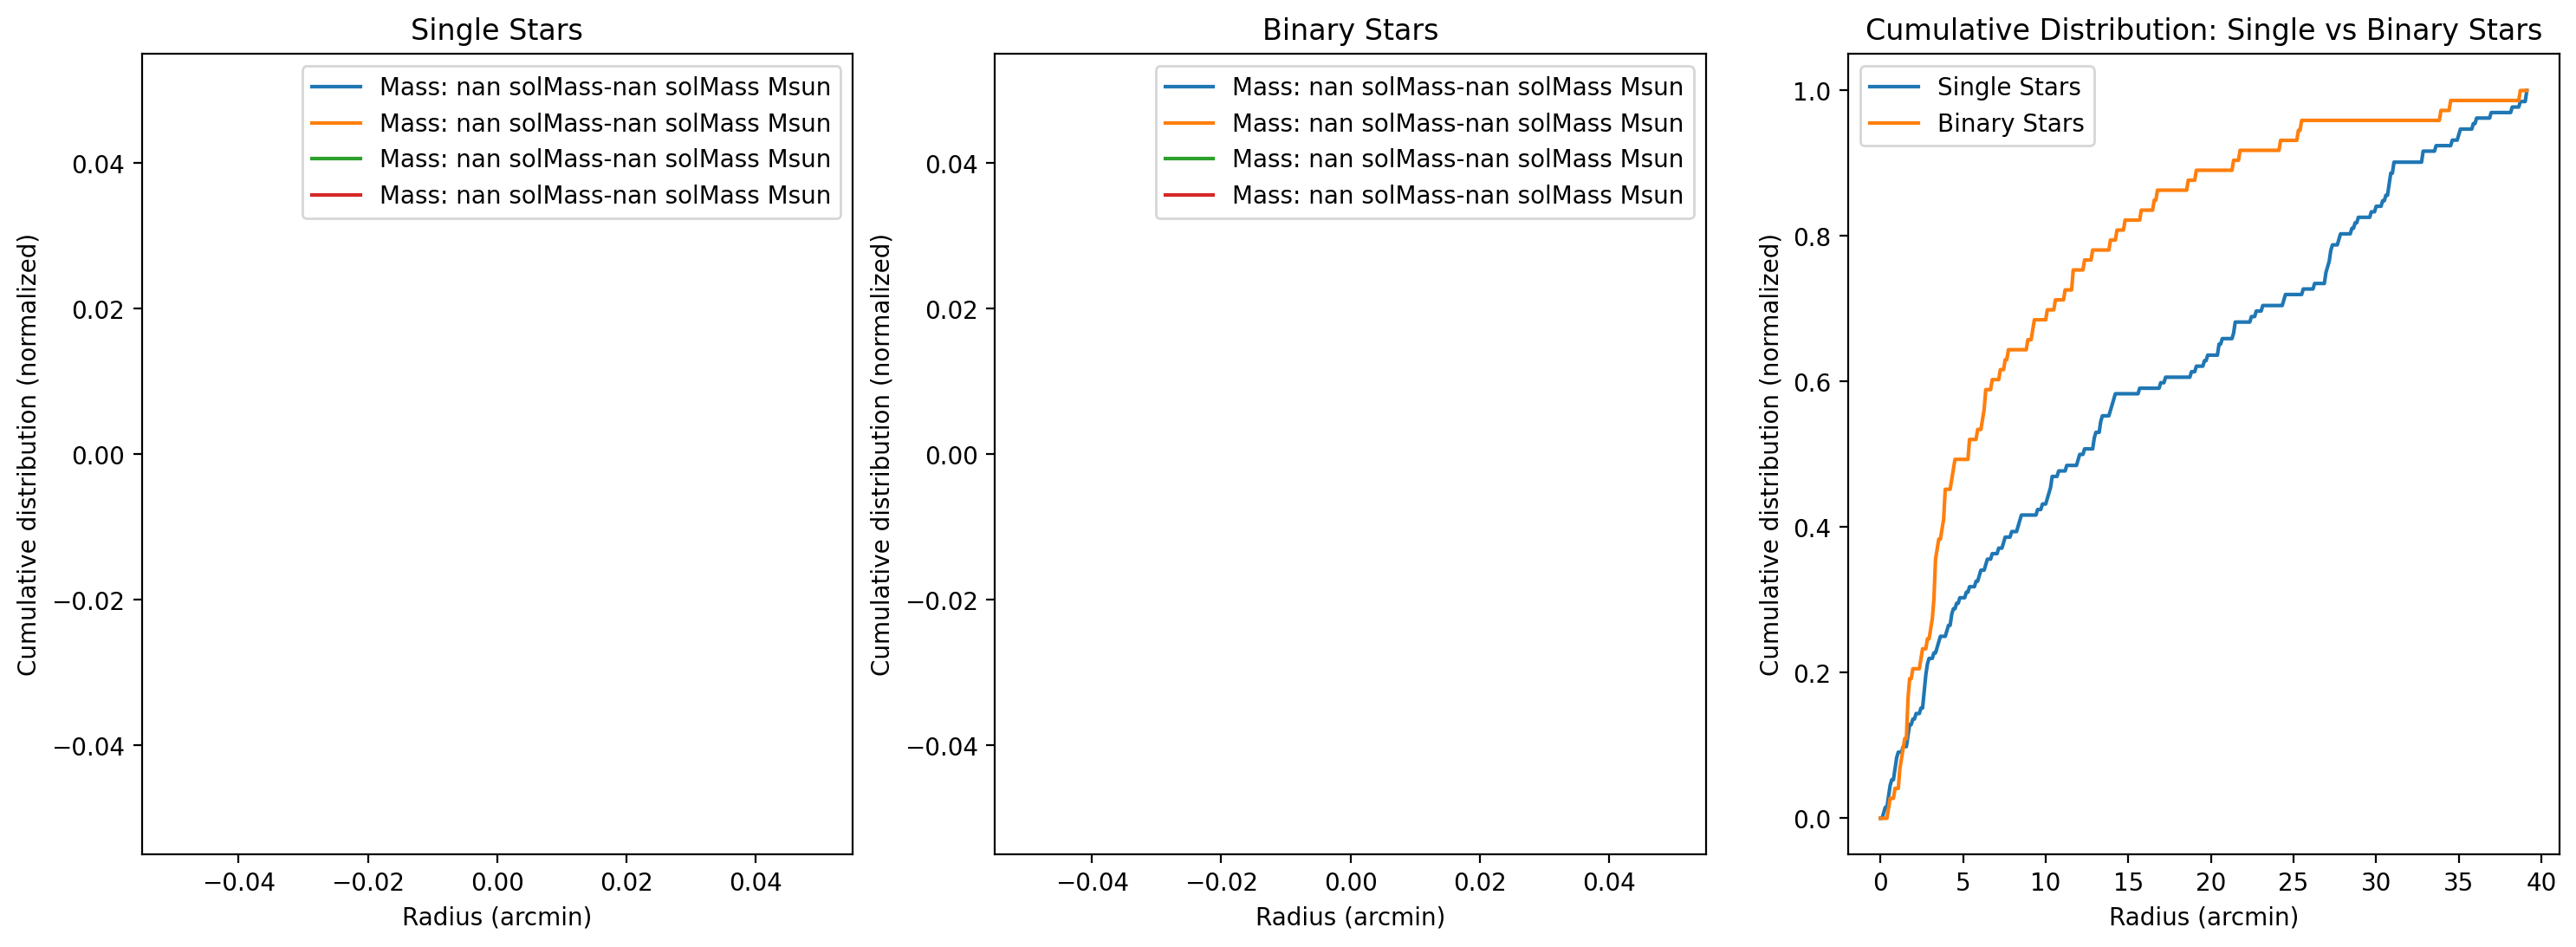

K-S test results:
Single vs Binary Stars - Overall: KS-stat=0.2732, p-value=0.0013


In [61]:
plot_cumulative_by_mass_and_type(data=data_gaia[cluster],prob_number=[70],centers=extracted_centers,R_c=king_results['bayesian_results']['R_c_mean'],savefig='Tex_File/Figures/',normalize=True,ks=True)

In [62]:
def plot_cumulative_by_mass(data, centers, prob_number=[50, 60, 70, 80], mass_ranges=None, savefig=None, R_c=None, R_t=None, normalize=False, ks=True):
    prob_number = np.array(prob_number) / 100
    centers = [SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg') for ra, dec in centers]
    num_plots = len(prob_number)
    
    if R_c is None:
        R_c = [None] * len(prob_number)
    if R_t is None:
        R_t = [None] * len(prob_number)
    
    if mass_ranges is None:
        mass_sorted = np.sort(data['mass'])
        quartiles = np.percentile(mass_sorted, [0, 25, 50, 75, 100])
        mass_ranges = [(quartiles[i].value.__float__()*u.Msun, quartiles[i+1].value.__float__()*u.Msun) for i in range(len(quartiles)-1)]
    
    figsize = (12, 8) if len(prob_number) == 2 else (8, 8)
    fig, axs = plt.subplots((num_plots + 1) // 2, 2 if num_plots > 1 else 1, figsize=figsize, squeeze=False)
    axs = axs.flatten()
    
    ks_results = {}
    
    for idx, (i, center, r_c, r_t) in enumerate(zip(prob_number, centers, R_c, R_t)):
        ax = axs[idx]
        selected_data = data[data['probability'] >= i]
        selected_data['d_center'] = angular_separation(selected_data['ra'], selected_data['dec'], center.ra, center.dec).to(u.arcmin)
        x_radius = np.linspace(0, np.max(selected_data['d_center'].value), 400)*u.arcmin
        
        for (mass_min, mass_max) in mass_ranges:
            mask = (selected_data['mass'] >= mass_min) & (selected_data['mass'] < mass_max)
            dists = selected_data[mask]['d_center']
            cumulative_dist = np.array([np.sum(dists <= r) for r in x_radius])
            
            if normalize:
                cumulative_dist = cumulative_dist / np.max(cumulative_dist)
                
            label = f'Mass: {mass_min:.2f}-{mass_max:.2f} Msun'
            ax.plot(x_radius, cumulative_dist, label=label)
        
        if ks and len(mass_ranges) > 1:
            for j in range(len(mass_ranges) - 1):
                for k in range(j + 1, len(mass_ranges)):
                    dist_j = selected_data[(selected_data['mass'] >= mass_ranges[j][0]) & (selected_data['mass'] < mass_ranges[j][1])]['d_center']
                    dist_k = selected_data[(selected_data['mass'] >= mass_ranges[k][0]) & (selected_data['mass'] < mass_ranges[k][1])]['d_center']
                    # Check if we have enough data points to perform K-S test
                    if len(dist_j) > 0 and len(dist_k) > 0:
                        ks_stat, ks_pvalue = ks_2samp(dist_j.value, dist_k.value)
                        ks_results[(mass_ranges[j], mass_ranges[k])] = (ks_stat, ks_pvalue)
            
        ax.set_title(f'Prob >= {i*100}%')
        ax.set_xlabel('Radius (arcmin)')
        ax.set_ylabel('Cumulative distribution' + (' (normalized)' if normalize else ''))
        ax.legend()
    
    if savefig:
        plt.savefig(savefig + 'cumulative_by_mass.pdf', bbox_inches='tight')
    plt.show()
    
    # Print KS test results
    if ks:
        print("K-S test results:")
        for (range_i, range_j), (ks_stat, ks_pvalue) in ks_results.items():
             print(f"Between mass range {range_i} and {range_j}: KS-stat={ks_stat:.4f}, p-value={ks_pvalue:.4f}")

/var/folders/lj/qxq0p2094c559nnsb15xhpnh0000gn/T/ipykernel_19337/2952954011.py:34: RuntimeWarning: invalid value encountered in divide
  cumulative_dist = cumulative_dist / np.max(cumulative_dist)


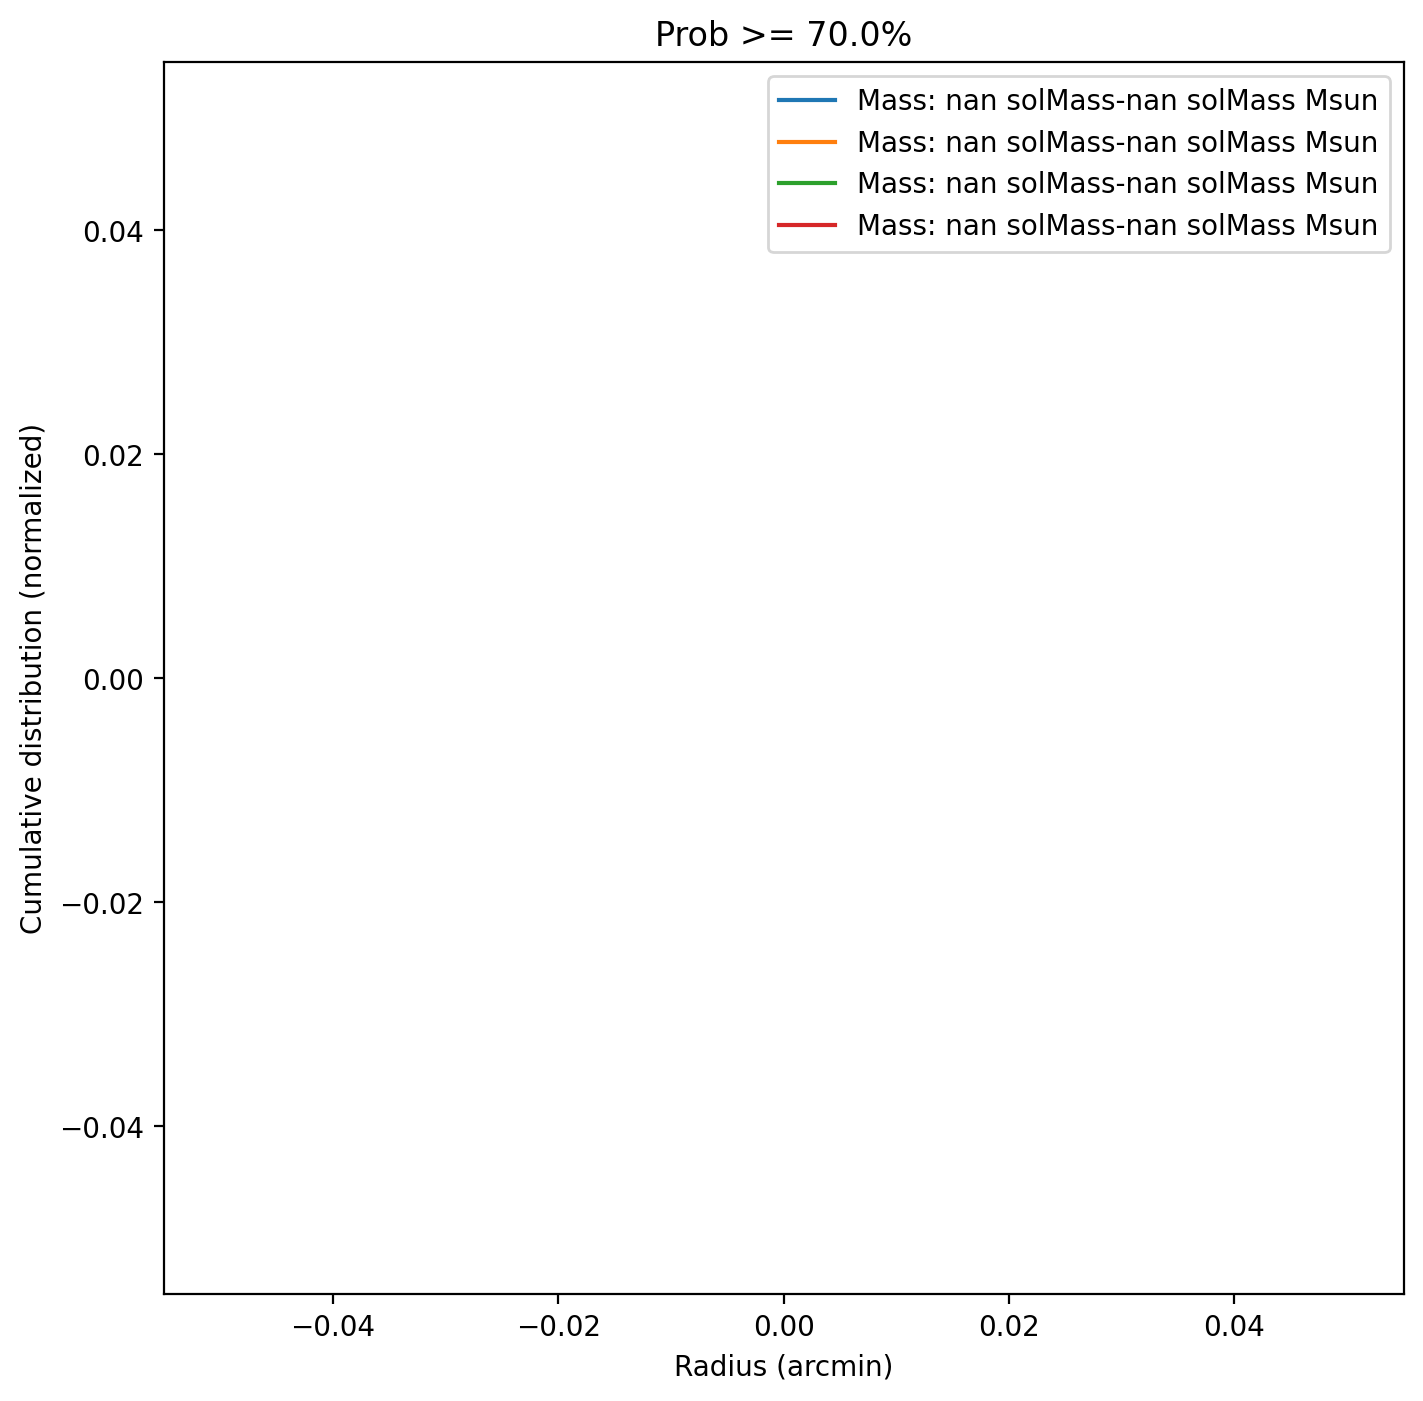

K-S test results:


In [63]:
a = plot_cumulative_by_mass(data=data_gaia[cluster],prob_number=[70],centers=extracted_centers,R_c=king_results['bayesian_results']['R_c_mean'],savefig='Tex_File/Figures/',normalize=True,ks=True)

In [64]:
a

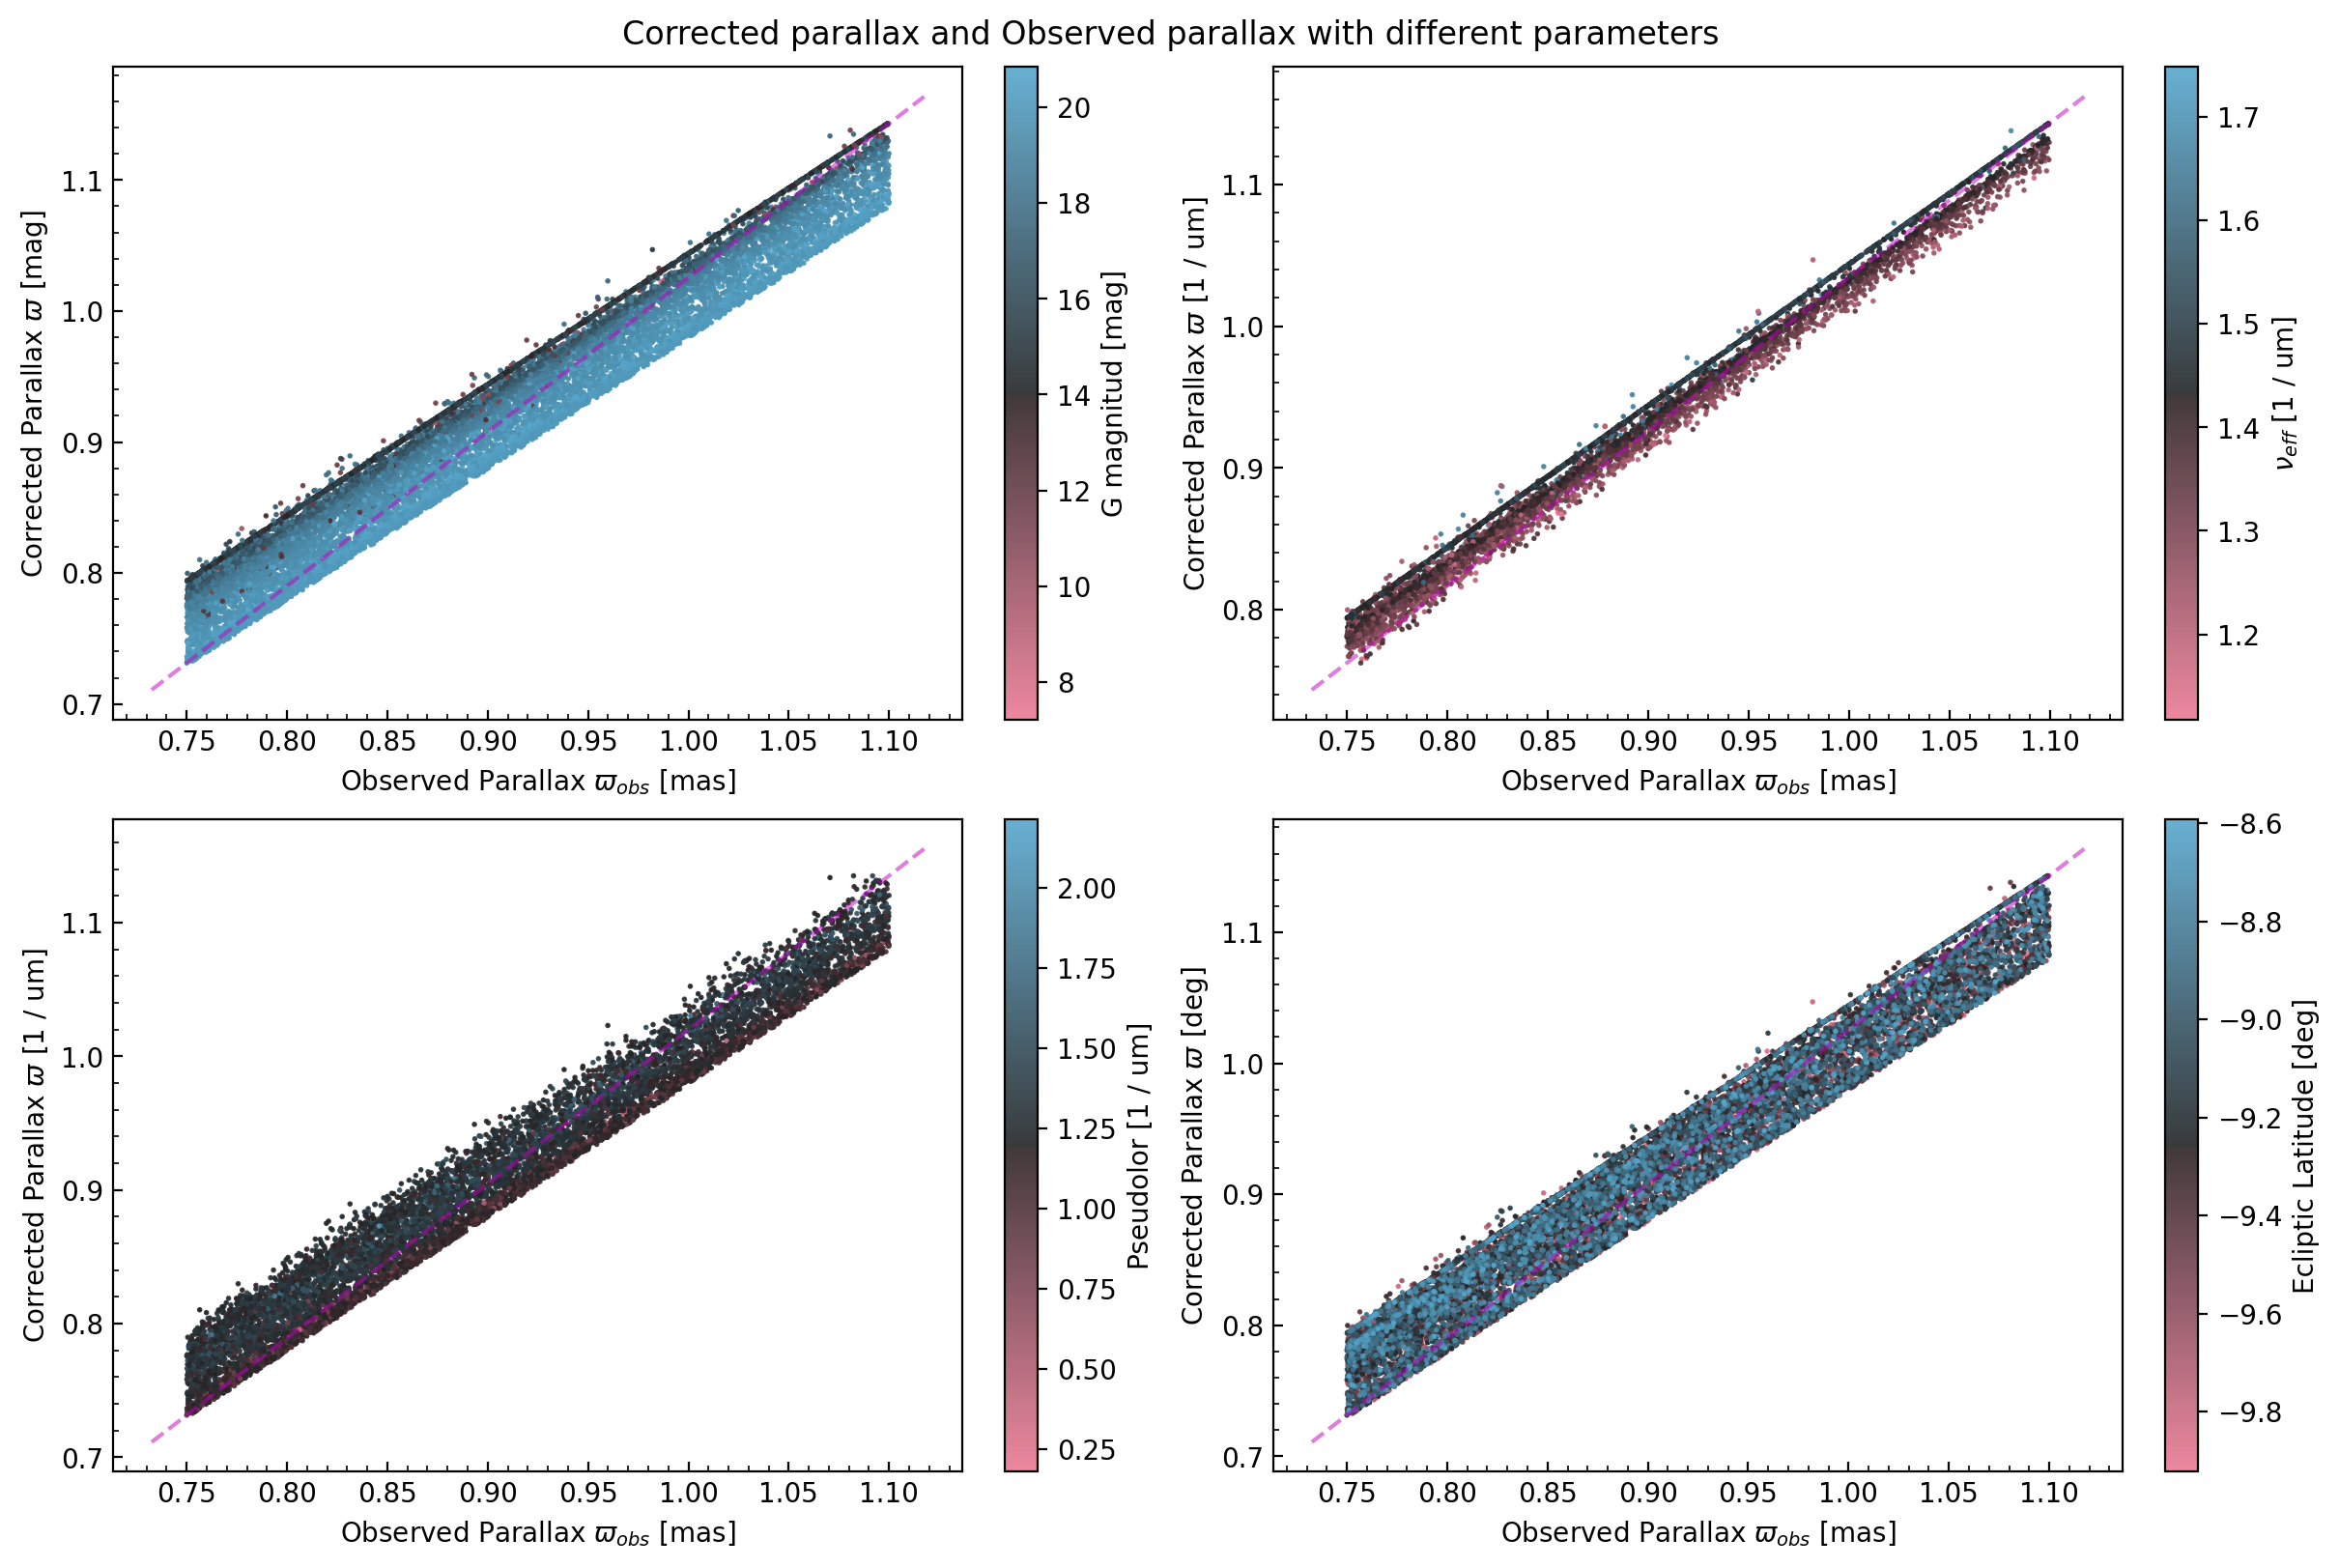

In [65]:
#### Parallax observed vs Parallax corrected

fig_pp, ax_pp = plt.subplots(2,2, layout='constrained',figsize=(12,8))

pp_sc_gmag = ax_pp[0,0].scatter(data_gaia['parallax_observed'],data_gaia['parallax'],1,c=data_gaia['Gmag'].data,alpha=0.9,cmap=sns.diverging_palette(359,230, l=65, center="dark", as_cmap=True))
ax_pp[0,0].plot(ax_pp[0,0].get_xlim(), ax_pp[0,0].get_ylim(),'m--',alpha=0.5)
fig_pp.colorbar(pp_sc_gmag,ax=ax_pp[0,0]).set_label(r'G magnitud [{}]'.format(data_gaia['Gmag'].unit))
ax_pp[0,0].set(xlabel=r'Observed Parallax $\varpi_{{obs}}$ [{}]'.format(data_gaia['parallax_observed'].unit),ylabel=r'Corrected Parallax $\varpi$ [{}]'.format(data_gaia['Gmag'].unit))
ax_pp[0,0].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_pp[0,0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_pp[0,0].tick_params(axis='both', which='both', direction='in')

pp_sc_nu = ax_pp[0,1].scatter(data_gaia['parallax_observed'],data_gaia['parallax'],1,c=data_gaia['nu_eff_used_in_astrometry'].data,alpha=0.9,cmap=sns.diverging_palette(359,230, l=65, center="dark", as_cmap=True))
ax_pp[0,1].plot(ax_pp[0,1].get_xlim(), ax_pp[0,1].get_ylim(),'m--',alpha=0.5)
fig_pp.colorbar(pp_sc_nu,ax=ax_pp[0,1]).set_label(r'$\nu_{{eff}}$ [{}]'.format((data_gaia['nu_eff_used_in_astrometry'].unit)))
ax_pp[0,1].set(xlabel=r'Observed Parallax $\varpi_{{obs}}$ [{}]'.format(data_gaia['parallax_observed'].unit),ylabel=r'Corrected Parallax $\varpi$ [{}]'.format(data_gaia['nu_eff_used_in_astrometry'].unit))
ax_pp[0,1].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_pp[0,1].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_pp[0,1].tick_params(axis='both', which='both', direction='in')

pp_sc_ps = ax_pp[1,0].scatter(data_gaia['parallax_observed'],data_gaia['parallax'],1,c=data_gaia['pseudocolour'].data,alpha=0.9,cmap=sns.diverging_palette(359,230, l=65, center="dark", as_cmap=True))
ax_pp[1,0].plot(ax_pp[1,0].get_xlim(), ax_pp[1,0].get_ylim(),'m--',alpha=0.5)
fig_pp.colorbar(pp_sc_ps,ax=ax_pp[1,0]).set_label(r'Pseudolor [{}]'.format(data_gaia['pseudocolour'].unit))
ax_pp[1,0].set(xlabel=r'Observed Parallax $\varpi_{{obs}}$ [{}]'.format(data_gaia['parallax_observed'].unit),ylabel=r'Corrected Parallax $\varpi$ [{}]'.format(data_gaia['pseudocolour'].unit))
ax_pp[1,0].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_pp[1,0].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_pp[1,0].tick_params(axis='both', which='both', direction='in')

pp_sc_lat = ax_pp[1,1].scatter(data_gaia['parallax_observed'],data_gaia['parallax'],1,c=data_gaia['ecl_lat'].data,alpha=0.9,cmap=sns.diverging_palette(359,230, l=65, center="dark", as_cmap=True))
ax_pp[1,1].plot(ax_pp[1,1].get_xlim(), ax_pp[1,1].get_ylim(),'m--',alpha=0.5)
fig_pp.colorbar(pp_sc_lat,ax=ax_pp[1,1]).set_label(r'Ecliptic Latitude [{}]'.format(data_gaia['ecl_lat'].unit))
ax_pp[1,1].set(xlabel=r'Observed Parallax $\varpi_{{obs}}$ [{}]'.format(data_gaia['parallax_observed'].unit),ylabel=r'Corrected Parallax $\varpi$ [{}]'.format(data_gaia['ecl_lat'].unit))
ax_pp[1,1].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_pp[1,1].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_pp[1,1].tick_params(axis='both', which='both', direction='in')

fig_pp.suptitle('Corrected parallax and Observed parallax with different parameters')
fig_pp.savefig('Tex_File/Figures/corr_obs_parallax.pdf');

### Histogram of the Angular distance between 2MASS and DR3

In [ ]:
### Angular distance

fig_cm, ax_cm = plt.subplots(1,1, layout='constrained',figsize=(8,8),subplot_kw={'adjustable':'box'})
ax_cm.hist(data_gaia[cluster]['angular_distance'].data,bins='auto')
ax_cm.set(xlabel=r'Angular Distance GAIA - 2MASS [{}]'.format(data_gaia['angular_distance'].unit),ylabel=r'Number of sources')
ax_cm.xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_cm.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_cm.tick_params(axis='both', which='both', direction='in')
fig_cm.suptitle('Angular distance between GAIA DR3 and 2MASS')
fig_cm.savefig('Tex_File/Figures/angular_separation.pdf');

## Radial velocities model

In [ ]:
def radial_velocity_model(data, return_trace=False, progressbar=False):
    # Prior for the mean radial velocity
    prior_mu_rv = np.mean(data['radial_velocity'])
    with pm.Model() as rv_model:
        # Hyperprior for the mean radial velocity
        mu_rv = pm.Normal("mu_rv", mu=prior_mu_rv, sigma=10)
        
        # Standard deviation for the radial velocity
        std_rv = pm.Uniform("std_rv", lower=0, upper=40)
        
        # Likelihood for the observed radial velocity
        pm.Normal("observed_rv", mu=mu_rv, sigma=std_rv, observed=data["radial_velocity"])

        # Iterative sampling process
        max_rhat = 2
        target_accept = 0.8
        tune = 4000

        while max_rhat > 1:
            with rv_model:
                trace = pm_jax.sample_numpyro_nuts(draws=10000, tune=tune, target_accept=target_accept, progressbar=progressbar)
                # Using ArviZ to compute rhat values
                rhat_vals = az.rhat(trace)
                # Extract the maximum rhat value
                max_rhat = np.round(np.max(rhat_vals.to_array()), 2)
                
            if target_accept <= 0.9999999:
                target_accept += 0.05
            tune += 2000
        results = {
            'mu_vr_mean': trace.posterior['mu_rv'].mean().item(),
            'std_vr_mean': trace.posterior['std_rv'].mean().item(),
            'mu_vr_std': trace.posterior['mu_rv'].std().item(),
            'std_vr_std': trace.posterior['std_rv'].std().item(),
        }
        if return_trace:
            results['trace'] = trace
        return results

In [ ]:
def rv_determination(data, prob_thresholds=[50,60, 70, 80], return_trace=False, progressbar=False):
    prob_thresholds = np.array(prob_thresholds) / 100
    results = []

    # Remove rows with NaN values in the radial_velocity column
    data = data[~np.isinf(data['radial_velocity'])]

    for prob_threshold in prob_thresholds:
        print(f"Processing for probability threshold: {prob_threshold * 100}%")
        
        # Filter data based on probability threshold
        filtered_data = data[data['probability'] >= prob_threshold]

        # Call radial velocity model with filtered data
        model_results = radial_velocity_model(filtered_data, return_trace, progressbar)

        len_data = len(filtered_data)
        # Store results
        results.append({
            'probability': prob_threshold,
            'model_results': model_results,
            'len_data' : len_data
        })

    return results

In [ ]:
results_rv = rv_determination(data_gaia[cluster],return_trace=True)

In [ ]:
for i in results_rv:
    print(az.summary(i['model_results']['trace']))

In [ ]:
plt.hist(data_gaia[cluster]['radial_velocity'],bins='auto')

In [ ]:
# Threshold definitions
radial_threshold = 5 * u.km/u.s
amplitude_threshold = 20 * u.km/u.s

# Conditions based on radial_velocity_error
condition_rv_error_below_threshold = data_gaia[cluster]['radial_velocity_error'] <= radial_threshold
condition_rv_error_above_threshold = data_gaia[cluster]['radial_velocity_error'] > radial_threshold

# Check for missing rv_amplitude_robust values
if hasattr(data_gaia[cluster]['rv_amplitude_robust'], 'mask'):
    condition_missing_amp = data_gaia[cluster]['rv_amplitude_robust'].mask
else:
    condition_missing_amp = np.isnan(data_gaia[cluster]['rv_amplitude_robust'])

# Define conditions for rv_amplitude_robust, excluding the missing values condition for now
condition_amp_above_threshold = data_gaia[cluster]['rv_amplitude_robust'] > amplitude_threshold
condition_amp_below_threshold = data_gaia[cluster]['rv_amplitude_robust'] <= amplitude_threshold

# Combined conditions excluding missing rv_amplitude_robust values
condition_1 = condition_rv_error_below_threshold & condition_amp_above_threshold
condition_2 = condition_rv_error_below_threshold & condition_amp_below_threshold
condition_3 = condition_rv_error_above_threshold & condition_amp_above_threshold
condition_4 = condition_rv_error_above_threshold & condition_amp_below_threshold

# Fifth condition: Meets radial_velocity_error criteria but rv_amplitude_robust is missing
condition_5_below_threshold = condition_rv_error_below_threshold & condition_missing_amp
condition_5_above_threshold = condition_rv_error_above_threshold & condition_missing_amp

# Create the plot
fig, ax = plt.subplots(layout='constrained',figsize=(7,7))

# Group 1
ax.errorbar(data_gaia[cluster][condition_1]['radial_velocity'], data_gaia[cluster][condition_1]['Gmag'],
            xerr=data_gaia[cluster][condition_1]['radial_velocity_error'],
            fmt='o', ecolor='gray', mec='black', mfc='yellow', label='Error ≤ 5 km/s, Amp > 20 km/s')

# Group 2
ax.errorbar(data_gaia[cluster][condition_2]['radial_velocity'], data_gaia[cluster][condition_2]['Gmag'],
            xerr=data_gaia[cluster][condition_2]['radial_velocity_error'],
            fmt='s', ecolor='gray', mec='black', mfc='lightblue', label='Error ≤ 5 km/s, Amp ≤ 20 km/s',markersize=10)

# Group 3
ax.errorbar(data_gaia[cluster][condition_3]['radial_velocity'], data_gaia[cluster][condition_3]['Gmag'],
            xerr=data_gaia[cluster][condition_3]['radial_velocity_error'],
            fmt='^', ecolor='gray', mec='black', mfc='red', label='Error > 5 km/s, Amp > 20 km/s',markersize=10)

# Group 4
ax.errorbar(data_gaia[cluster][condition_4]['radial_velocity'], data_gaia[cluster][condition_4]['Gmag'],
            xerr=data_gaia[cluster][condition_4]['radial_velocity_error'],
            fmt='d', ecolor='gray', mec='black', mfc='green', label='Error > 5 km/s, Amp ≤ 20 km/s',markersize=10)

# Group 5 Below Threshold (missing Amp)
ax.errorbar(data_gaia[cluster][condition_5_below_threshold]['radial_velocity'], data_gaia[cluster][condition_5_below_threshold]['Gmag'],
            xerr=data_gaia[cluster][condition_5_below_threshold]['radial_velocity_error'],
            fmt='.', ecolor='gray', mec='black', mfc='orange', label='Error ≤ 5 km/s, Amp missing',markersize=15)

# Group 5 Above Threshold (missing Amp)
ax.errorbar(data_gaia[cluster][condition_5_above_threshold]['radial_velocity'], data_gaia[cluster][condition_5_above_threshold]['Gmag'],
            xerr=data_gaia[cluster][condition_5_above_threshold]['radial_velocity_error'],
            fmt='*', ecolor='gray', mec='black', mfc='purple', label='Error > 5 km/s, Amp missing',markersize=10)

# Additional plot settings
ax.invert_yaxis()
ax.set(xlabel='Radial velocity (km/s)', ylabel=r'$G_\mathrm{mag}$')
ax.legend()

plt.show()


## ! Real sky plot

In [ ]:
def graph_real(data,image,dt=None,projection=None,savefig_dir=None,prob_number=[60,70,80,90]):
    subplot_kw = {'projection': projection}
    prob_number = np.array(prob_number)/100
    if len(prob_number) == 1:
        fig, ax_real = plt.subplots(1, layout='constrained', figsize=(15,15), subplot_kw=subplot_kw)
        ax_real = np.array(ax_real)
    if len(prob_number) == 2:
        fig, ax_real = plt.subplots(1,2, layout='constrained', figsize=(15,15), subplot_kw=subplot_kw)
    if len(prob_number) == 3:
        fig, ax_real = plt.subplots(1,3, layout='constrained', figsize=(15,15), subplot_kw=subplot_kw)
    if len(prob_number) == 4:
        fig, ax_real = plt.subplots(2,2, layout='constrained', figsize=(15,15), subplot_kw=subplot_kw)
    if projection == None:
        transform = None
    if dt == None:
        dt = 0
    for i,ax in zip(prob_number,ax_real.flatten()):
        print(str(round(i*100))+'%')
        probability_selection = (data['probability'] >= i)
        iterative_data = data[probability_selection]
        ra = iterative_data['ra'] - iterative_data['pmra']*dt
        dec = iterative_data['dec'] - iterative_data['pmdec']*dt 
        ax.scatter(ra, dec, color='lightcyan', transform=ax.get_transform('world'), alpha=0.6, s=20, label='NGC 6383 sources', facecolors='none')
        ax.imshow(image, cmap='cubehelix', aspect='equal')
        ax.set(xlabel=r'$\alpha$ [{}]'.format(data['ra'].unit), ylabel=r'$\delta$ [{}]'.format(data['dec'].unit))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.coords.grid(True, color='white', linestyle='dotted', alpha=0.6)
        ax.tick_params(axis='both', which='both', direction='in')
        ax.set_aspect('equal')
        # Overlay sources
        ax.set_facecolor('black')
        ax.set_title(str(round(int(i*101)))+'% probability members')
        overlay = ax.get_coords_overlay('galactic')
        overlay.grid(color='white', ls=':',alpha=0.6)
        #ax.set_xlim(ra.min(),ra.max())
        #ax.set_ylim(dec.min(),dec.max())
    if savefig_dir != None:
        fig.savefig(savefig_dir+'real_sky_prob.pdf',dpi=500,bbox_inches='constrained');

In [ ]:
graph_real(data_gaia[cluster],data,dt=(2016 - 1991)*u.yr,projection=wcs,prob_number=[50])

In [ ]:
# Determine the RA and Dec limits
ra_min, ra_max = min(ra), max(ra)
dec_min, dec_max = min(dec), max(dec)

# Add a buffer to ensure scatter elements are not on the edge
buffer = 0.05  # Adjust this value as needed

ra_range = ra_max - ra_min
dec_range = dec_max - dec_min

ra_min -= buffer * ra_range
ra_max += buffer * ra_range
dec_min -= buffer * dec_range
dec_max += buffer * dec_range

# Create the figure and axes with the WCS projection
fig_real, ax_real = plt.subplots(1, 1, figsize=(13, 13), subplot_kw={'projection': wcs})

# Plot the FITS image
ax_real.scatter(ra, dec, color='lightcyan', transform=ax_real.get_transform('world'), alpha=0.6, s=20, label='NGC 6383 sources', facecolors='none')
ax_real.imshow(data, cmap='cubehelix', aspect='equal')

# Add coordinate axes and other elements
ax_real.set_xlabel(r'$\alpha$ [{}]'.format(data_gaia['ra'].unit))
ax_real.set_ylabel(r'$\delta$ [{}]'.format(data_gaia['dec'].unit))
ax_real.coords.grid(True, color='white', linestyle='dotted', alpha=0.5)
ax_real.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_real.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_real.tick_params(axis='both', which='both', direction='in')
ax_real.legend(loc='upper left')
# Save the figure
fig_real.savefig('Tex_File/Figures/real_sky.pdf', dpi='figure', bbox_inches='constrained')


In [ ]:
# Create the figure and axes with the WCS projectio
fig_real, ax_real = plt.subplots(1, 1,figsize=(13,13), subplot_kw={'projection': wcs})

# Plot the FITS image
ax_real.imshow(data, cmap='cubehelix',aspect='equal')
ax_real.scatter(data_gaia[cluster]['ra'],data_gaia[cluster]['dec'],color='yellow', transform=ax_real.get_transform('world'),alpha=0.3,s=10,label='NGC 6383 sources')
#circle_search = SphericalCircle((max_density_coords[0],max_density_coords[1]), 25 * u.arcmin,edgecolor='white', facecolor='none',transform=ax_real.get_transform('world'),label='Cone Search')
#circle_tidal = SphericalCircle((max_density_coords[0],max_density_coords[1]), R_t_mean.data*u.arcmin,edgecolor='white', facecolor='none',transform=ax_real.get_transform('world'),label=r'$R_t = {:.3f} \,[{}]$'.format(R_t_mean.data,u.arcmin))
#circle_cluster = SphericalCircle((max_density_coords[0],max_density_coords[1]), R_cl,edgecolor='white', facecolor='none',transform=ax_real.get_transform('world'),label=r'$R_{{cl}} = {:.3f}\,[{}]$'.format(R_cl.value,u.arcmin))
#circle_core = SphericalCircle((max_density_coords[0],max_density_coords[1]), R_c_mean.data * u.arcmin,edgecolor='white', facecolor='none',transform=ax_real.get_transform('world'),label=r'$R_c = {:.3f}\,[{}]$'.format(R_c_mean.data,u.arcmin))
#ax_real.add_patch(circle_search),ax_real.add_patch(circle_cluster),ax_real.add_patch(circle_tidal),ax_real.add_patch(circle_core)
#circle_search.set(linestyle='--',alpha=0.7,linewidth=1.6)
#circle_cluster.set(linestyle='-.',alpha=0.7,linewidth=1.6)
#circle_tidal.set(linestyle='dotted',alpha=0.7,linewidth=1.6)
#circle_core.set(alpha=0.7,linewidth=1.6)
ax_real.set_autoscale_on(False)

# Add coordinate axes
ax_real.set_xlabel(r'$\alpha$ [{}]'.format(data_gaia['ra'].unit))
ax_real.set_ylabel(r'$\delta$ [{}]'.format(data_gaia['dec'].unit))
ax_real.coords.grid(True, color='white', linestyle='dotted', alpha=0.5)
ax_real.xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_real.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_real.tick_params(axis='both', which='both', direction='in')
gc_distance,scalebar_lenght = (1/1.1) *u.kpc,1 * u.pc
scalebar_angle = (scalebar_lenght / gc_distance).to(u.deg, equivalencies=u.dimensionless_angles())
add_scalebar(ax_real, scalebar_angle, label="1 pc", color="white",corner='bottom right');
ax_real.legend(loc='upper left')
#fig_real.savefig('Tex_File/Figures/real_sky.pdf',dpi='figure',bbox_inches='constrained');

## Other stuff 

In [ ]:
def cmd(data,cluster_element,isocrone_df=[0],z_array=[0]*4,modulus_distance=0,absorption=0,age_array=[0]*4,prob_number=[50,60,70,80], save_path='Tex_File/Figures/HR_ngc6383.pdf',id=0):
    prob_number = np.array(prob_number) / 100
    num_plots = len(prob_number)
    # Setup subplots
    fig, axs = plt.subplots((num_plots + 1) // 2, 2 if num_plots > 1 else 1, figsize=(13, 9*num_plots))
    axs = axs.flatten() if num_plots > 1 else [axs]
    data_cluster = data[cluster_element]
    for i, ax,z,a in zip(prob_number, axs,z_array,age_array):
        # Filter using query or boolean indexing
        filtered_isochrone = isocrone_df.query(f"logAge == {a} and Zini == {z}")
        probability_th = (data_cluster['probability'] >= i)
        selected_data = data_cluster[probability_th]
        ax.scatter(data['BP_RP'][~cluster_element],data['Gmag'][~cluster_element],alpha=0.05,c='gray')
        ax.scatter(data_cluster['BP_RP'][~probability_th],data_cluster['Gmag'][~probability_th],alpha=0.05,c='gray',edgecolors='black')
        sc_cmd = ax.scatter(selected_data['BP_RP'],selected_data['Gmag'],c=selected_data['probability'],cmap=sns.color_palette("flare", as_cmap=True),s=14)
        fig.colorbar(sc_cmd).set_label(r'Probabilities')
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in')
        ax.set(xlabel=(r'Color $(BP - RP)$ [{}]'.format(data['BP_RP'].unit)),ylabel=(r'Magnitude $G$ [{}]'.format(data['Gmag'].unit)))
        x,y = ax.get_xlim(),ax.get_ylim()
        ax.scatter(filtered_isochrone['BP_RP']+absorption, filtered_isochrone['Gmag']+modulus_distance, s=5, c='blue', label=f'Age: 10^{a} years, Z={z}')
        ax.set(ylim=y,xlim=x)
        ax.invert_yaxis()
    fig.savefig('Tex_File/Figures/HR_ngc6383.pdf');
cmd(data_gaia,cluster,isocrone_df=all_isochrones_DR3,prob_number=[70])#,z_array=[0.0201]*4,age_array=[6.5]*4,modulus_distance=10.47,absorption=0.156)

def cmd(data, cluster_element, isochrone_df, modulus_distance=0, absorption=0, prob_number=[50,60,70,80], save_path='Tex_File/Figures/HR_ngc6383.pdf', id=None, z_array=None, age_array=None):
    prob_number = np.array(prob_number) / 100
    num_plots = len(prob_number)
    # Setup subplots
    fig, axs = plt.subplots((num_plots + 1) // 2, 2 if num_plots > 1 else 1, figsize=(13, 7 * num_plots // 2.5))
    axs = axs.flatten() if num_plots > 1 else [axs]
    data_cluster = data[cluster_element]

    # If an ID is provided, filter using ID, ignoring z_array and age_array
    if id is not None:
        filtered_isochrone = isochrone_df[isochrone_df['isochrone_id'] == id]
        # Plot for a single isochrone ID
        plot_isochrone_data(axs, data, cluster_element, filtered_isochrone, modulus_distance, absorption, prob_number)
    else:
        # Proceed with z_array and age_array if no ID is provided
        if z_array is not None and age_array is not None:
            for i, ax, z, a in zip(prob_number, axs, z_array, age_array):
                filtered_isochrone = isochrone_df.query(f"logAge == {a} and Zini == {z}")
                plot_isochrone_data(ax, data, cluster_element, filtered_isochrone, modulus_distance, absorption, [i])
        else:
            raise ValueError("Either an ID or both z_array and age_array must be provided.")

    fig.savefig(save_path)

def plot_isochrone_data(axs, data, cluster_element, filtered_isochrone, modulus_distance, absorption, prob_numbers):
    for i, ax in zip(prob_numbers, axs):
        probability_th = data[cluster_element]['probability'] >= i
        selected_data = data[cluster_element][probability_th]
        ax.scatter(data['BP_RP'][~cluster_element], data['Gmag'][~cluster_element], alpha=0.05, c='gray')
        ax.scatter(selected_data['BP_RP'], selected_data['Gmag'], c=selected_data['probability'], cmap=sns.color_palette("flare", as_cmap=True), s=14, label=f'Prob >= {i*100}%')
        if not filtered_isochrone.empty:
                ax.scatter(filtered_isochrone['BP_RP'] + absorption, filtered_isochrone['Gmag'] + modulus_distance, s=5, c='blue', label='Isochrone')
        ax.legend()
        ax.invert_yaxis()
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        ax.tick_params(axis='both', which='both', direction='in')
        ax.set_xlabel('Color $(BP - RP)$')
        ax.set_ylabel('Magnitude $G$')

# ASTECA

In [ ]:
# ### =============================================================================
# ### #                                   ASTECA formatting.
# #### =============================================================================

write_data = data_gaia[cluster & (data_gaia['probability'] >= 0.7)]
pms = (write_data['pms_sagitta'] >= 0.6)
nopms = (write_data['pms_sagitta'] < 0.6)
filedir = 'ASteCA/input/'
#for i in ['2mass','dr3']:
for i in ['dr3']:
    if i == '2mass':
        write = write_data['designation','ra','dec','parallax','parallax_error','pmra','pmra_error','pmdec','pmdec_error','j_m','J_H','j_msigcom','e_BP_RP']
        write.rename_columns(['j_m','j_msigcom'],['Jmag','e_Jmag'])
        ascii.write(write,f'{filedir}NGC_6383_{i}_all.csv',format='csv',overwrite=True,delimiter=',')
        ascii.write(write[pms],f'{filedir}NGC_6383_{i}_pms.csv',format='csv',overwrite=True,delimiter=',')
        ascii.write(write[nopms],f'{filedir}NGC_6383_{i}_nopms.csv',format='csv',overwrite=True,delimiter=',')
    if i == "dr3":
        write = write_data['designation','ra','dec','parallax','parallax_error','pmra','pmra_error','pmdec','pmdec_error','Gmag','BP_RP','e_Gmag','e_BP_RP']
        print(len(write))
        ascii.write(write,f'{filedir}NGC_6383_{i}_all.csv',format='csv',overwrite=True,delimiter=',')
        #ascii.write(write[pms],f'{filedir}NGC_6383_{i}_pms.csv',format='csv',overwrite=True,delimiter=',')
        #ascii.write(write[nopms],f'{filedir}NGC_6383_{i}_nopms.csv',format='csv',overwrite=True,delimiter=',')

## Outlier score

In [ ]:
import pandas as pd
cluster = data_gaia
threshold = pd.Series(cluster['outlier_score']).quantile(0.9)
outliers = np.where(cluster['outlier_score'] > threshold)[0]

fig_out, ax_out = plt.subplots(1,2,figsize=(16,8),layout='constrained')
ax_out[0].hist(cluster['outlier_score'],bins='auto');

ax_out[1].scatter(cluster['pmra'], cluster['pmdec'],lw=0)
ax_out[1].scatter(cluster['pmra'][outliers], cluster['pmdec'][outliers],lw=0,color='red')

ax_out[1].set(xlabel=r'$\mu_\alpha$ [{}]'.format(data_gaia['pmra'].unit),ylabel=r'$\mu_\delta$ [{}]'.format(data_gaia['pmdec'].unit),title=r'Proper motions $25\,arcmin$ around NGC 6383')
ax_out[1].xaxis.set_minor_locator(ticker.AutoMinorLocator()),ax_out[1].yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax_out[1].tick_params(axis='both', which='both', direction='in');
